<a href="https://colab.research.google.com/github/maheshisewwandisamaraweera/image-authentication-project/blob/maheshi/notebooks/confidence_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
base_path = "/content/drive/MyDrive/image-authentication-project/data"

actual_path = base_path + "/actual"
edited_path = base_path + "/edited"
ai_path = base_path + "/ai_generated"

In [ ]:
import os

print("Actual exists:", os.path.exists(actual_path))
print(actual_path)

Actual exists: False
/content/drive/MyDrive/image-authentication-project/data/actual


In [ ]:
os.path.exists("/content/drive/MyDrive/image-authentication-project/data/actual")
# False

False

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.path.exists("/content/drive"))
print(os.listdir("/content/drive"))

True
['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [ ]:
import os

base = "/content/drive/MyDrive/image-authentication-project"

print(os.listdir(base))

['README.md', '.gitignore', 'train.py', 'src', 'notebooks', '.git', 'models', 'data']


In [ ]:
data_path = base + "/data"

print(os.listdir(data_path))

['actual', 'ai_generated', 'edited']


In [ ]:
print(os.listdir(data_path + "/actual")[:5])

['A024-034.png', 'A025-051.png', 'A003-032.png', 'A037-005.png', 'A001-010.png']


In [ ]:
import cv2
import numpy as np

categories = {
    data_path + "/actual": 0,   # REAL
    data_path + "/edited": 1,                # EDITED
    data_path + "/ai_generated": 2           # AI
}

X = []
y = []

for folder, label in categories.items():
    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (128, 128))

        X.append(img)
        y.append(label)

X = np.array(X) / 255.0
y = np.array(y)

print("Dataset ready:", X.shape, y.shape)

Dataset ready: (567, 128, 128, 3) (567,)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X, y, epochs=10, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 267ms/step - accuracy: 0.3775 - loss: 2.0518 - val_accuracy: 0.0263 - val_loss: 1.1091
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4327 - loss: 1.0327 - val_accuracy: 0.0000e+00 - val_loss: 1.5363
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4636 - loss: 0.8976 - val_accuracy: 0.0263 - val_loss: 1.2838
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6181 - loss: 0.8391 - val_accuracy: 0.0263 - val_loss: 1.6930
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6313 - loss: 0.8145 - val_accuracy: 0.0263 - val_loss: 1.4189
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7329 - loss: 0.6825 - val_accuracy: 0.0263 - val_loss: 1.6535
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7638 - loss: 0.5459 - val_accuracy: 0.0263 - val_loss: 2.7818
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7528 - loss: 0.5020 - val_accuracy: 0.026

In [ ]:
def predict_image(path):

    img = cv2.imread(path)
    img = cv2.resize(img, (128,128))
    img = np.expand_dims(img/255.0, axis=0)

    pred = model.predict(img)
    class_id = np.argmax(pred)

    labels = ["REAL", "EDITED", "AI GENERATED"]

    print("Prediction:", labels[class_id])

In [ ]:
import os

print(os.listdir(data_path + "/ai_generated")[:10])

['AI_A024-034.png', 'AI_A025-051.png', 'AI_A003-032.png', 'AI_A037-005.png', 'AI_A040-126.png', 'AI_A001-010.png', 'AI_A023-033.png', 'AI_A026-008.png', 'AI_A048-135.png', 'AI_B011-102.png']


In [ ]:
test_img = os.path.join(data_path + "/ai_generated",
                        os.listdir(data_path + "/ai_generated")[0])

In [ ]:
def predict_image(path):

    img = cv2.imread(path)

    if img is None:
        print("Error: Image not found or cannot be read:", path)
        return

    img = cv2.resize(img, (128,128))
    img = np.expand_dims(img/255.0, axis=0)

    pred = model.predict(img)
    class_id = np.argmax(pred)

    labels = ["REAL", "EDITED", "AI GENERATED"]

    print("Prediction:", labels[class_id])

In [ ]:
predict_image(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
Prediction: AI GENERATED


In [ ]:
import cv2
import numpy as np

def predict_image(path):

    img = cv2.imread(path)

    if img is None:
        print("❌ Cannot read:", path)
        return

    img = cv2.resize(img, (128,128))
    img = np.expand_dims(img/255.0, axis=0)

    pred = model.predict(img)
    class_id = np.argmax(pred)

    labels = ["REAL", "EDITED", "AI GENERATED"]

    print("Image:", path)
    print("Prediction:", labels[class_id])
    print("-"*50)

In [ ]:
folders = {
    "REAL": data_path + "/actual",
    "EDITED": data_path + "/edited",
    "AI GENERATED": data_path + "/ai_generated"
}

for true_label, folder in folders.items():

    print("\n==============================")
    print("Testing category:", true_label)
    print("==============================\n")

    files = os.listdir(folder)[:3]  # test first 3 images

    for file in files:
        img_path = os.path.join(folder, file)
        predict_image(img_path)


Testing category: REAL

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Image: /content/drive/MyDrive/image-authentication-project/data/actual/A024-034.png
Prediction: REAL
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Image: /content/drive/MyDrive/image-authentication-project/data/actual/A025-051.png
Prediction: REAL
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Image: /content/drive/MyDrive/image-authentication-project/data/actual/A003-032.png
Prediction: REAL
--------------------------------------------------

Testing category: EDITED

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Image: /content/drive/MyDrive/image-authentication-project/data/edited/enhanced_C009-009.png
Prediction: EDITED
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Image: /content/drive/MyDrive/image-authentication-project/data/edited/enhanced_B039-500.png
Prediction: EDITED
--------------------------

In [ ]:
import cv2
import numpy as np

def predict_image_with_confidence(path):

    img = cv2.imread(path)

    if img is None:
        print("❌ Cannot read image:", path)
        return

    img = cv2.resize(img, (128,128))
    img = np.expand_dims(img/255.0, axis=0)

    pred = model.predict(img)[0]   # probabilities
    class_id = np.argmax(pred)
    confidence = float(np.max(pred)) * 100

    labels = ["REAL", "EDITED", "AI GENERATED"]
    label = labels[class_id]

    print("Prediction:", label)
    print(f"Confidence: {confidence:.2f}%")

    return label, confidence

In [ ]:
import matplotlib.pyplot as plt

def show_confidence_bar(label, confidence):

    colors = {
        "REAL": "green",
        "EDITED": "orange",
        "AI GENERATED": "red"
    }

    plt.figure(figsize=(6,3))
    plt.barh([label], [confidence], color=colors[label])
    plt.xlim(0, 100)
    plt.xlabel("Confidence (%)")
    plt.title("Image Authentication Result")
    plt.show()

In [ ]:
def predict_and_visualize(path):

    label, confidence = predict_image_with_confidence(path)
    show_confidence_bar(label, confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Prediction: AI GENERATED
Confidence: 51.48%


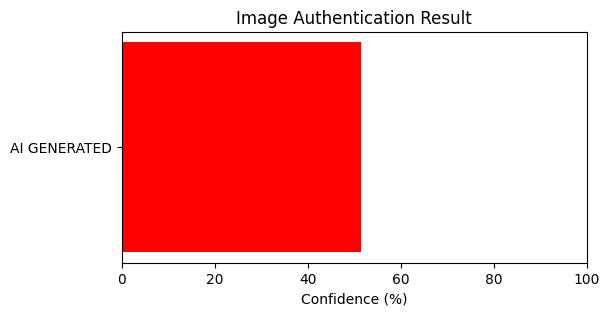

In [ ]:
test_img = os.path.join(data_path + "/ai_generated",
                        os.listdir(data_path + "/ai_generated")[0])

predict_and_visualize(test_img)

In [ ]:
model
data_path

'/content/drive/MyDrive/image-authentication-project/data'

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

folders = {
    "REAL": data_path + "/actual",
    "EDITED": data_path + "/edited",
    "AI GENERATED": data_path + "/ai_generated"
}

labels = ["REAL", "EDITED", "AI GENERATED"]

def predict_image(img):

    img = cv2.resize(img, (128,128))
    img = np.expand_dims(img/255.0, axis=0)

    pred = model.predict(img, verbose=0)[0]
    class_id = np.argmax(pred)
    confidence = float(np.max(pred)) * 100

    return labels[class_id], confidence

In [ ]:
def show_bar(label, confidence):

    color_map = {
        "REAL": "green",
        "EDITED": "orange",
        "AI GENERATED": "red"
    }

    plt.figure(figsize=(5,2))
    plt.barh([label], [confidence], color=color_map[label])
    plt.xlim(0, 100)
    plt.xlabel("Confidence (%)")
    plt.title("Prediction Result")
    plt.show()


CATEGORY: REAL

File: A024-034.png
Predicted: REAL
Confidence: 57.09 %


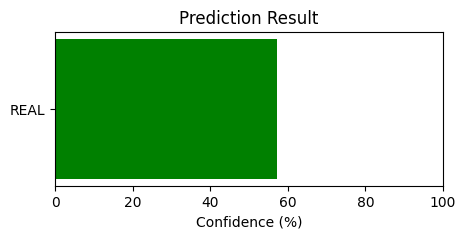

File: A025-051.png
Predicted: REAL
Confidence: 57.8 %


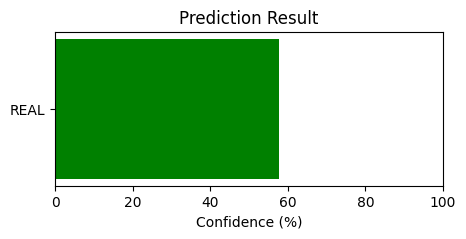

File: A003-032.png
Predicted: REAL
Confidence: 44.73 %


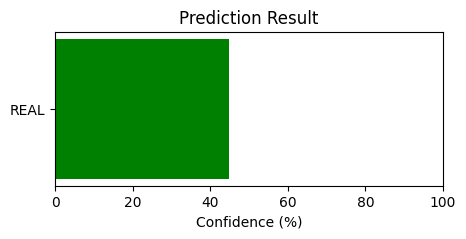

File: A037-005.png
Predicted: REAL
Confidence: 65.1 %


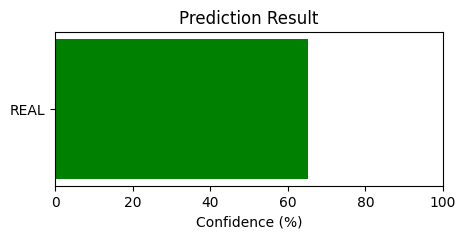

File: A001-010.png
Predicted: REAL
Confidence: 68.21 %


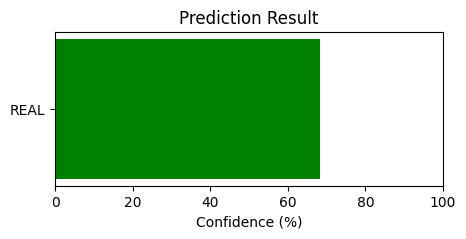

File: A040-126.png
Predicted: REAL
Confidence: 62.59 %


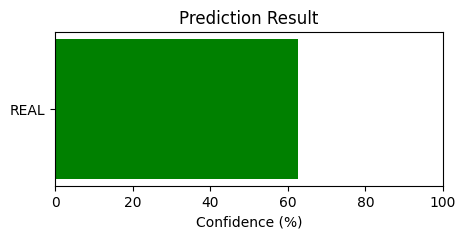

File: A048-135.png
Predicted: REAL
Confidence: 79.51 %


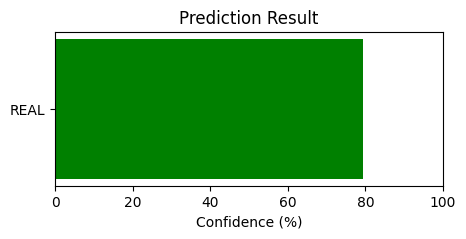

File: A023-033.png
Predicted: REAL
Confidence: 60.4 %


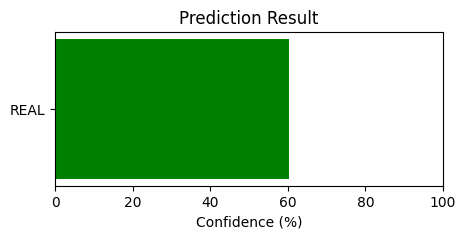

File: A026-008.png
Predicted: REAL
Confidence: 66.05 %


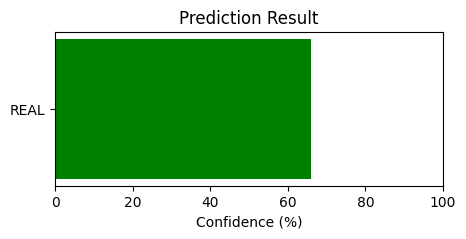

File: B011-102.png
Predicted: REAL
Confidence: 68.21 %


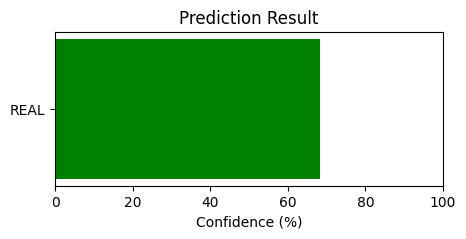

File: A049-021.png
Predicted: EDITED
Confidence: 40.44 %


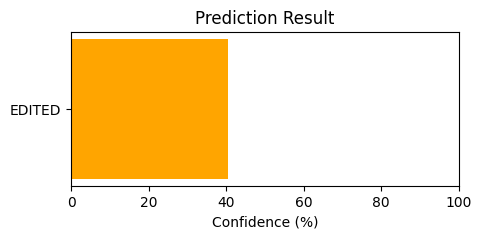

File: A050-200.png
Predicted: REAL
Confidence: 87.48 %


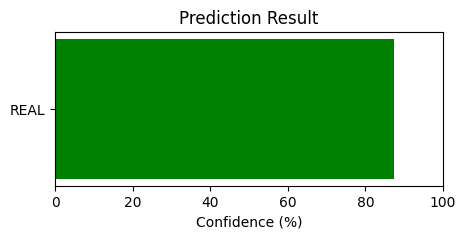

File: A018-056.png
Predicted: REAL
Confidence: 59.32 %


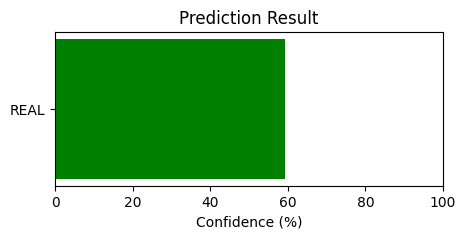

File: A027-106.png
Predicted: REAL
Confidence: 70.32 %


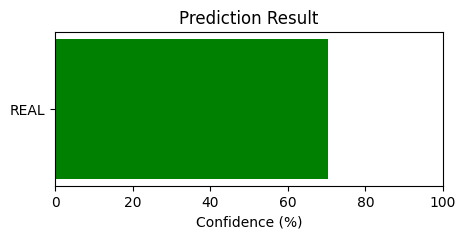

File: B001-047.png
Predicted: REAL
Confidence: 63.05 %


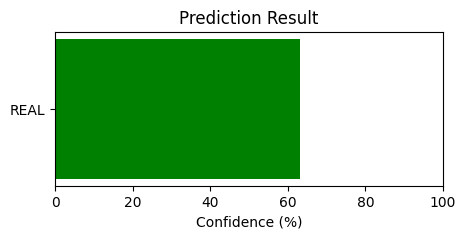

File: A045-215.png
Predicted: REAL
Confidence: 60.71 %


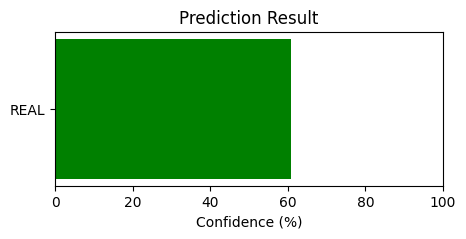

File: A008-229.png
Predicted: REAL
Confidence: 51.34 %


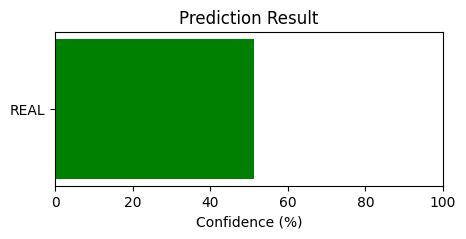

File: B004-045.png
Predicted: EDITED
Confidence: 69.69 %


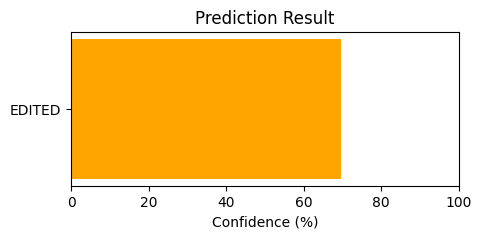

File: A013-004.png
Predicted: REAL
Confidence: 71.67 %


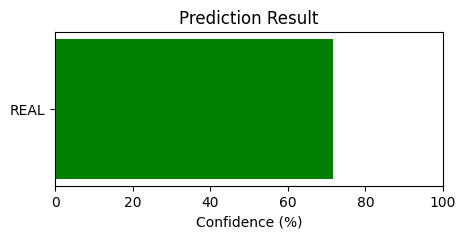

File: B017-110.png
Predicted: REAL
Confidence: 65.12 %


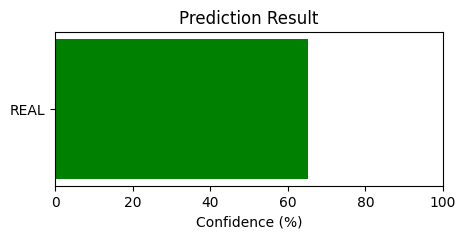

File: A033-052.png
Predicted: REAL
Confidence: 64.61 %


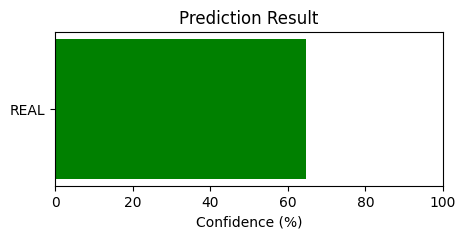

File: A005-023.png
Predicted: REAL
Confidence: 54.65 %


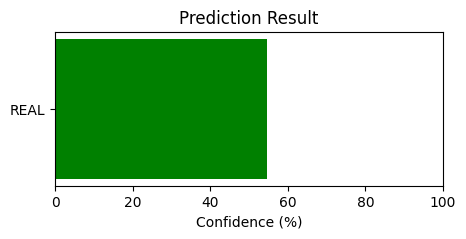

File: B021-354.png
Predicted: REAL
Confidence: 57.48 %


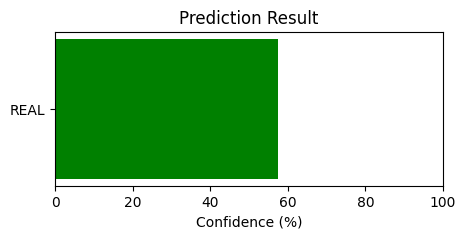

File: A042-459.png
Predicted: REAL
Confidence: 82.5 %


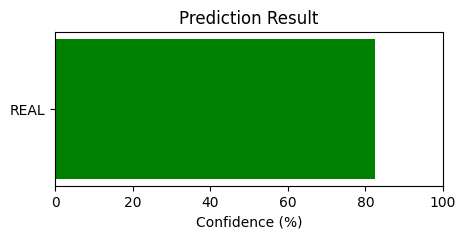

File: A017-047.png
Predicted: REAL
Confidence: 64.59 %


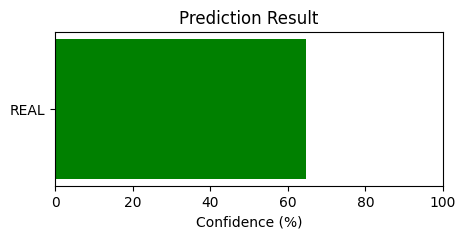

File: B022-045.png
Predicted: REAL
Confidence: 76.38 %


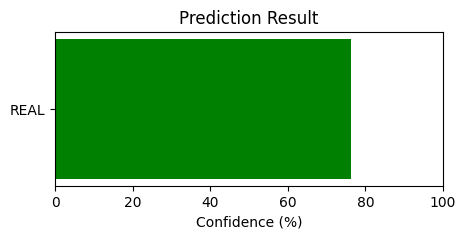

File: B015-017.png
Predicted: REAL
Confidence: 57.4 %


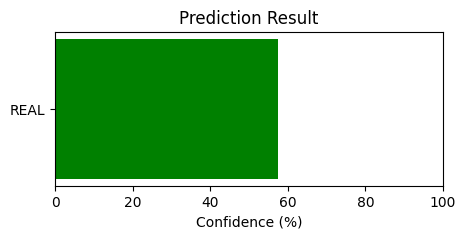

File: B005-051.png
Predicted: REAL
Confidence: 57.68 %


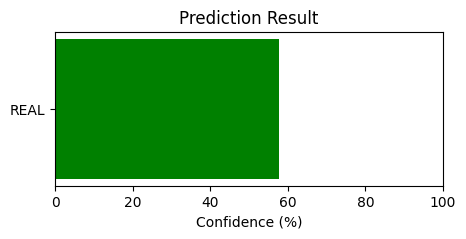

File: B007-056.png
Predicted: REAL
Confidence: 53.14 %


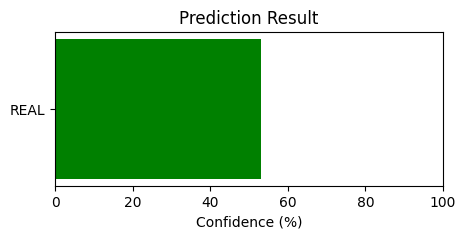

File: A035-116.png
Predicted: REAL
Confidence: 74.69 %


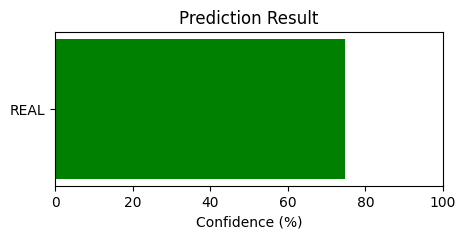

File: A031-024.png
Predicted: REAL
Confidence: 70.26 %


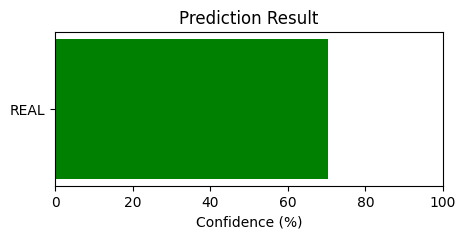

File: C038-004.png
Predicted: AI GENERATED
Confidence: 66.57 %


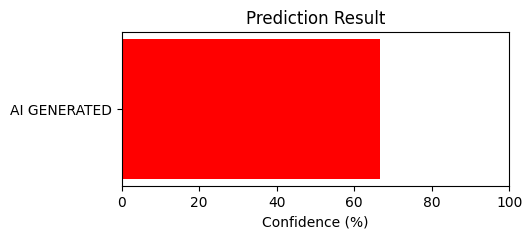

File: B023-048.png
Predicted: REAL
Confidence: 62.85 %


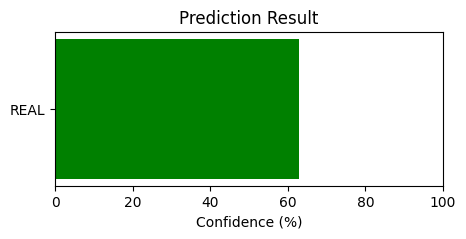

File: B031-053.png
Predicted: REAL
Confidence: 95.54 %


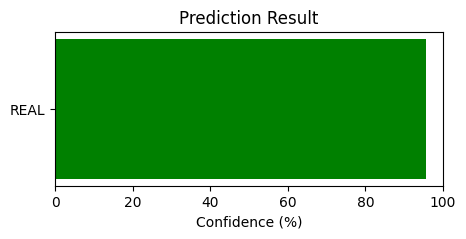

File: B043-118.png
Predicted: EDITED
Confidence: 89.64 %


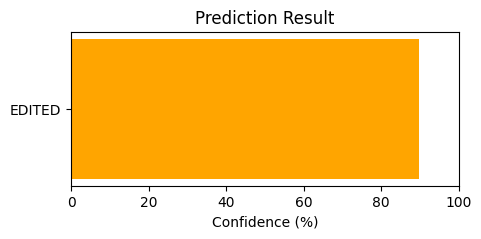

File: C008-011.png
Predicted: REAL
Confidence: 56.5 %


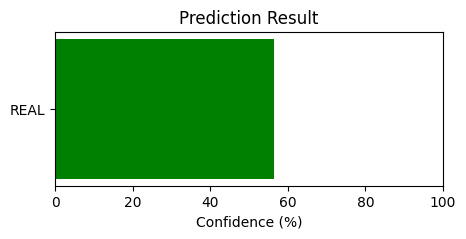

File: C013-302.png
Predicted: REAL
Confidence: 59.48 %


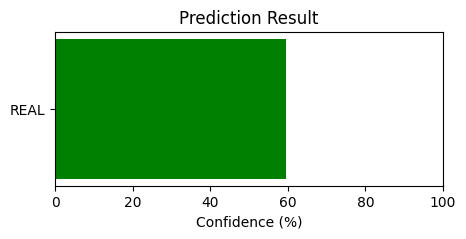

File: C051-022.png
Predicted: REAL
Confidence: 81.81 %


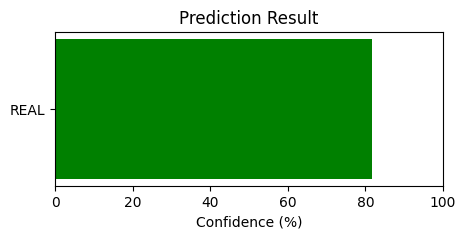

File: C016-039.png
Predicted: REAL
Confidence: 66.94 %


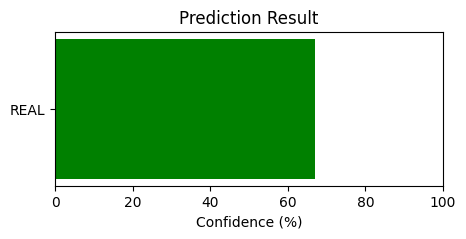

File: C007-209.png
Predicted: REAL
Confidence: 62.36 %


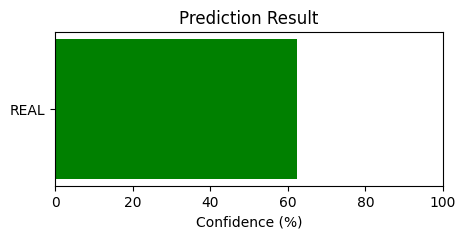

File: C023-016.png
Predicted: REAL
Confidence: 61.3 %


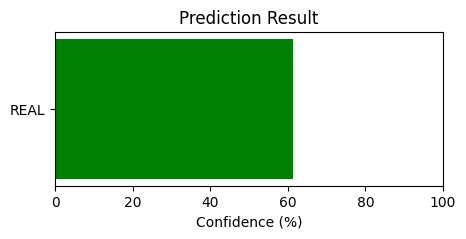

File: C031-041.png
Predicted: REAL
Confidence: 71.98 %


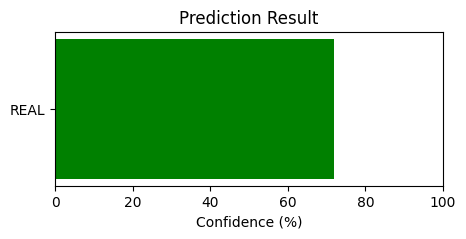

File: C003-005.png
Predicted: REAL
Confidence: 70.47 %


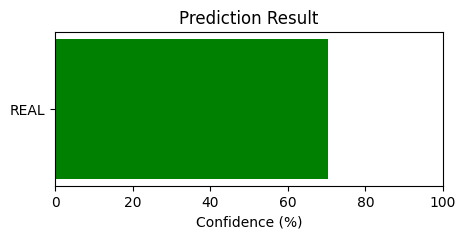

File: C030-033.png
Predicted: REAL
Confidence: 66.35 %


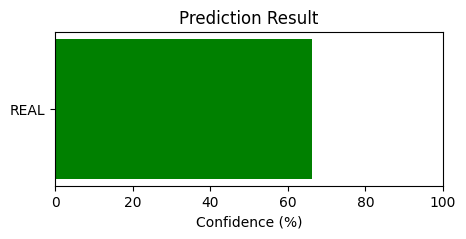

File: C014-038.png
Predicted: EDITED
Confidence: 75.58 %


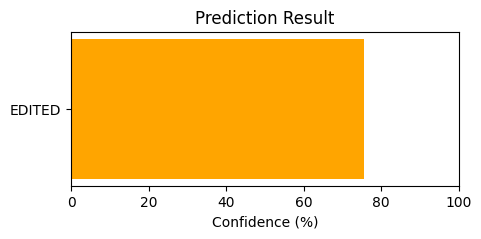

File: B029-357.png
Predicted: REAL
Confidence: 74.38 %


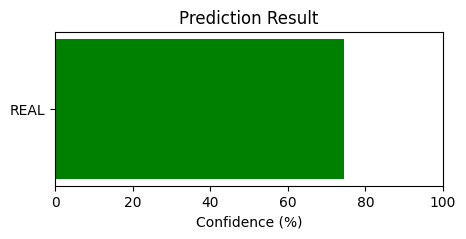

File: C001-103.png
Predicted: REAL
Confidence: 65.69 %


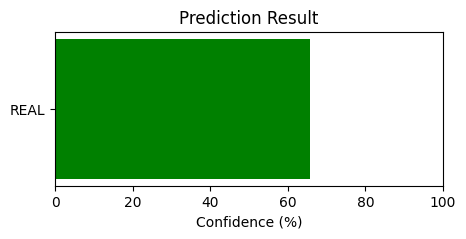

File: C042-301.png
Predicted: REAL
Confidence: 74.72 %


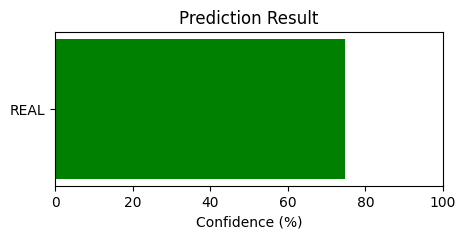

File: C005-005.png
Predicted: REAL
Confidence: 59.13 %


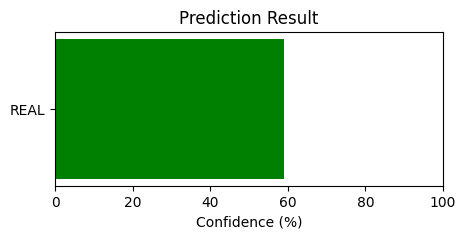

File: B035-247.png
Predicted: REAL
Confidence: 72.34 %


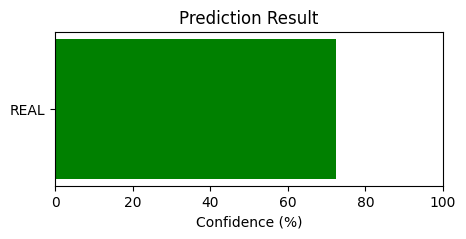

File: B039-500.png
Predicted: REAL
Confidence: 56.27 %


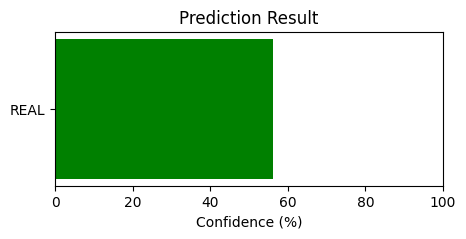

File: C049-005.png
Predicted: REAL
Confidence: 63.57 %


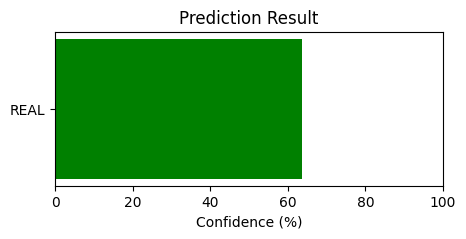

File: C020-055.png
Predicted: REAL
Confidence: 59.58 %


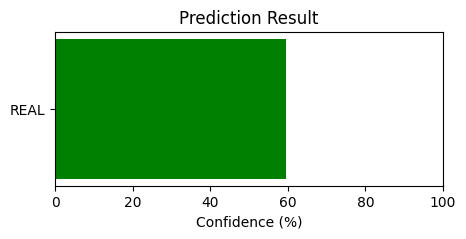

File: C006-121.png
Predicted: REAL
Confidence: 56.58 %


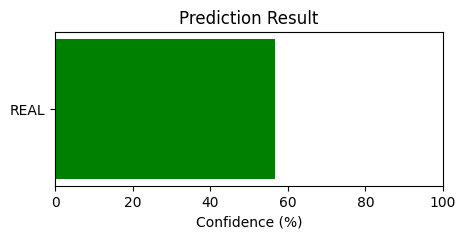

File: B046-304.png
Predicted: REAL
Confidence: 60.51 %


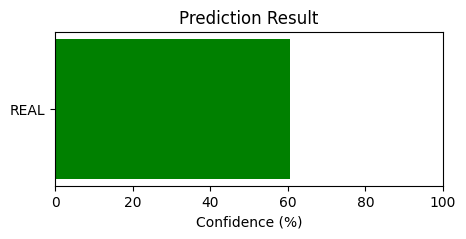

File: C029-029.png
Predicted: REAL
Confidence: 59.84 %


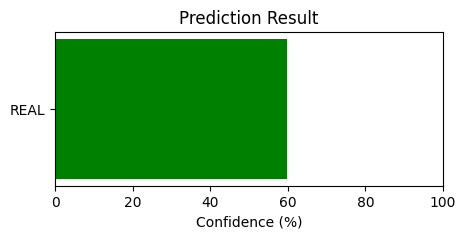

File: C022-159.png
Predicted: REAL
Confidence: 66.83 %


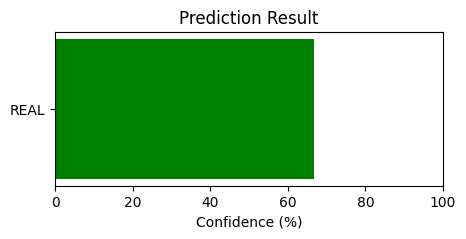

File: C052-041.png
Predicted: REAL
Confidence: 72.07 %


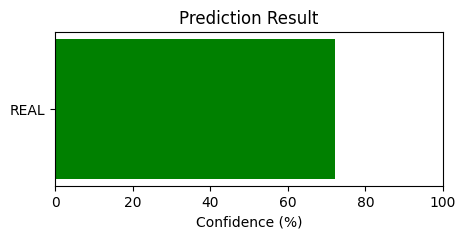

File: B032-047.png
Predicted: REAL
Confidence: 63.78 %


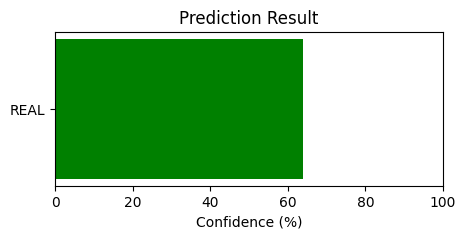

File: C021-038.png
Predicted: REAL
Confidence: 63.22 %


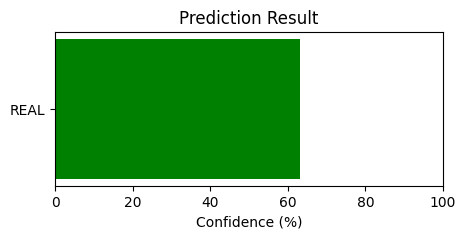

File: B048-131.png
Predicted: REAL
Confidence: 77.02 %


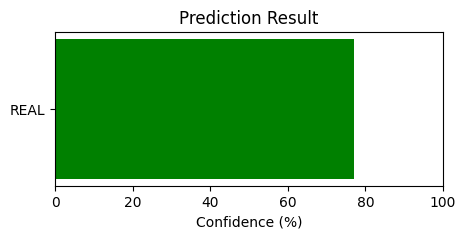

File: C010-120.png
Predicted: REAL
Confidence: 62.84 %


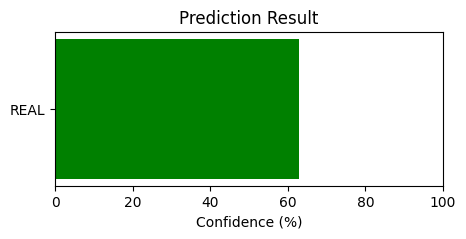

File: B049-327.png
Predicted: REAL
Confidence: 57.93 %


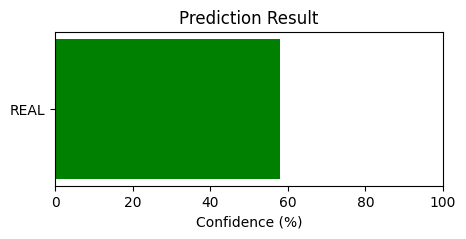

File: C009-009.png
Predicted: REAL
Confidence: 62.07 %


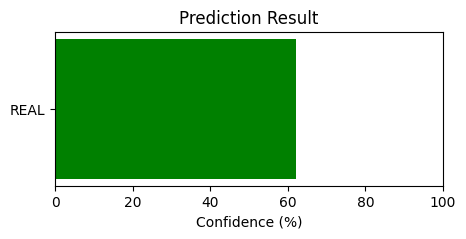

File: C044-034.png
Predicted: REAL
Confidence: 68.48 %


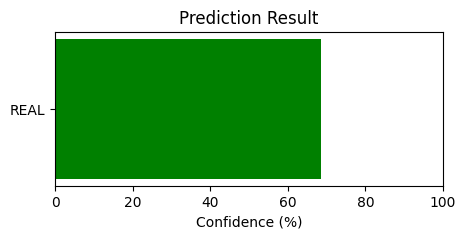

File: C018-017.png
Predicted: REAL
Confidence: 58.91 %


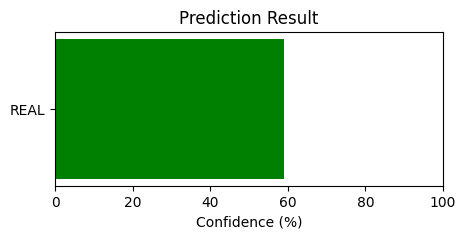

File: B025-024.png
Predicted: REAL
Confidence: 69.94 %


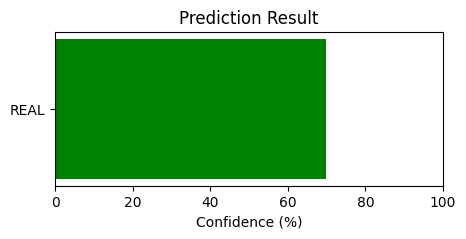

File: C015-355.png
Predicted: REAL
Confidence: 64.61 %


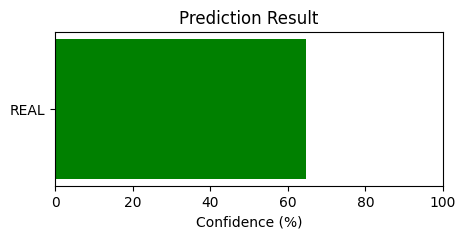

File: B037-012.png
Predicted: REAL
Confidence: 61.64 %


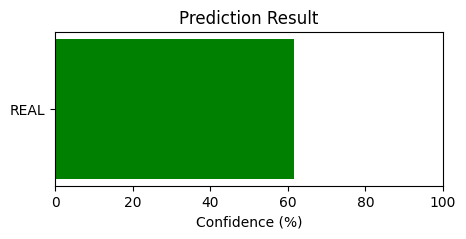

File: B040-037.png
Predicted: REAL
Confidence: 51.73 %


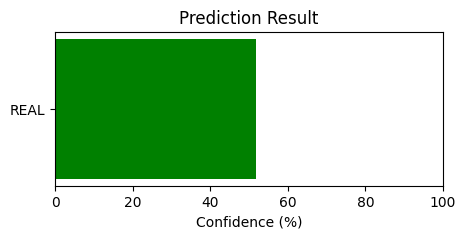

File: B028-034.png
Predicted: REAL
Confidence: 60.77 %


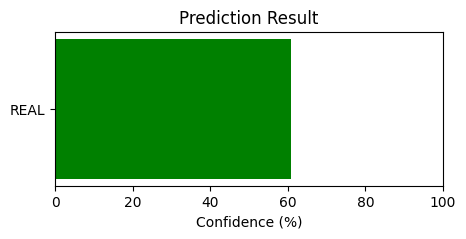

File: C025-040.png
Predicted: REAL
Confidence: 53.69 %


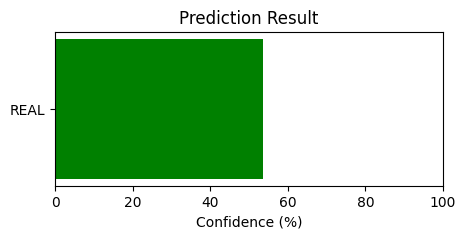

File: B026-215.png
Predicted: REAL
Confidence: 55.94 %


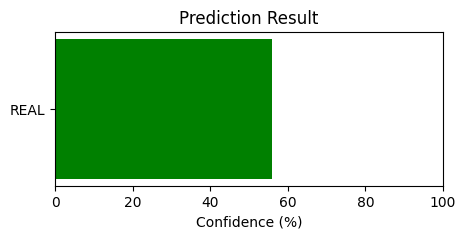

File: C027-105.png
Predicted: REAL
Confidence: 47.95 %


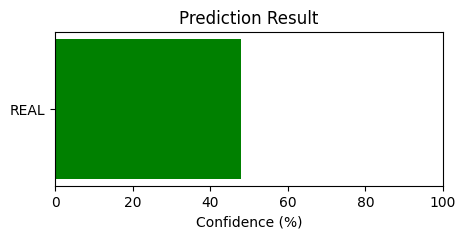

File: C032-006.png
Predicted: REAL
Confidence: 53.21 %


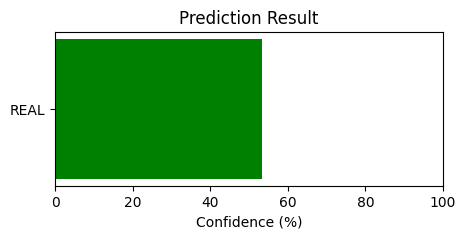

File: C002-134.png
Predicted: REAL
Confidence: 70.01 %


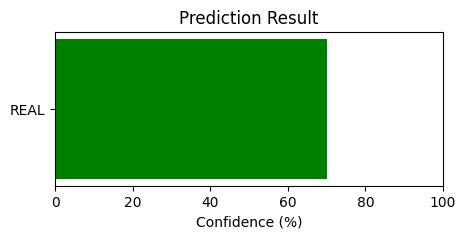

File: C028-106.png
Predicted: REAL
Confidence: 52.77 %


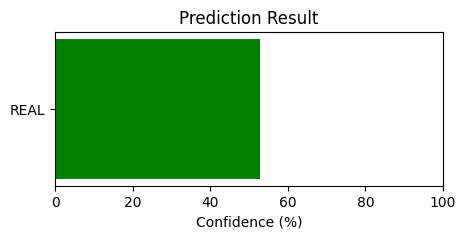

File: B044-136.png
Predicted: REAL
Confidence: 87.18 %


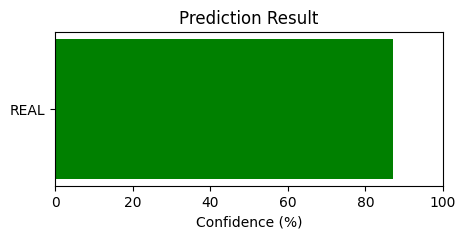

File: D019-008.png
Predicted: REAL
Confidence: 80.29 %


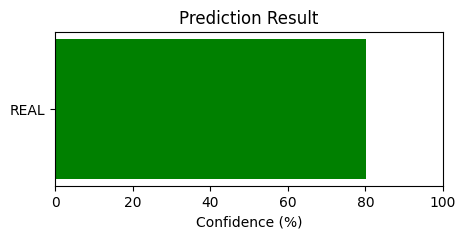

File: D046-053.png
Predicted: REAL
Confidence: 80.78 %


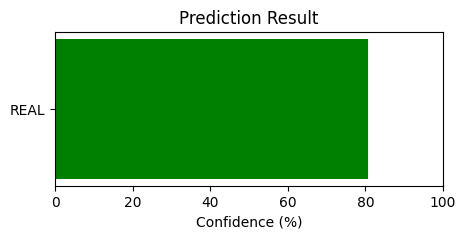

File: E013-015.png
Predicted: REAL
Confidence: 78.53 %


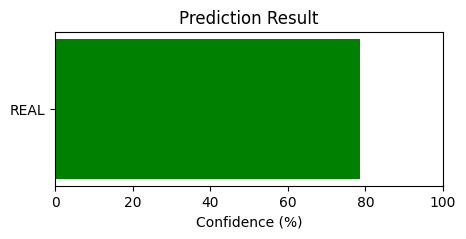

File: E030-036.png
Predicted: REAL
Confidence: 65.87 %


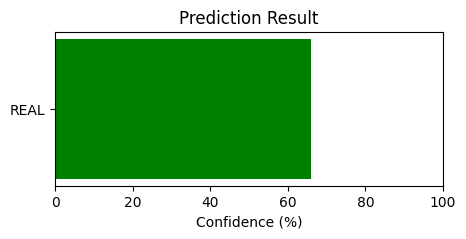

File: D022-114.png
Predicted: REAL
Confidence: 55.14 %


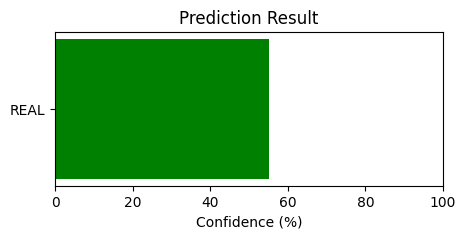

File: E019-027.png
Predicted: REAL
Confidence: 79.83 %


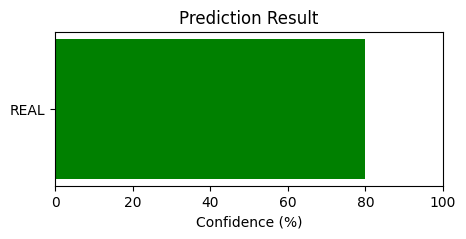

File: D001-049.png
Predicted: REAL
Confidence: 46.56 %


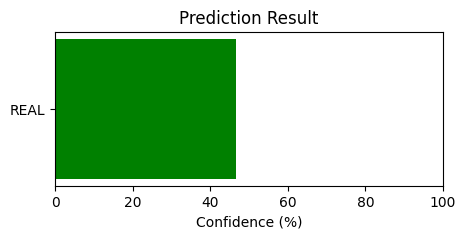

File: D006-331.png
Predicted: EDITED
Confidence: 50.81 %


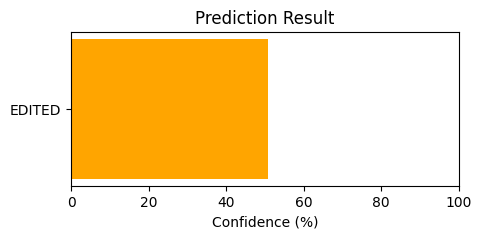

File: D010-142.png
Predicted: REAL
Confidence: 75.2 %


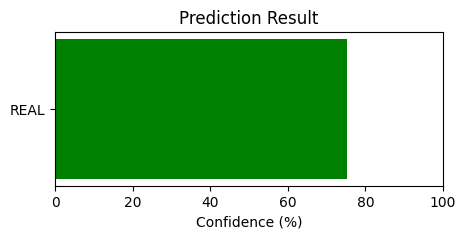

File: E031-002.png
Predicted: REAL
Confidence: 78.06 %


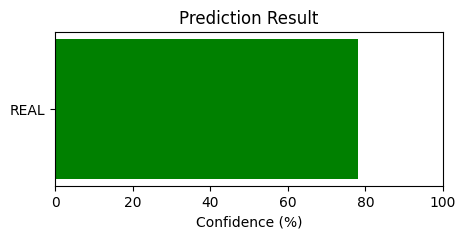

File: D007-030.png
Predicted: REAL
Confidence: 83.71 %


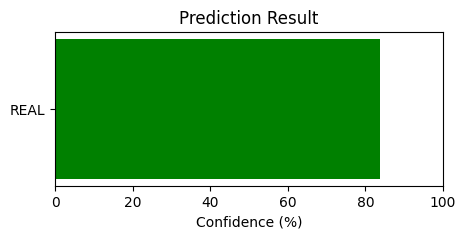

File: D027-036.png
Predicted: REAL
Confidence: 75.14 %


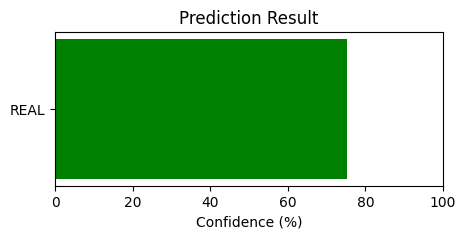

File: D013-029.png
Predicted: REAL
Confidence: 79.43 %


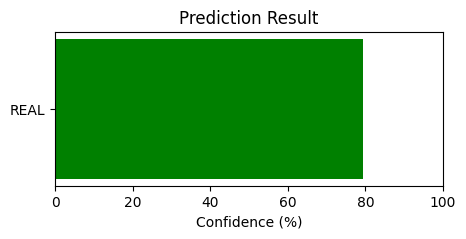

File: D002-128.png
Predicted: REAL
Confidence: 93.06 %


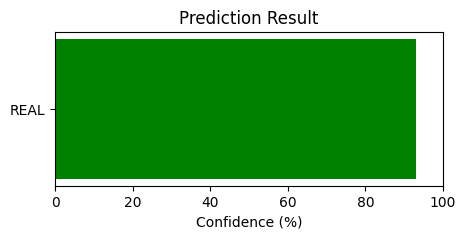

File: D031-112.png
Predicted: REAL
Confidence: 71.15 %


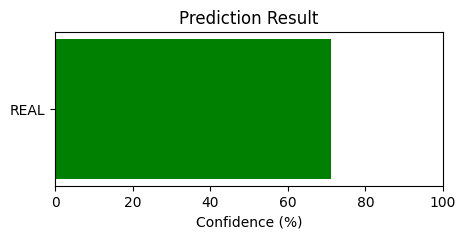

File: D026-037.png
Predicted: REAL
Confidence: 80.02 %


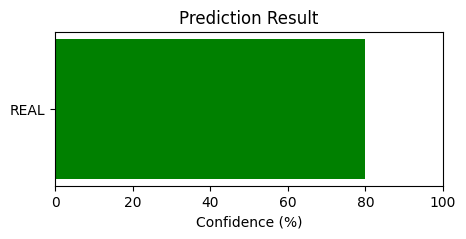

File: D045-215.png
Predicted: REAL
Confidence: 84.4 %


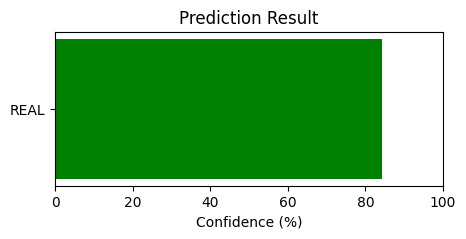

File: D017-047.png
Predicted: REAL
Confidence: 70.87 %


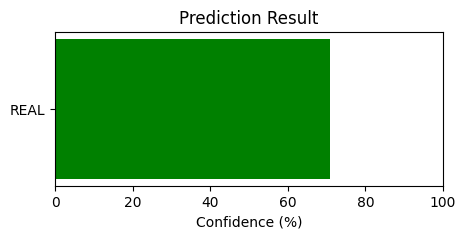

File: E021-002.png
Predicted: REAL
Confidence: 78.9 %


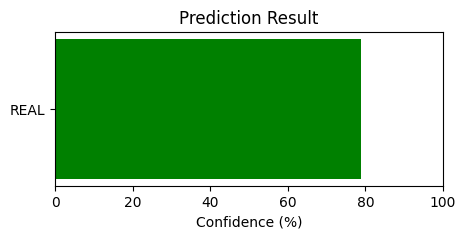

File: E002-010.png
Predicted: REAL
Confidence: 62.34 %


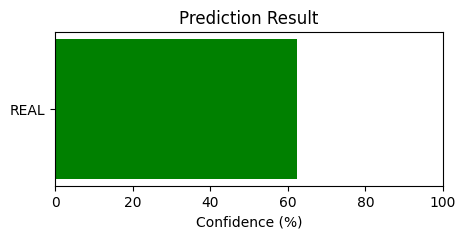

File: D004-015.png
Predicted: REAL
Confidence: 94.32 %


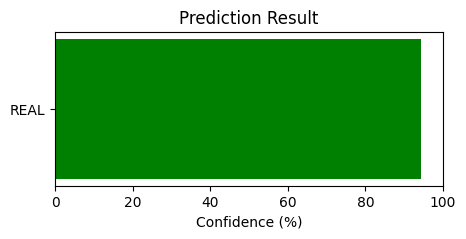

File: D016-121.png
Predicted: EDITED
Confidence: 48.55 %


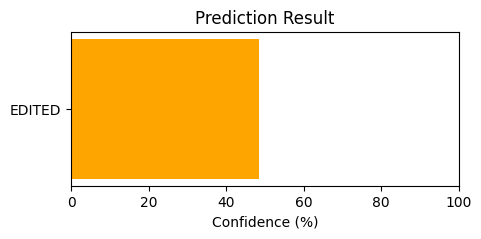

File: D021-040.png
Predicted: REAL
Confidence: 54.38 %


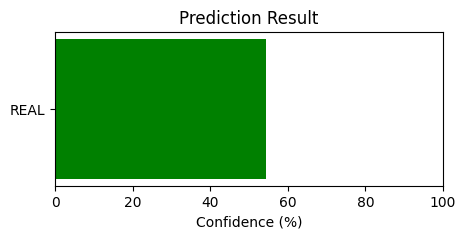

File: D012-025.png
Predicted: REAL
Confidence: 81.33 %


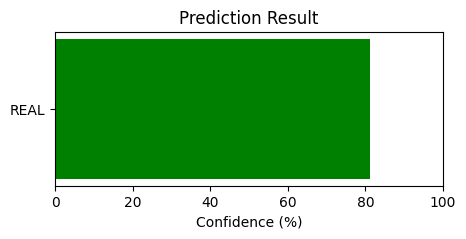

File: E032-020.png
Predicted: REAL
Confidence: 71.09 %


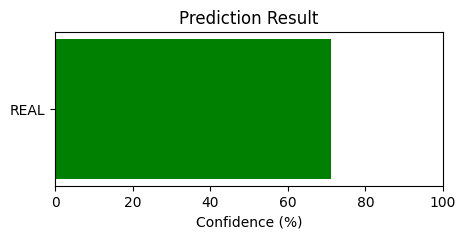

File: D048-025.png
Predicted: REAL
Confidence: 61.72 %


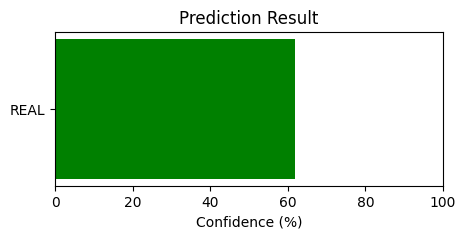

File: E029-004.png
Predicted: REAL
Confidence: 69.77 %


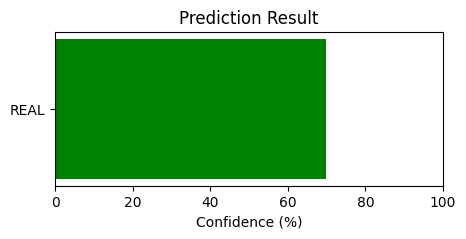

File: D020-114.png
Predicted: REAL
Confidence: 66.9 %


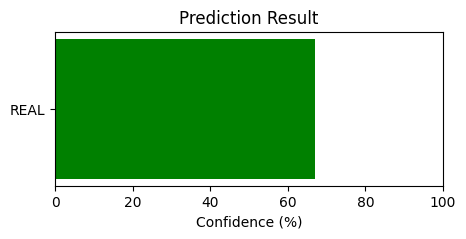

File: E027-003.png
Predicted: EDITED
Confidence: 47.09 %


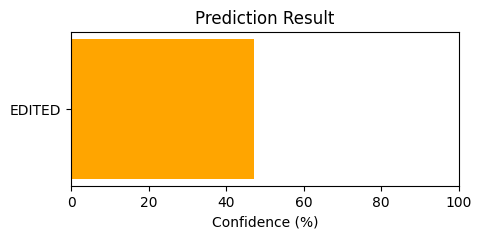

File: E004-005.png
Predicted: REAL
Confidence: 61.64 %


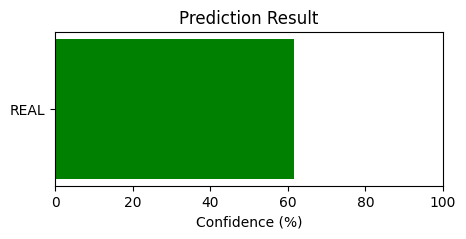

File: E028-016.png
Predicted: REAL
Confidence: 81.7 %


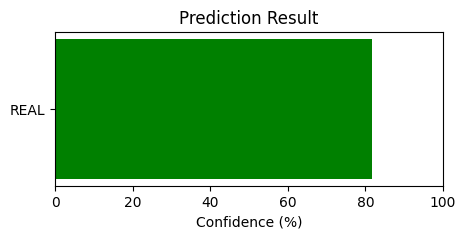

File: E020-022.png
Predicted: REAL
Confidence: 44.52 %


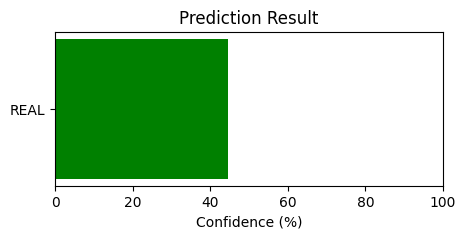

File: D009-033.png
Predicted: EDITED
Confidence: 52.56 %


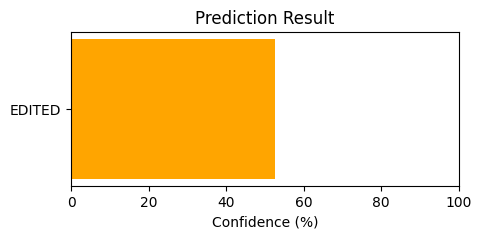

File: E012-009.png
Predicted: REAL
Confidence: 63.15 %


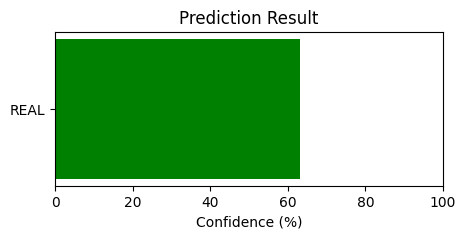

File: E010-008.png
Predicted: REAL
Confidence: 53.91 %


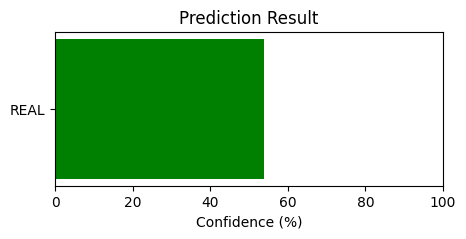

File: E011-009.png
Predicted: REAL
Confidence: 75.3 %


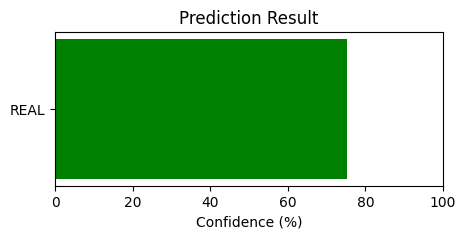

File: F026-002.png
Predicted: REAL
Confidence: 69.93 %


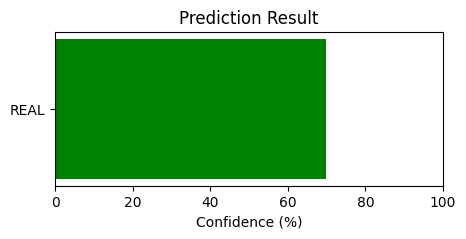

File: E146-014.png
Predicted: REAL
Confidence: 74.3 %


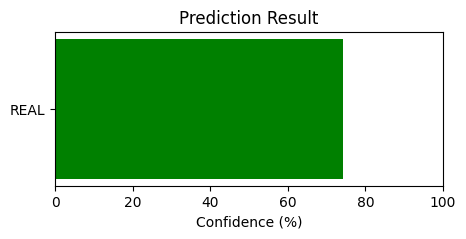

File: G008-253.png
Predicted: REAL
Confidence: 89.85 %


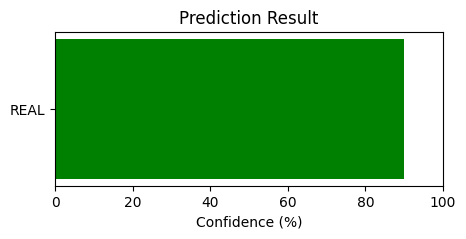

File: E145-014.png
Predicted: REAL
Confidence: 66.37 %


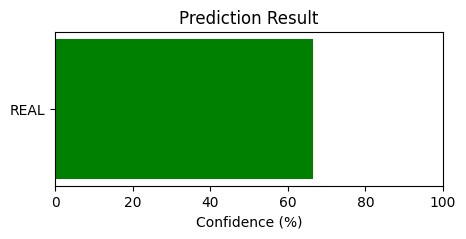

File: E035-002.png
Predicted: REAL
Confidence: 62.52 %


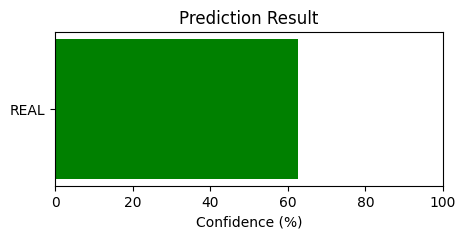

File: E039-002.png
Predicted: REAL
Confidence: 63.89 %


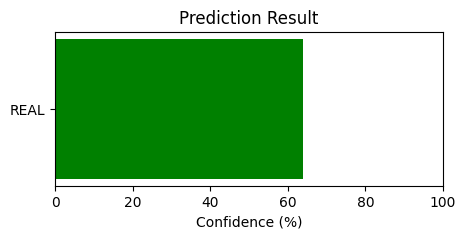

File: E075-004.png
Predicted: REAL
Confidence: 75.98 %


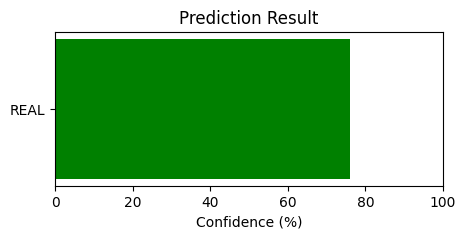

File: F014-310.png
Predicted: REAL
Confidence: 69.33 %


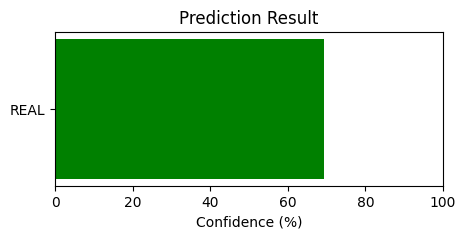

File: F048-048.png
Predicted: REAL
Confidence: 88.77 %


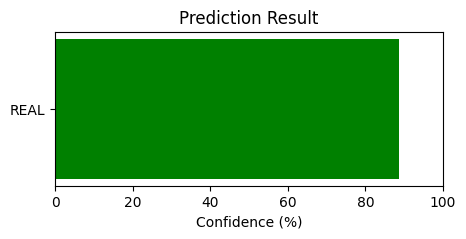

File: G020-119.png
Predicted: REAL
Confidence: 89.73 %


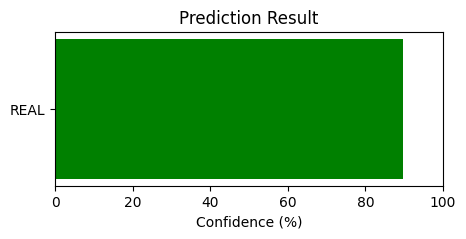

File: F030-024.png
Predicted: REAL
Confidence: 85.7 %


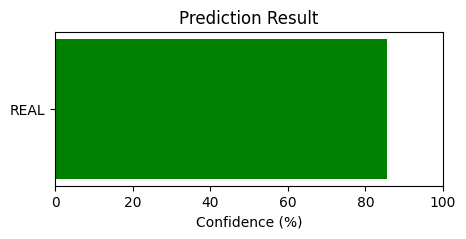

File: G010-028.png
Predicted: REAL
Confidence: 98.69 %


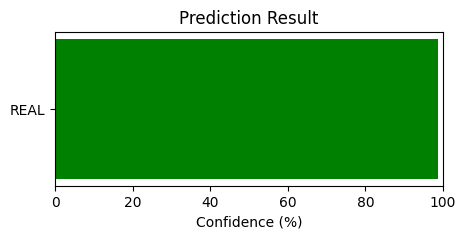

File: G005-028.png
Predicted: REAL
Confidence: 87.44 %


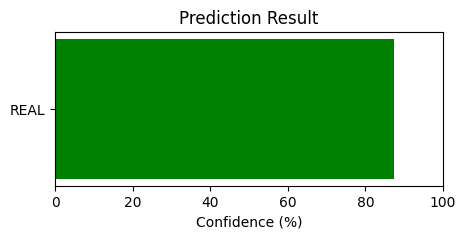

File: F019-037.png
Predicted: EDITED
Confidence: 58.45 %


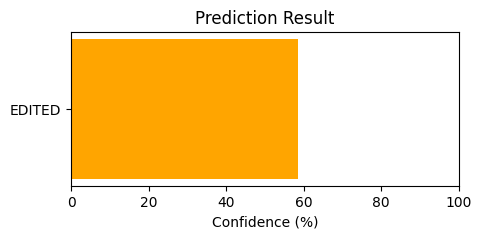

File: F022-137.png
Predicted: REAL
Confidence: 67.31 %


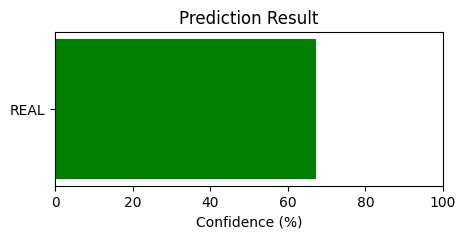

File: F054-005.png
Predicted: EDITED
Confidence: 69.65 %


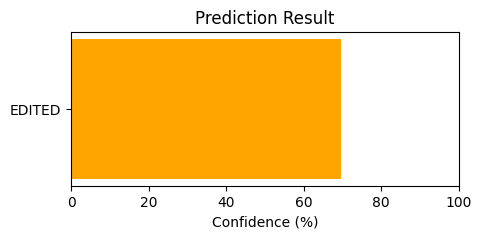

File: F033-430.png
Predicted: REAL
Confidence: 70.93 %


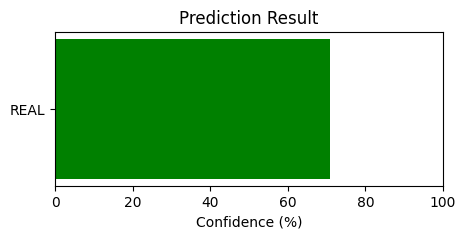

File: G019-009.png
Predicted: REAL
Confidence: 87.28 %


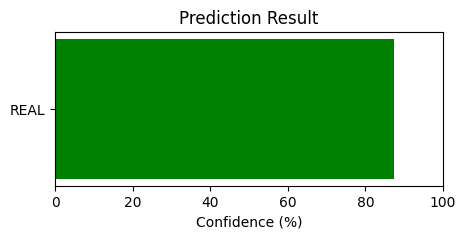

File: G017-013.png
Predicted: REAL
Confidence: 71.59 %


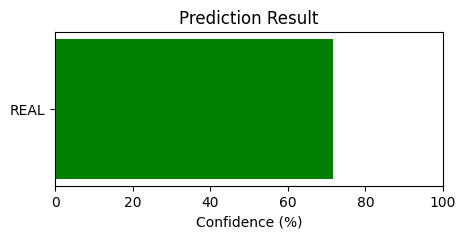

File: F004-022.png
Predicted: REAL
Confidence: 62.39 %


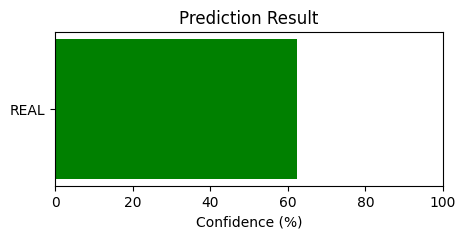

File: F028-009.png
Predicted: REAL
Confidence: 86.28 %


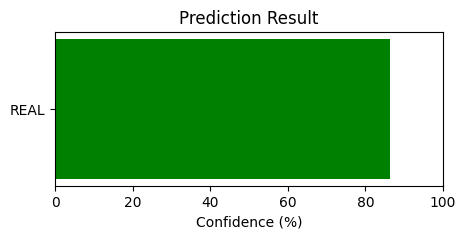

File: E034-008.png
Predicted: EDITED
Confidence: 82.88 %


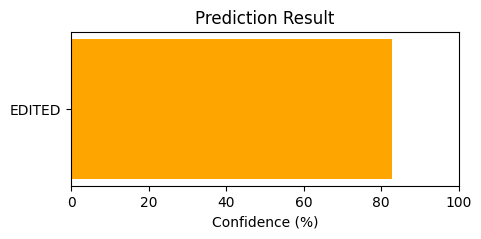

File: F017-021.png
Predicted: REAL
Confidence: 65.49 %


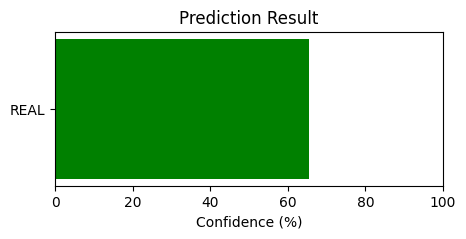

File: F050-056.png
Predicted: REAL
Confidence: 82.88 %


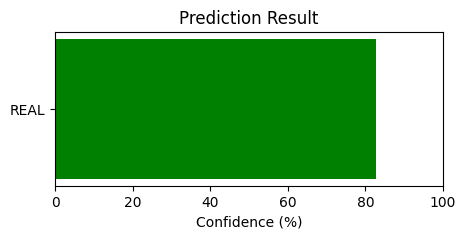

File: F018-029.png
Predicted: REAL
Confidence: 97.07 %


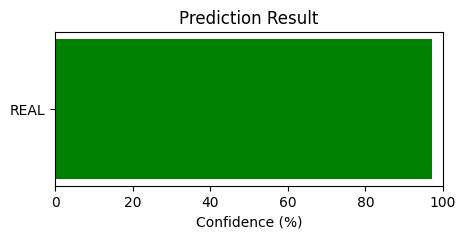

File: F025-045.png
Predicted: REAL
Confidence: 92.7 %


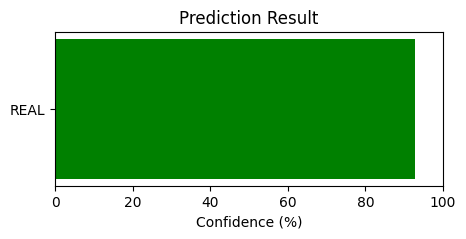

File: G016-023.png
Predicted: REAL
Confidence: 63.34 %


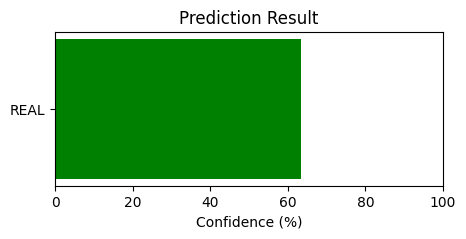

File: F013-030.png
Predicted: REAL
Confidence: 75.12 %


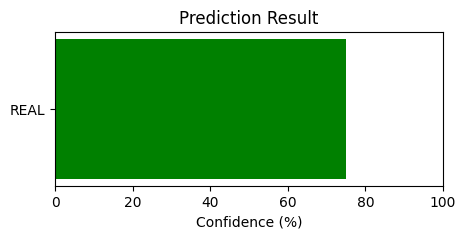

File: G001-101.png
Predicted: REAL
Confidence: 68.04 %


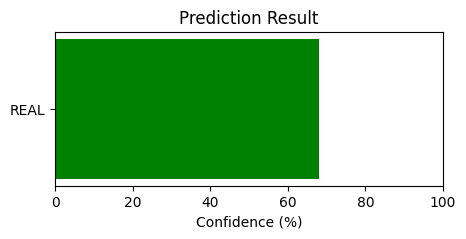

File: F031-045.png
Predicted: EDITED
Confidence: 86.66 %


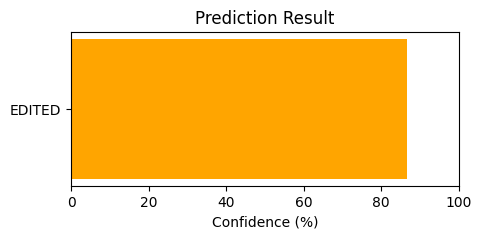

File: G009-227.png
Predicted: REAL
Confidence: 90.05 %


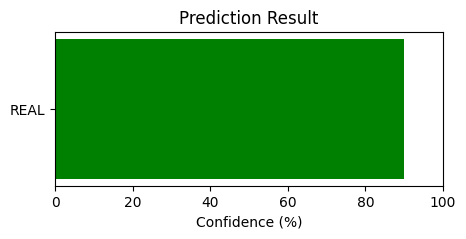

File: F039-023.png
Predicted: REAL
Confidence: 70.35 %


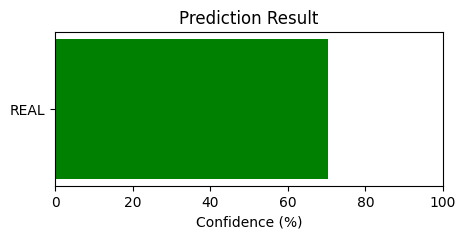

File: F036-121.png
Predicted: REAL
Confidence: 76.26 %


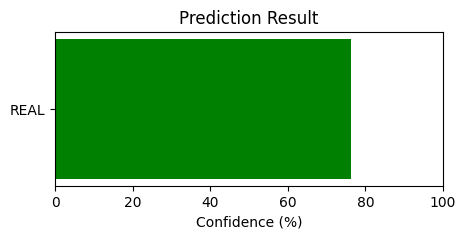

File: G015-110.png
Predicted: REAL
Confidence: 81.85 %


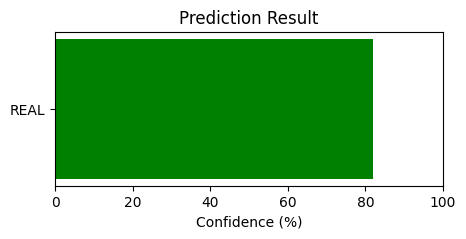

File: E127-113.png
Predicted: REAL
Confidence: 74.45 %


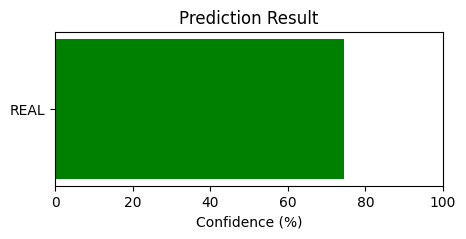

File: F023-012.png
Predicted: REAL
Confidence: 71.01 %


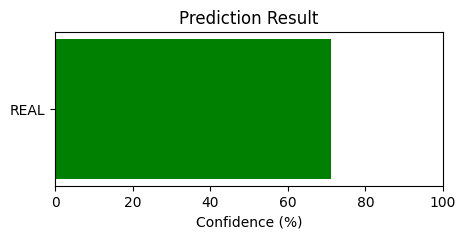

File: F011-109.png
Predicted: REAL
Confidence: 94.72 %


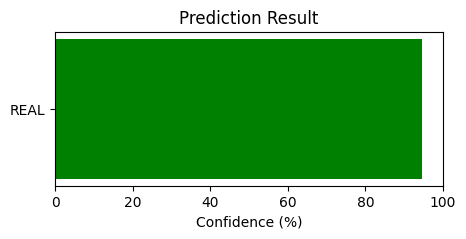

File: F041-019.png
Predicted: REAL
Confidence: 89.66 %


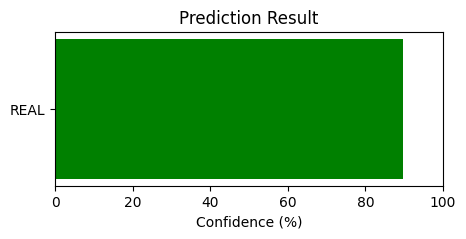

File: F020-208.png
Predicted: REAL
Confidence: 74.36 %


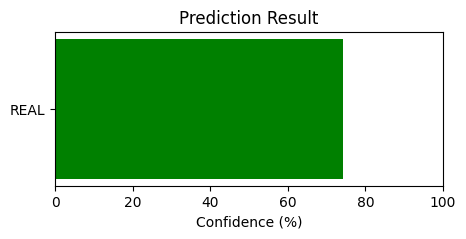

File: H018-037.png
Predicted: REAL
Confidence: 62.73 %


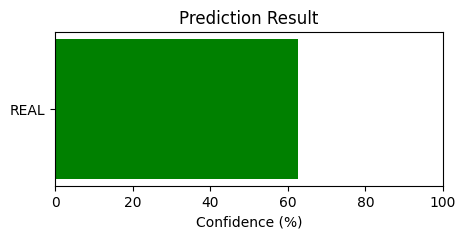

File: H001-042.png
Predicted: EDITED
Confidence: 56.26 %


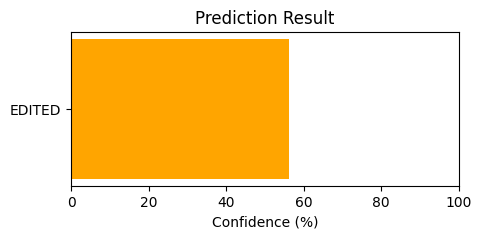

File: H017-011.png
Predicted: REAL
Confidence: 84.51 %


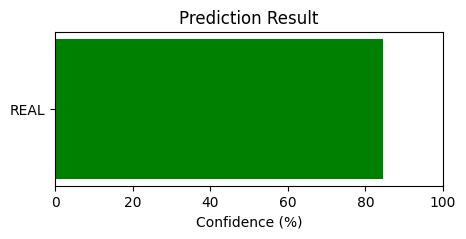

File: H034-044.png
Predicted: REAL
Confidence: 61.38 %


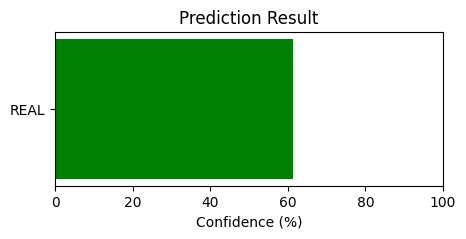

File: H014-005.png
Predicted: REAL
Confidence: 70.57 %


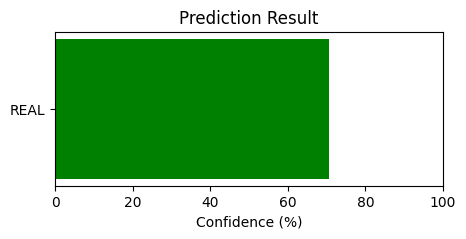

File: H040-008.png
Predicted: REAL
Confidence: 89.33 %


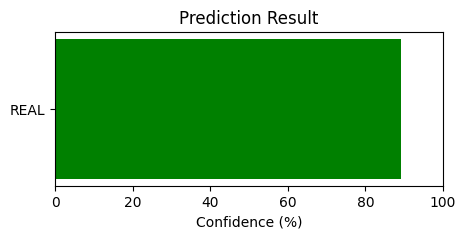

File: H024-023.png
Predicted: REAL
Confidence: 82.9 %


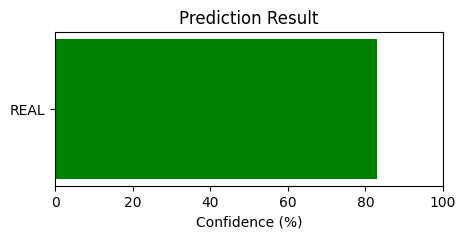

File: H043-140.png
Predicted: REAL
Confidence: 81.12 %


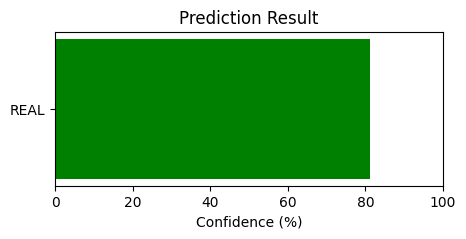

File: H010-113.png
Predicted: REAL
Confidence: 77.14 %


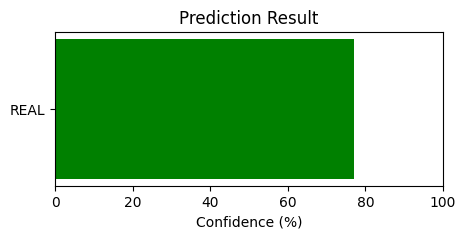

File: H012-020.png
Predicted: REAL
Confidence: 71.87 %


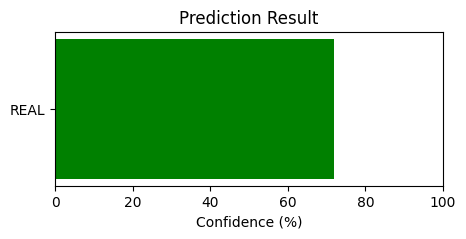

File: H008-146.png
Predicted: REAL
Confidence: 74.23 %


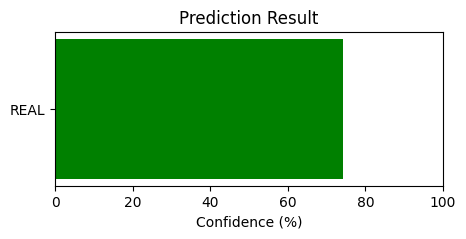

File: H011-037.png
Predicted: REAL
Confidence: 74.98 %


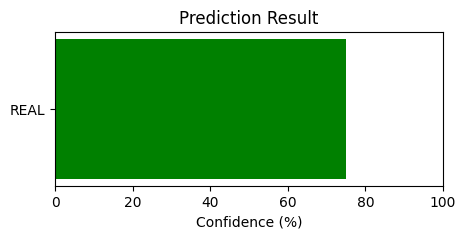

File: H015-113.png
Predicted: REAL
Confidence: 59.26 %


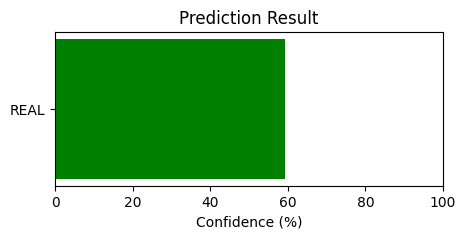

File: H026-018.png
Predicted: REAL
Confidence: 59.2 %


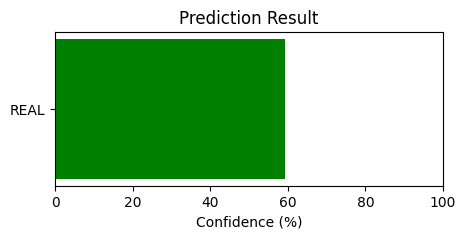

File: G049-036.png
Predicted: REAL
Confidence: 63.52 %


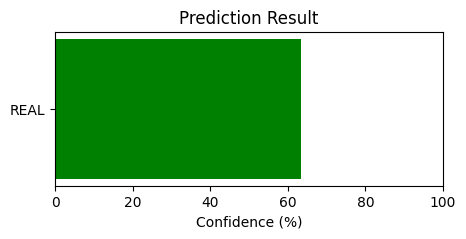

File: H042-138.png
Predicted: REAL
Confidence: 74.64 %


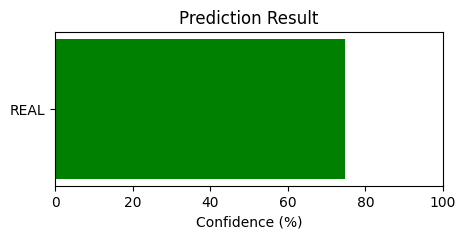

File: H048-206.png
Predicted: REAL
Confidence: 94.57 %


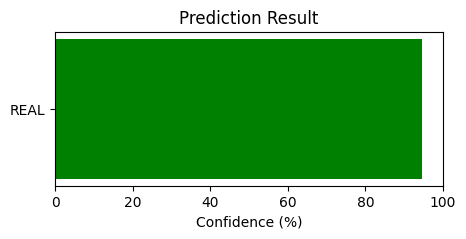

File: H022-144.png
Predicted: REAL
Confidence: 58.18 %


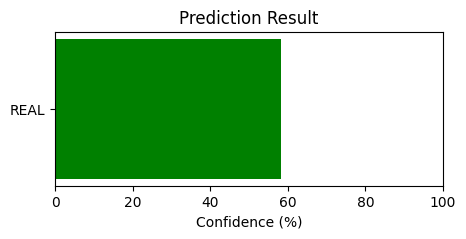

File: H033-019.png
Predicted: REAL
Confidence: 81.79 %


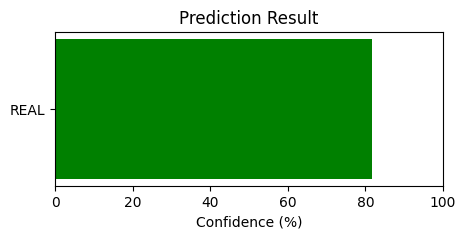

File: G042-129.png
Predicted: REAL
Confidence: 71.65 %


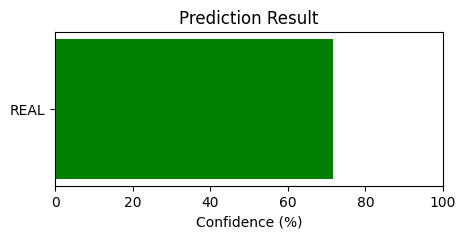

File: G021-111.png
Predicted: REAL
Confidence: 70.02 %


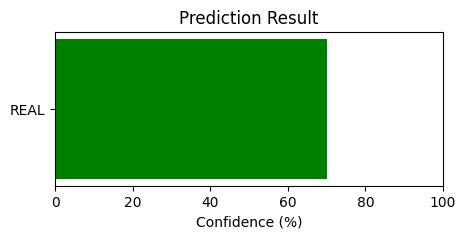

File: G048-008.png
Predicted: REAL
Confidence: 52.62 %


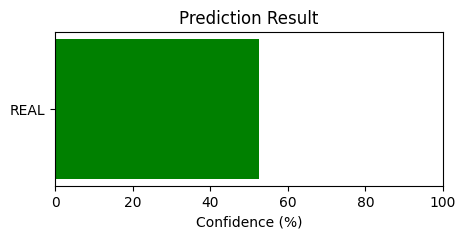

File: H027-015.png
Predicted: REAL
Confidence: 80.9 %


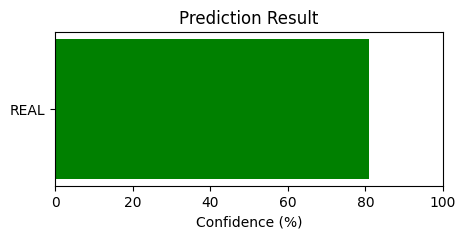

File: H028-123.png
Predicted: REAL
Confidence: 73.4 %


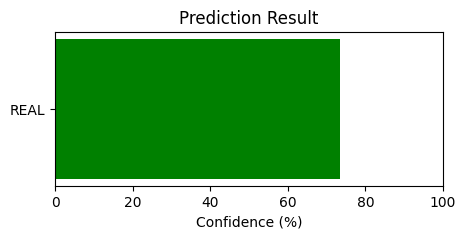

File: H031-028.png
Predicted: EDITED
Confidence: 63.55 %


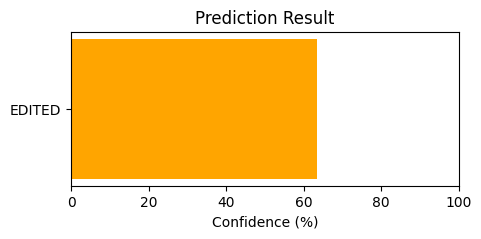

File: H035-013.png
Predicted: REAL
Confidence: 51.14 %


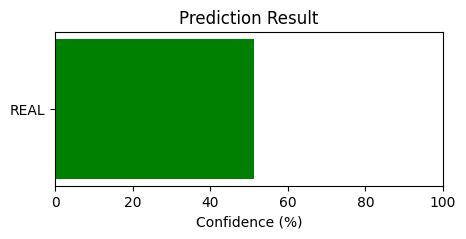

File: G044-612.png
Predicted: REAL
Confidence: 62.74 %


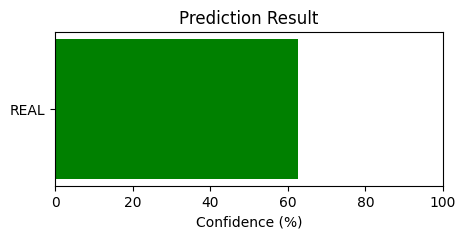

File: G040-445.png
Predicted: REAL
Confidence: 72.15 %


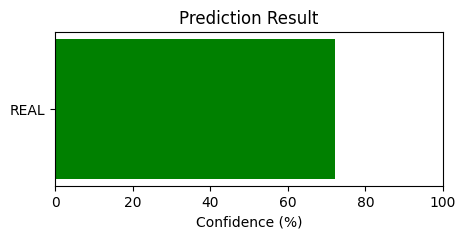

File: G031-007.png
Predicted: EDITED
Confidence: 86.42 %


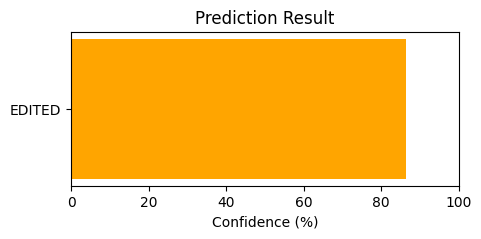

File: G029-038.png
Predicted: EDITED
Confidence: 52.23 %


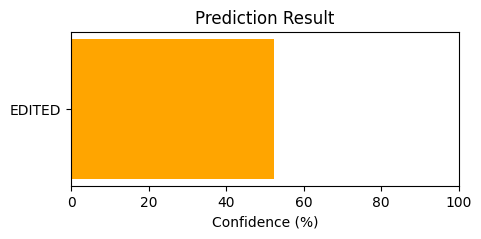

File: G052-133.png
Predicted: REAL
Confidence: 53.78 %


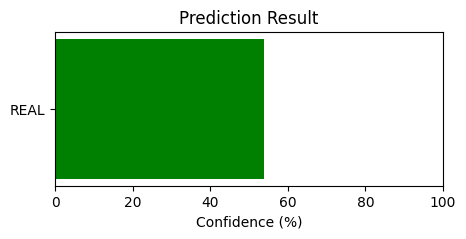

File: H036-022.png
Predicted: REAL
Confidence: 93.78 %


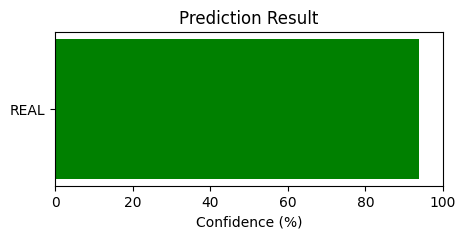

File: H023-301.png
Predicted: REAL
Confidence: 95.73 %


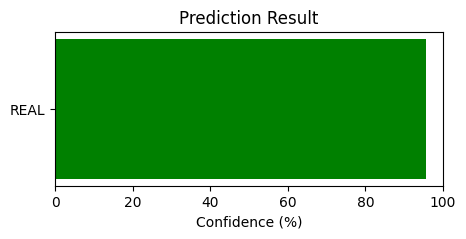

File: H049-208.png
Predicted: REAL
Confidence: 71.3 %


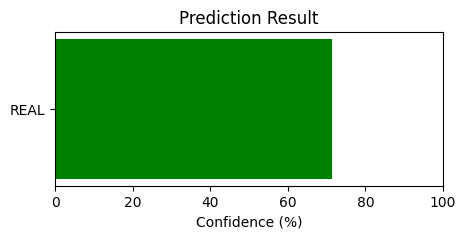

File: H020-018.png
Predicted: REAL
Confidence: 66.14 %


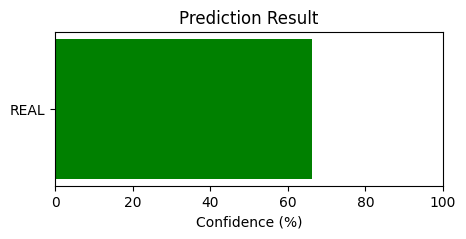

File: H013-115.png
Predicted: REAL
Confidence: 77.61 %


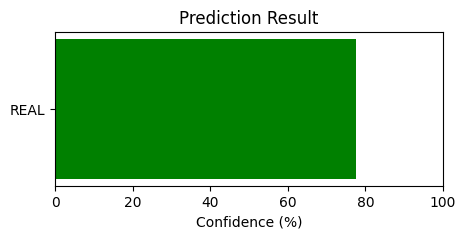


CATEGORY: EDITED

File: enhanced_C009-009.png
Predicted: EDITED
Confidence: 99.37 %


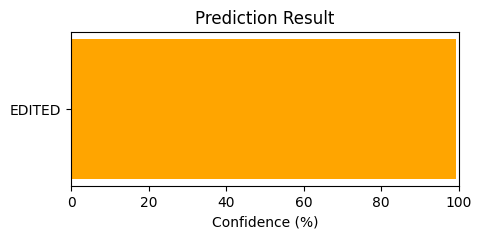

File: enhanced_B039-500.png
Predicted: EDITED
Confidence: 99.2 %


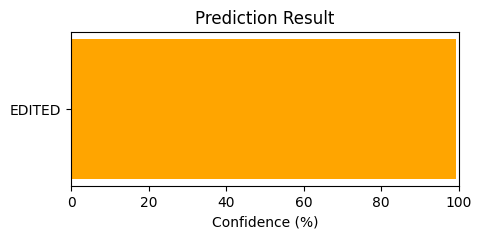

File: enhanced_B032-047.png
Predicted: EDITED
Confidence: 99.98 %


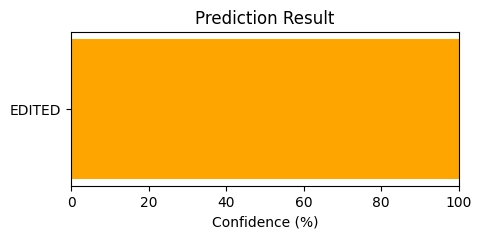

File: enhanced_C007-209.png
Predicted: EDITED
Confidence: 100.0 %


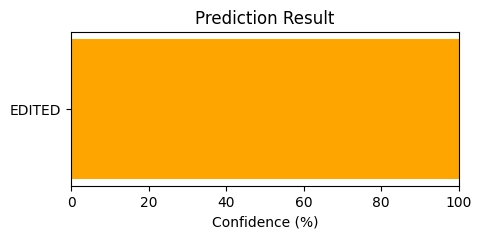

File: enhanced_B029-357.png
Predicted: EDITED
Confidence: 99.81 %


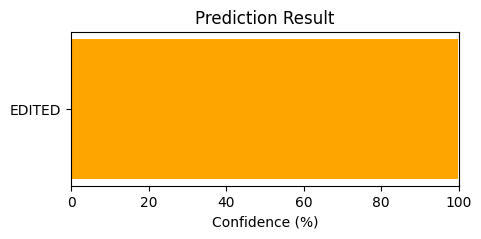

File: enhanced_B031-053.png
Predicted: EDITED
Confidence: 99.39 %


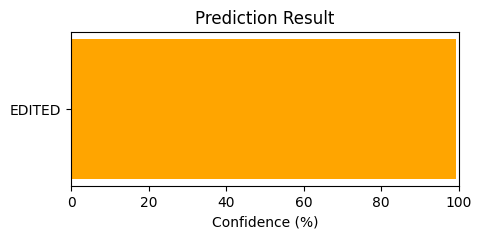

File: enhanced_C018-017.png
Predicted: EDITED
Confidence: 99.86 %


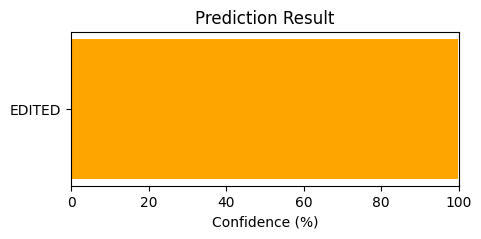

File: enhanced_B043-118.png
Predicted: EDITED
Confidence: 100.0 %


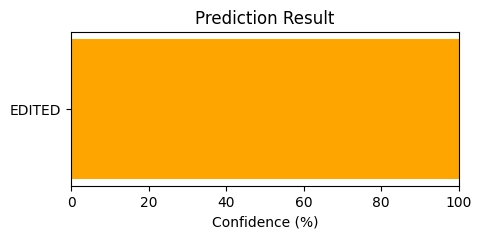

File: enhanced_C016-039.png
Predicted: EDITED
Confidence: 100.0 %


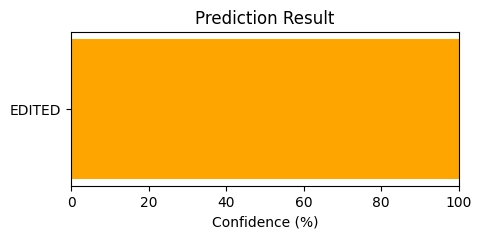

File: enhanced_C020-055.png
Predicted: EDITED
Confidence: 53.75 %


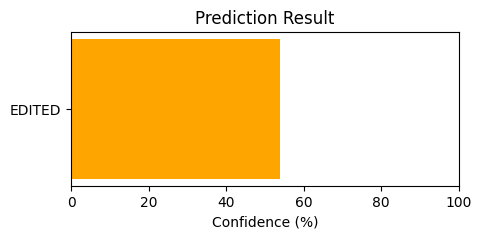

File: enhanced_B026-215.png
Predicted: EDITED
Confidence: 99.79 %


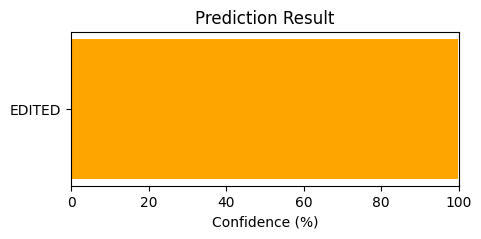

File: enhanced_A045-215.png
Predicted: EDITED
Confidence: 99.38 %


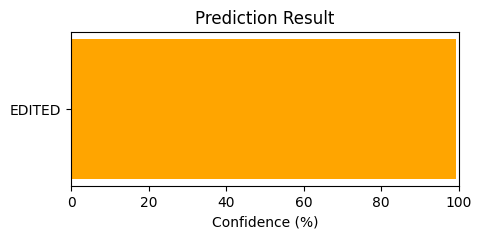

File: enhanced_C006-121.png
Predicted: EDITED
Confidence: 98.16 %


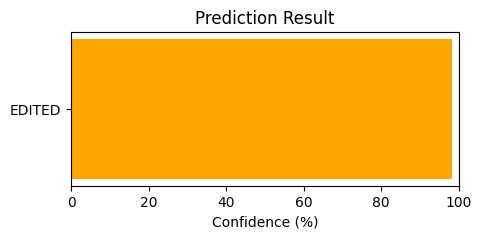

File: enhanced_A042-459.png
Predicted: EDITED
Confidence: 100.0 %


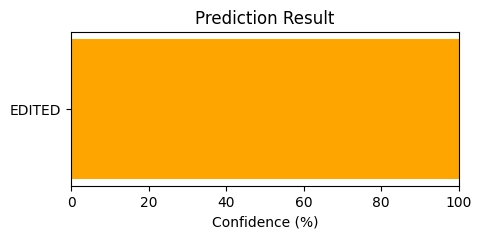

File: enhanced_B035-247.png
Predicted: EDITED
Confidence: 100.0 %


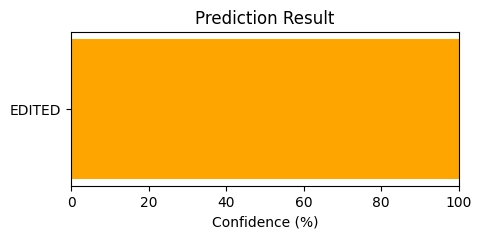

File: enhanced_B023-048.png
Predicted: EDITED
Confidence: 99.96 %


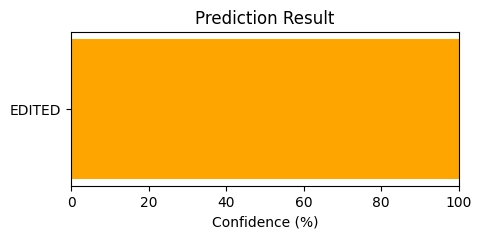

File: enhanced_C003-005.png
Predicted: EDITED
Confidence: 99.76 %


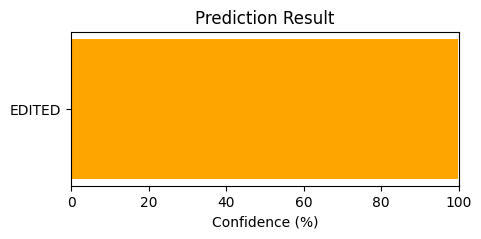

File: enhanced_B037-012.png
Predicted: EDITED
Confidence: 100.0 %


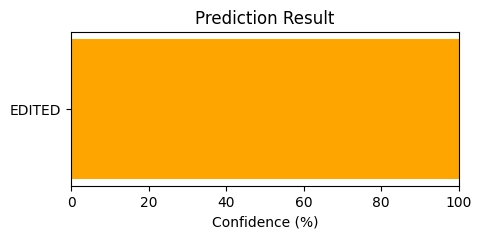

File: enhanced_B046-304.png
Predicted: EDITED
Confidence: 98.26 %


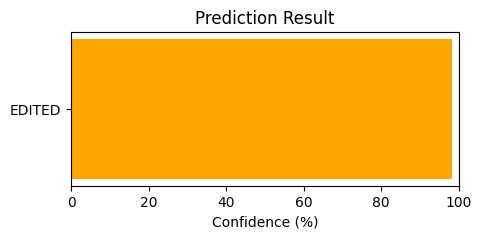

File: enhanced_B005-051.png
Predicted: EDITED
Confidence: 99.99 %


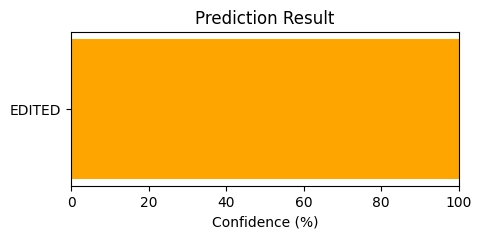

File: enhanced_A037-005.png
Predicted: EDITED
Confidence: 100.0 %


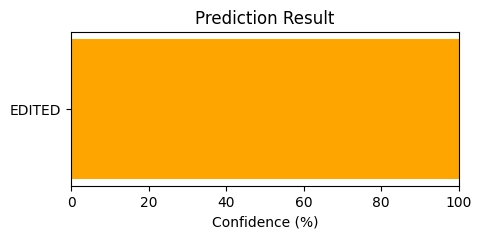

File: enhanced_C002-134.png
Predicted: EDITED
Confidence: 99.98 %


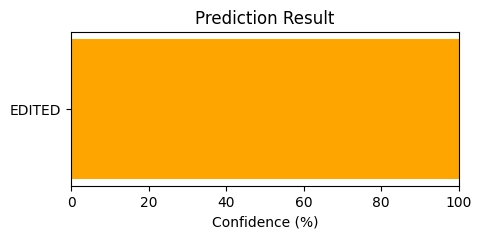

File: enhanced_B007-056.png
Predicted: EDITED
Confidence: 99.66 %


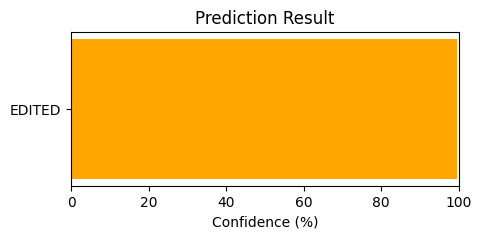

File: enhanced_C005-005.png
Predicted: EDITED
Confidence: 86.12 %


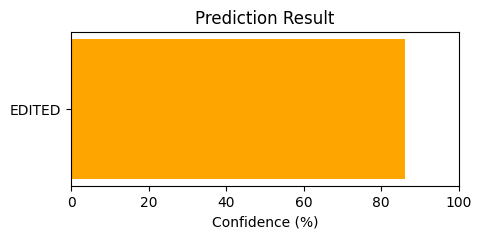

File: enhanced_C021-038.png
Predicted: EDITED
Confidence: 96.12 %


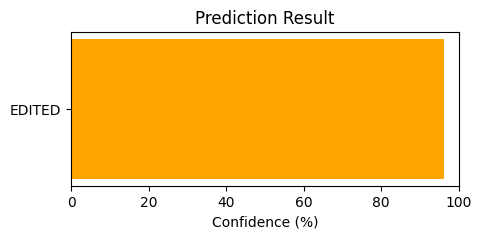

File: enhanced_B049-327.png
Predicted: EDITED
Confidence: 99.59 %


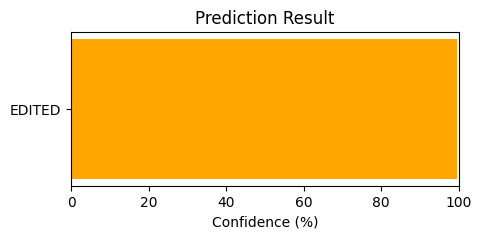

File: enhanced_C014-038.png
Predicted: EDITED
Confidence: 100.0 %


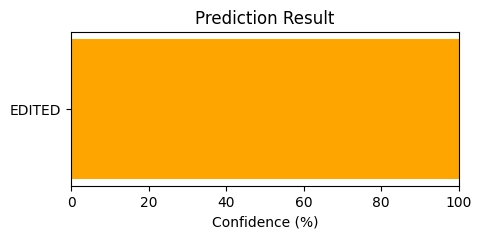

File: enhanced_C015-355.png
Predicted: EDITED
Confidence: 99.8 %


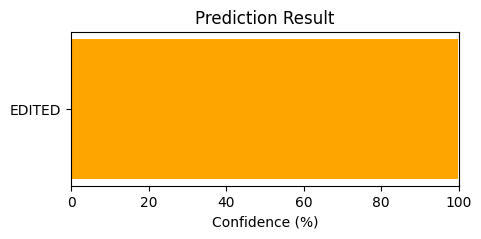

File: enhanced_B048-131.png
Predicted: EDITED
Confidence: 100.0 %


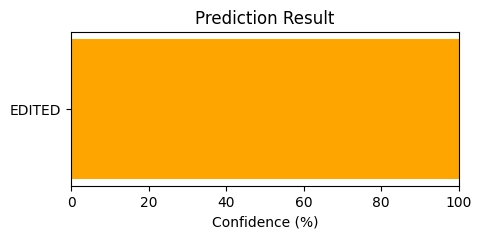

File: enhanced_B021-354.png
Predicted: EDITED
Confidence: 99.69 %


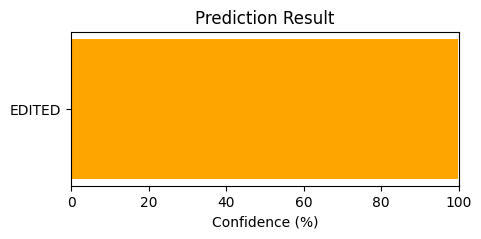

File: enhanced_B025-024.png
Predicted: EDITED
Confidence: 95.36 %


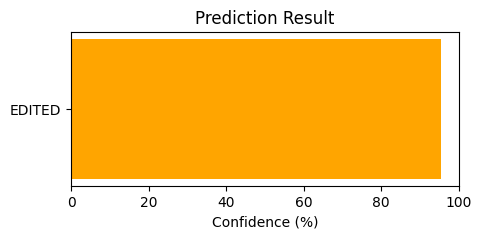

File: enhanced_A049-021.png
Predicted: EDITED
Confidence: 91.42 %


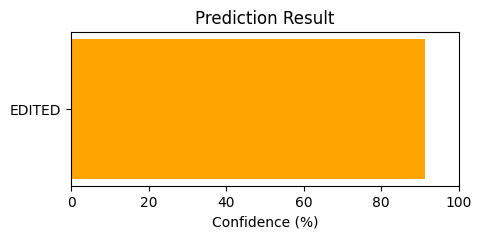

File: enhanced_C013-302.png
Predicted: EDITED
Confidence: 100.0 %


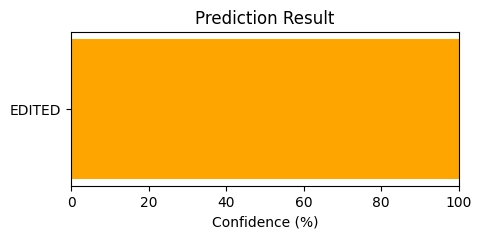

File: enhanced_C010-120.png
Predicted: EDITED
Confidence: 99.3 %


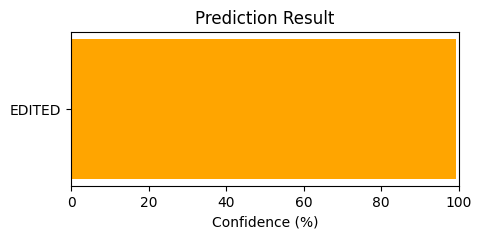

File: enhanced_C008-011.png
Predicted: EDITED
Confidence: 99.92 %


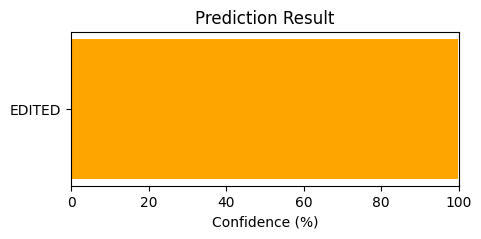

File: enhanced_A025-051.png
Predicted: EDITED
Confidence: 99.87 %


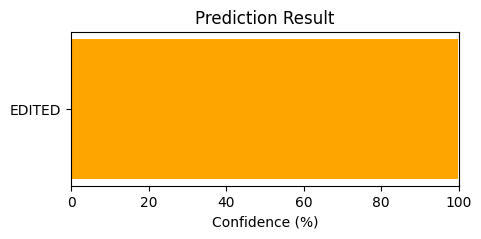

File: enhanced_B017-110.png
Predicted: EDITED
Confidence: 99.99 %


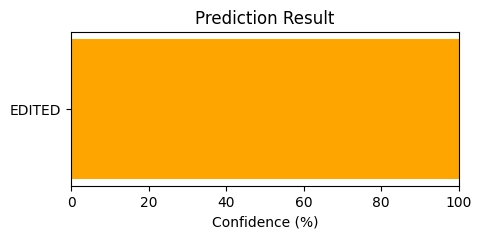

File: enhanced_E146-014.png
Predicted: EDITED
Confidence: 99.9 %


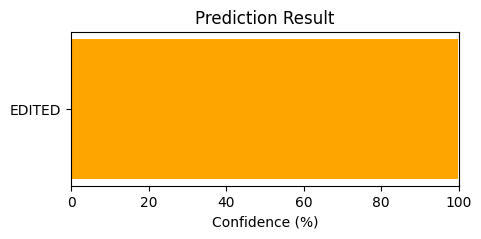

File: enhanced_A024-034.png
Predicted: EDITED
Confidence: 100.0 %


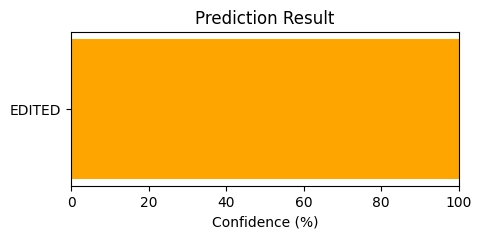

File: enhanced_B028-034.png
Predicted: EDITED
Confidence: 94.48 %


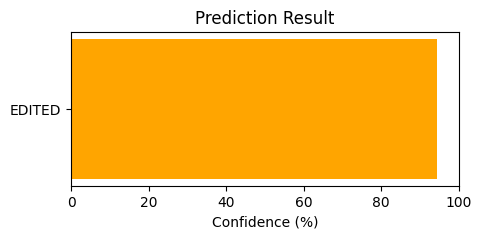

File: enhanced_A005-023.png
Predicted: EDITED
Confidence: 99.93 %


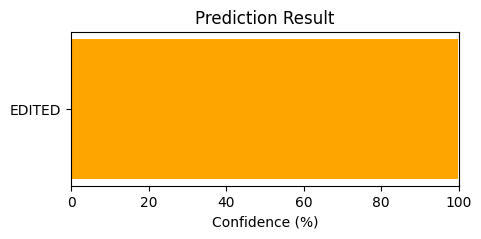

File: enhanced_E034-008.png
Predicted: EDITED
Confidence: 100.0 %


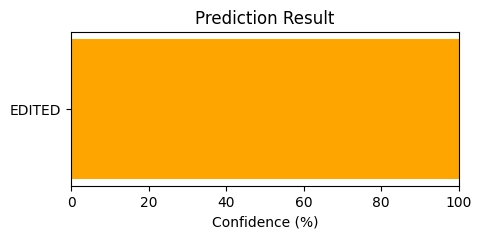

File: enhanced_B015-017.png
Predicted: EDITED
Confidence: 100.0 %


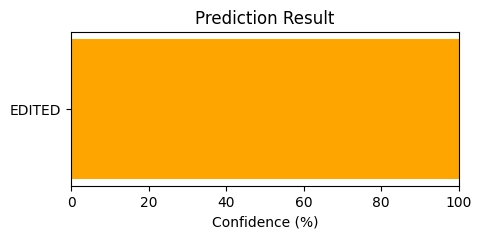

File: enhanced_B044-136.png
Predicted: EDITED
Confidence: 99.41 %


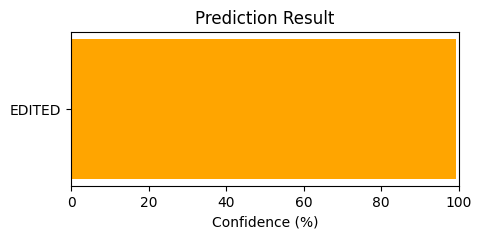

File: enhanced_A033-052.png
Predicted: EDITED
Confidence: 99.91 %


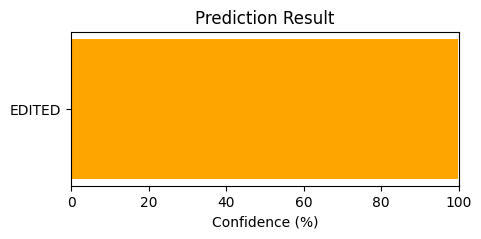

File: enhanced_E035-002.png
Predicted: EDITED
Confidence: 100.0 %


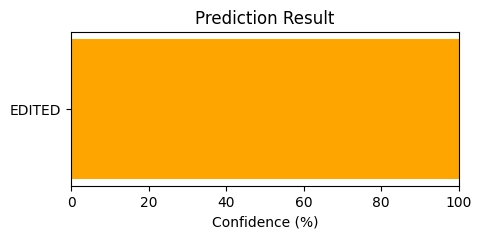

File: enhanced_A008-229.png
Predicted: EDITED
Confidence: 99.34 %


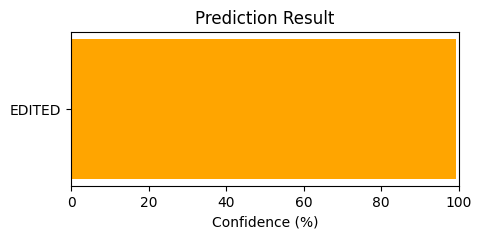

File: enhanced_B011-102.png
Predicted: EDITED
Confidence: 98.15 %


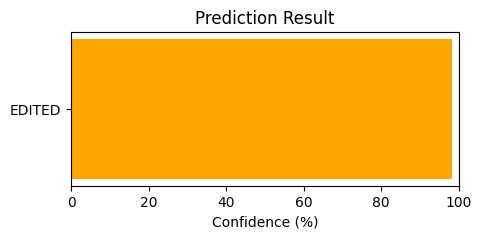

File: enhanced_B022-045.png
Predicted: EDITED
Confidence: 100.0 %


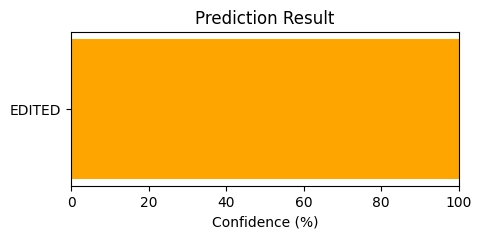

File: enhanced_C001-103.png
Predicted: EDITED
Confidence: 100.0 %


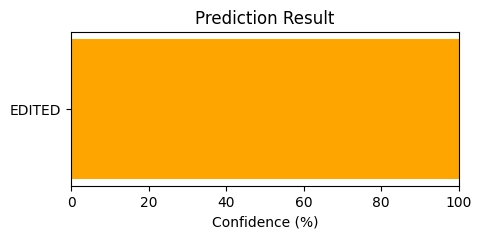

File: enhanced_A031-024.png
Predicted: EDITED
Confidence: 99.12 %


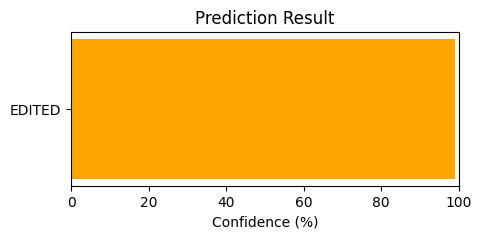

File: enhanced_B040-037.png
Predicted: EDITED
Confidence: 100.0 %


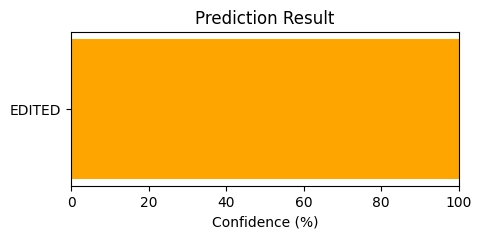

File: enhanced_A018-056.png
Predicted: EDITED
Confidence: 99.98 %


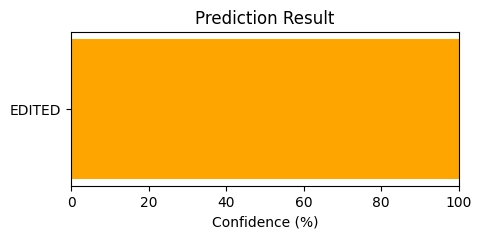

File: enhanced_A027-106.png
Predicted: EDITED
Confidence: 99.97 %


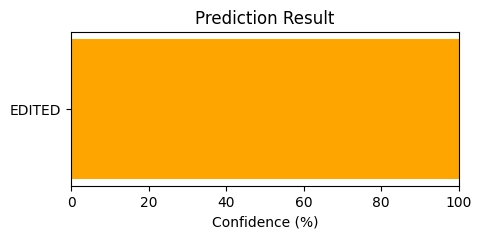

File: enhanced_A050-200.png
Predicted: EDITED
Confidence: 99.99 %


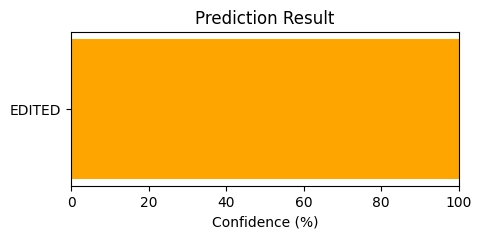

File: enhanced_A035-116.png
Predicted: EDITED
Confidence: 99.98 %


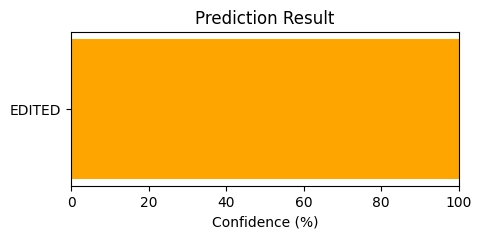

File: enhanced_A003-032.png
Predicted: EDITED
Confidence: 93.31 %


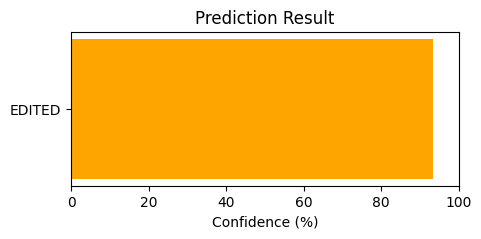

File: enhanced_F013-030.png
Predicted: EDITED
Confidence: 64.7 %


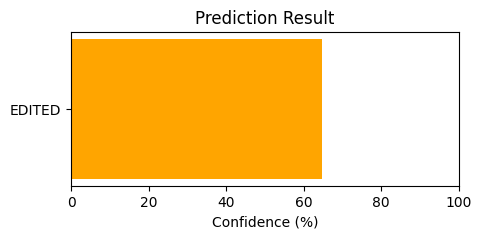

File: enhanced_B001-047.png
Predicted: EDITED
Confidence: 99.92 %


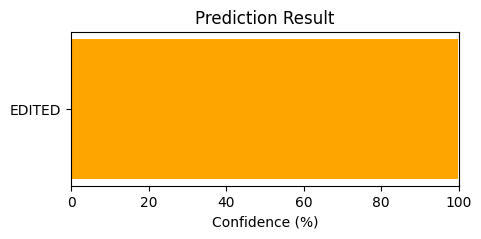

File: enhanced_B004-045.png
Predicted: EDITED
Confidence: 100.0 %


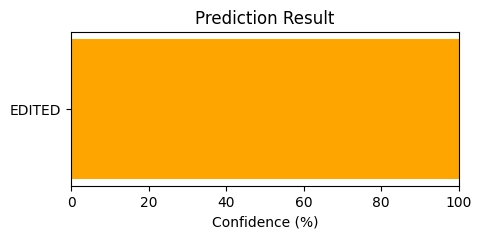

File: enhanced_A026-008.png
Predicted: EDITED
Confidence: 99.96 %


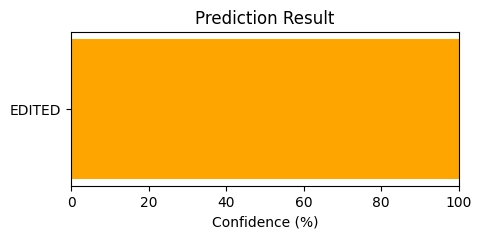

File: enhanced_A040-126.png
Predicted: EDITED
Confidence: 99.86 %


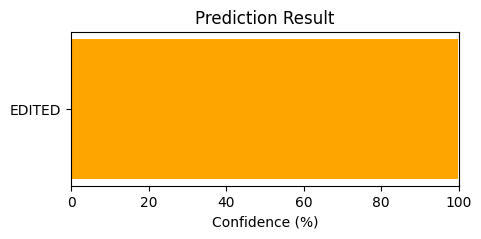

File: enhanced_E030-036.png
Predicted: EDITED
Confidence: 99.86 %


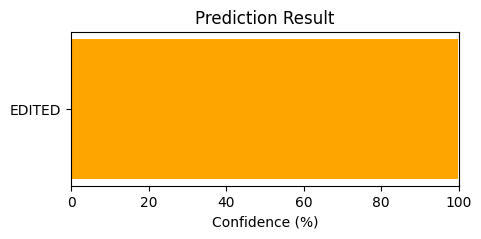

File: enhanced_A001-010.png
Predicted: EDITED
Confidence: 100.0 %


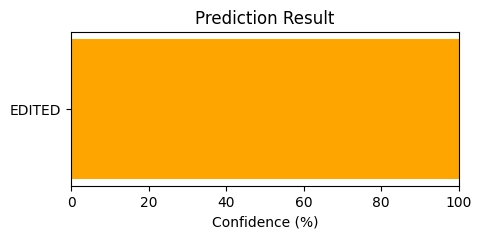

File: enhanced_E127-113.png
Predicted: EDITED
Confidence: 99.99 %


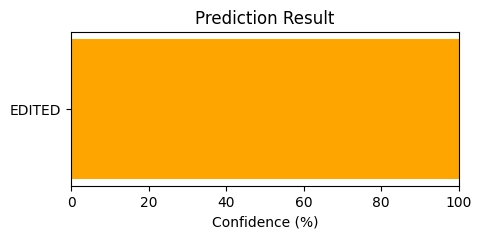

File: enhanced_E002-010.png
Predicted: EDITED
Confidence: 99.93 %


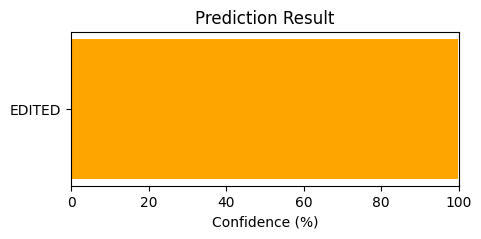

File: enhanced_E145-014.png
Predicted: EDITED
Confidence: 99.88 %


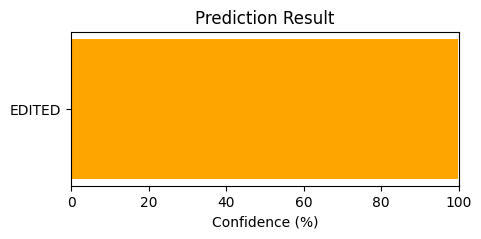

File: enhanced_E031-002.png
Predicted: EDITED
Confidence: 100.0 %


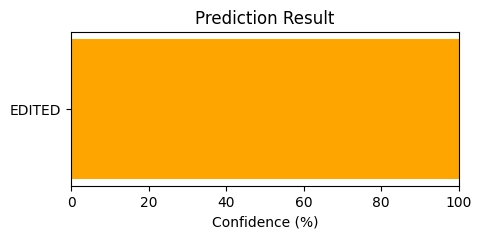

File: enhanced_D045-215.png
Predicted: EDITED
Confidence: 100.0 %


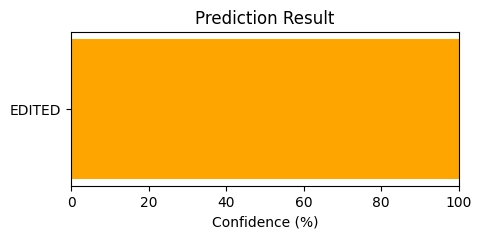

File: enhanced_A023-033.png
Predicted: EDITED
Confidence: 91.74 %


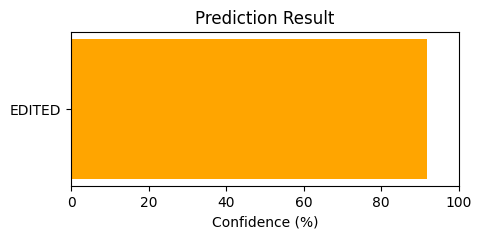

File: enhanced_F011-109.png
Predicted: EDITED
Confidence: 99.99 %


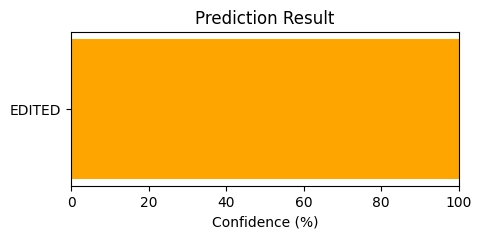

File: enhanced_D031-112.png
Predicted: EDITED
Confidence: 100.0 %


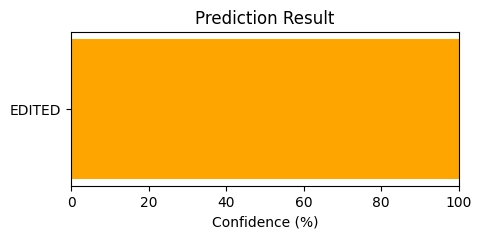

File: enhanced_D046-053.png
Predicted: EDITED
Confidence: 99.96 %


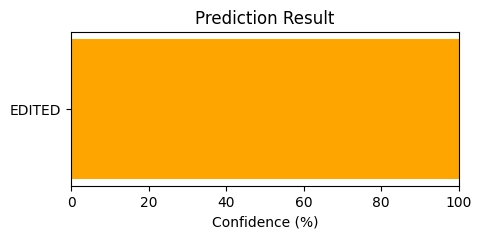

File: enhanced_E028-016.png
Predicted: EDITED
Confidence: 99.99 %


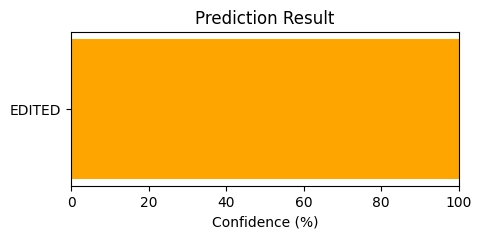

File: enhanced_A013-004.png
Predicted: EDITED
Confidence: 99.91 %


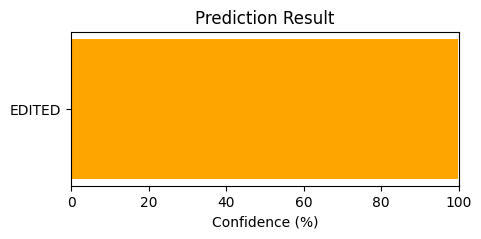

File: enhanced_E075-004.png
Predicted: EDITED
Confidence: 100.0 %


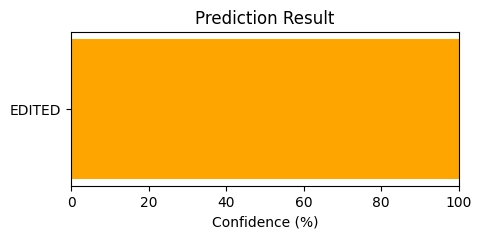

File: enhanced_A048-135.png
Predicted: EDITED
Confidence: 99.8 %


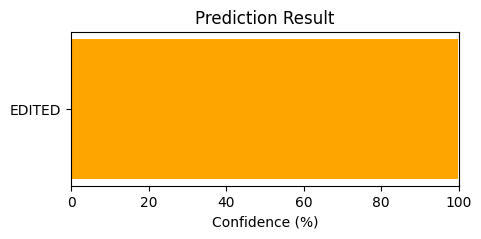

File: enhanced_E020-022.png
Predicted: EDITED
Confidence: 99.85 %


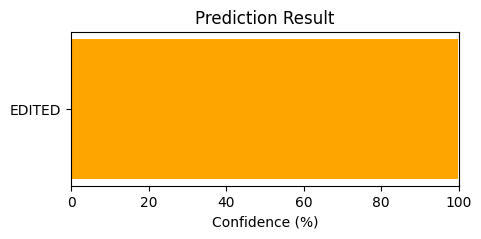

File: enhanced_F017-021.png
Predicted: EDITED
Confidence: 99.66 %


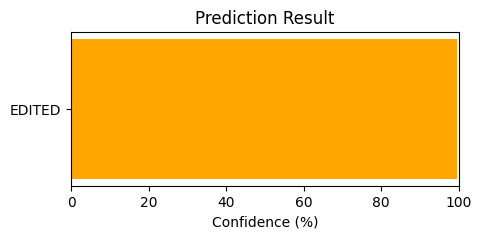

File: enhanced_F004-022.png
Predicted: EDITED
Confidence: 81.69 %


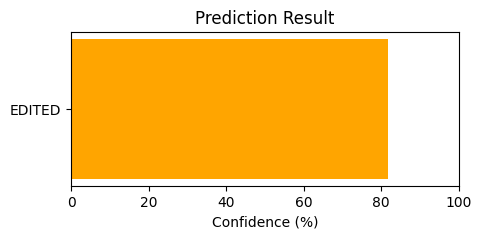

File: enhanced_F014-310.png
Predicted: EDITED
Confidence: 100.0 %


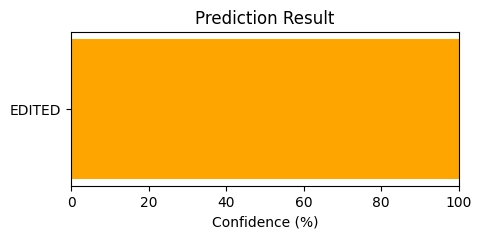

File: enhanced_A017-047.png
Predicted: EDITED
Confidence: 99.99 %


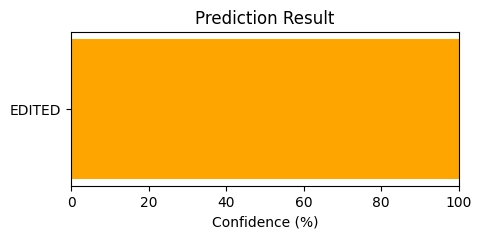

File: enhanced_E021-002.png
Predicted: EDITED
Confidence: 99.66 %


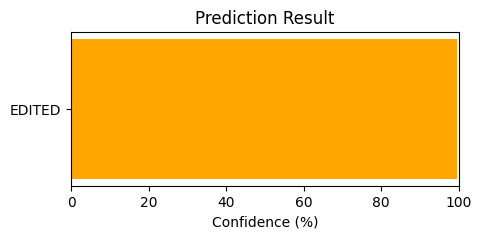

File: enhanced_H015-113.png
Predicted: EDITED
Confidence: 98.87 %


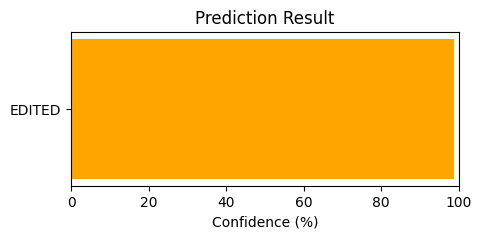

File: enhanced_D020-114.png
Predicted: EDITED
Confidence: 99.99 %


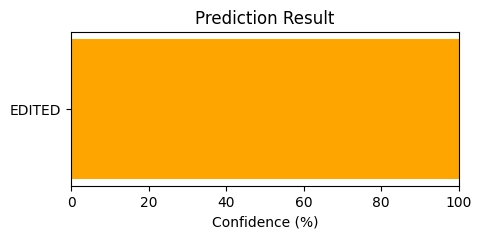

File: enhanced_E029-004.png
Predicted: EDITED
Confidence: 99.95 %


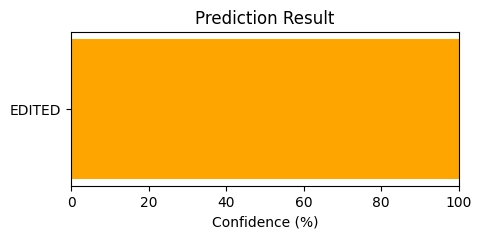

File: enhanced_E010-008.png
Predicted: EDITED
Confidence: 100.0 %


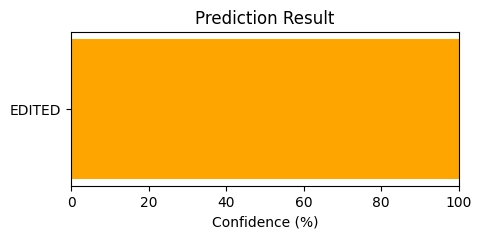

File: enhanced_E013-015.png
Predicted: EDITED
Confidence: 99.96 %


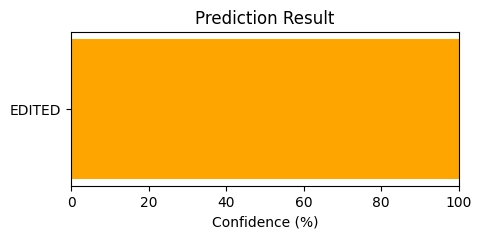

File: enhanced_D022-114.png
Predicted: EDITED
Confidence: 99.71 %


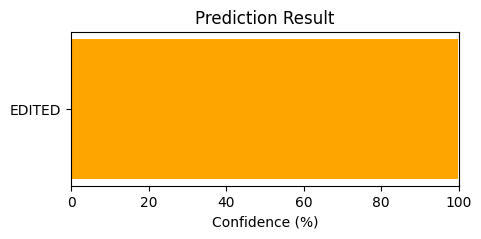

File: enhanced_C049-005.png
Predicted: EDITED
Confidence: 98.24 %


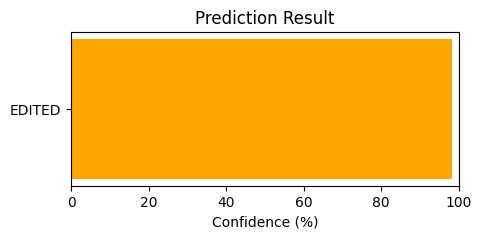

File: enhanced_D048-025.png
Predicted: EDITED
Confidence: 100.0 %


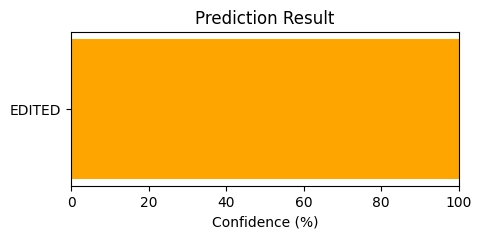

File: enhanced_E039-002.png
Predicted: EDITED
Confidence: 100.0 %


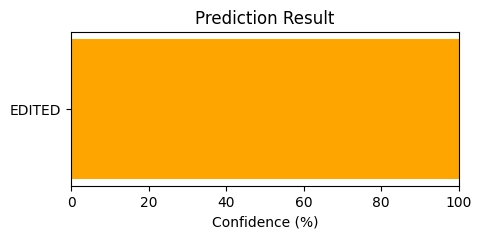

File: enhanced_H020-018.png
Predicted: EDITED
Confidence: 98.67 %


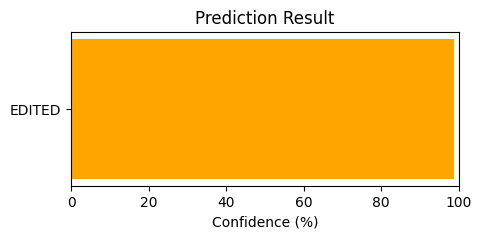

File: enhanced_E032-020.png
Predicted: EDITED
Confidence: 99.72 %


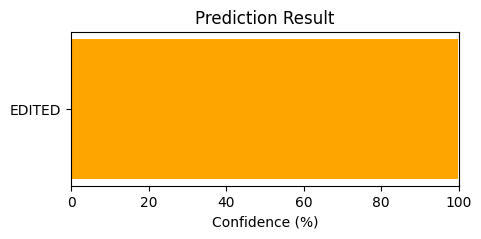

File: enhanced_E012-009.png
Predicted: EDITED
Confidence: 100.0 %


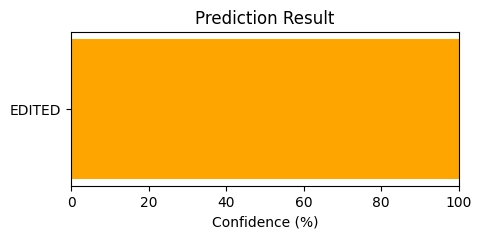

File: enhanced_E011-009.png
Predicted: EDITED
Confidence: 100.0 %


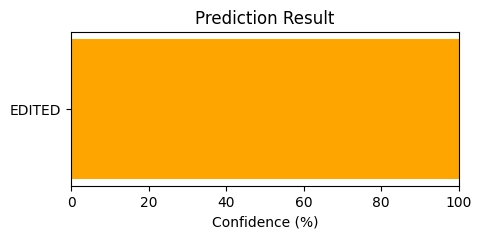

File: enhanced_D021-040.png
Predicted: EDITED
Confidence: 100.0 %


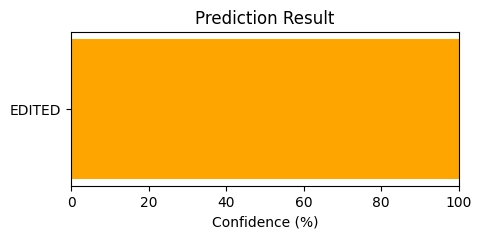

File: enhanced_E019-027.png
Predicted: EDITED
Confidence: 99.83 %


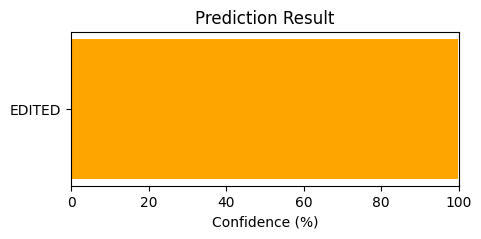

File: enhanced_E004-005.png
Predicted: EDITED
Confidence: 99.91 %


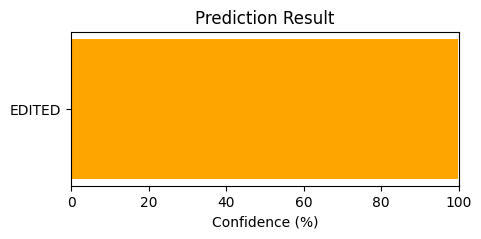

File: enhanced_H014-005.png
Predicted: EDITED
Confidence: 99.91 %


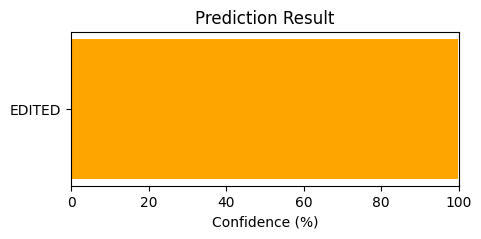

File: enhanced_D027-036.png
Predicted: EDITED
Confidence: 99.9 %


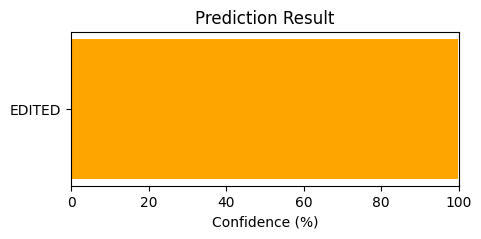

File: enhanced_D007-030.png
Predicted: EDITED
Confidence: 99.85 %


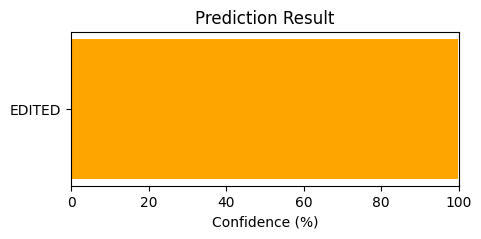

File: enhanced_G042-129.png
Predicted: EDITED
Confidence: 100.0 %


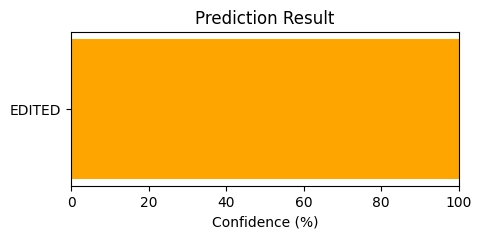

File: enhanced_H013-115.png
Predicted: EDITED
Confidence: 100.0 %


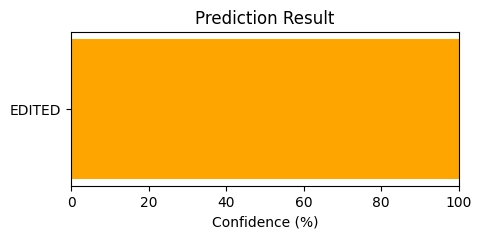

File: enhanced_D004-015.png
Predicted: EDITED
Confidence: 100.0 %


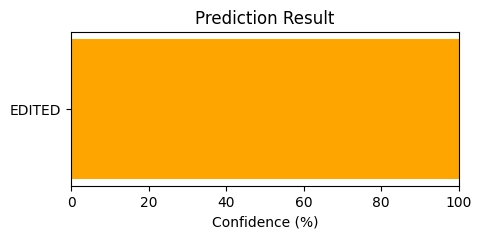

File: enhanced_D001-049.png
Predicted: EDITED
Confidence: 100.0 %


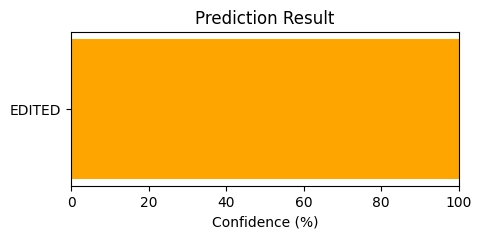

File: enhanced_D026-037.png
Predicted: EDITED
Confidence: 99.65 %


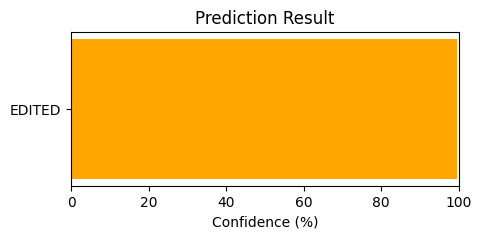

File: enhanced_D017-047.png
Predicted: EDITED
Confidence: 99.83 %


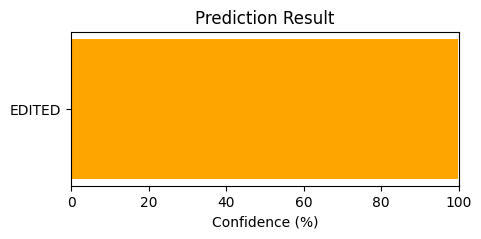

File: enhanced_H008-146.png
Predicted: EDITED
Confidence: 100.0 %


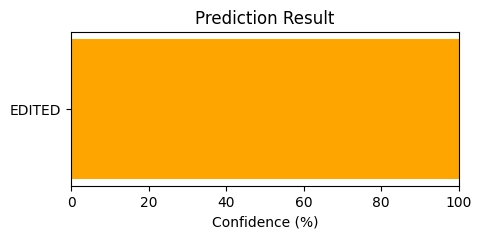

File: enhanced_C042-301.png
Predicted: EDITED
Confidence: 99.96 %


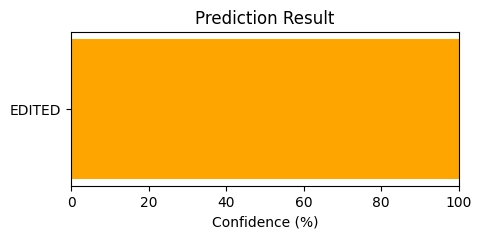

File: enhanced_G044-612.png
Predicted: EDITED
Confidence: 100.0 %


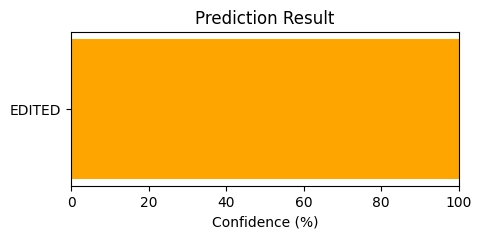

File: enhanced_D010-142.png
Predicted: EDITED
Confidence: 99.68 %


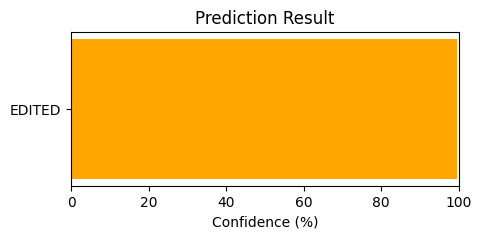

File: enhanced_D013-029.png
Predicted: EDITED
Confidence: 99.45 %


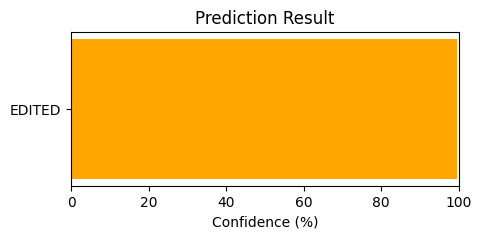

File: enhanced_H018-037.png
Predicted: EDITED
Confidence: 96.64 %


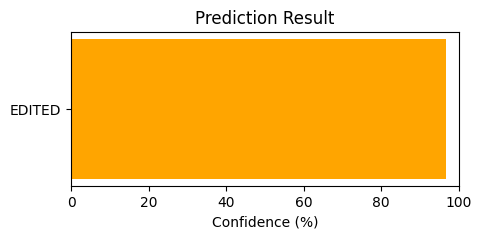

File: enhanced_C052-041.png
Predicted: EDITED
Confidence: 97.42 %


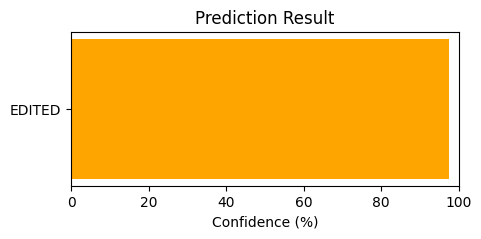

File: enhanced_D002-128.png
Predicted: EDITED
Confidence: 100.0 %


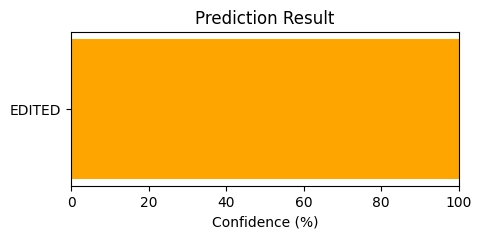

File: enhanced_E027-003.png
Predicted: EDITED
Confidence: 99.93 %


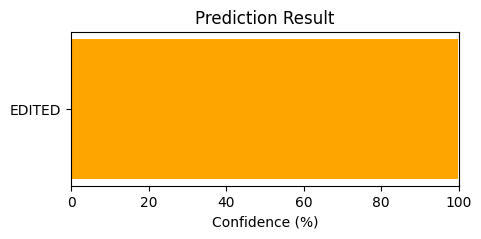

File: enhanced_D019-008.png
Predicted: EDITED
Confidence: 100.0 %


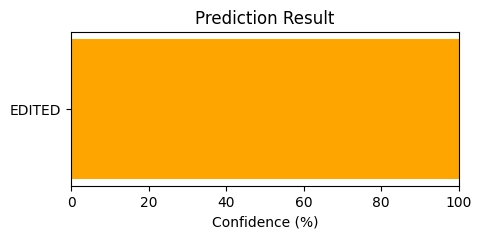

File: enhanced_C044-034.png
Predicted: EDITED
Confidence: 99.83 %


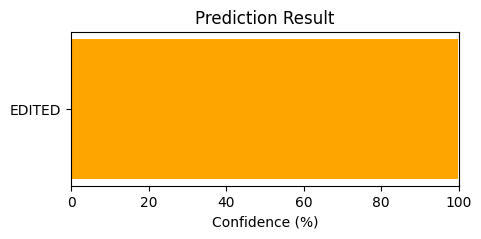

File: enhanced_G049-036.png
Predicted: EDITED
Confidence: 99.99 %


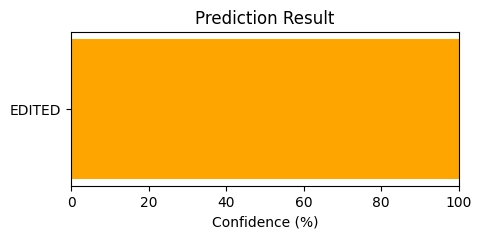

File: enhanced_G048-008.png
Predicted: EDITED
Confidence: 100.0 %


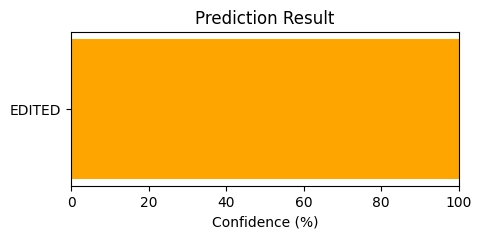

File: enhanced_H017-011.png
Predicted: EDITED
Confidence: 99.97 %


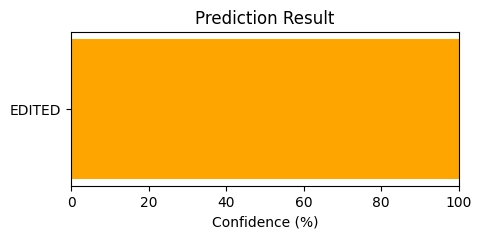

File: enhanced_G019-009.png
Predicted: EDITED
Confidence: 100.0 %


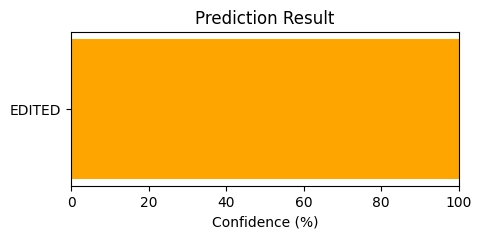

File: enhanced_G016-023.png
Predicted: EDITED
Confidence: 99.98 %


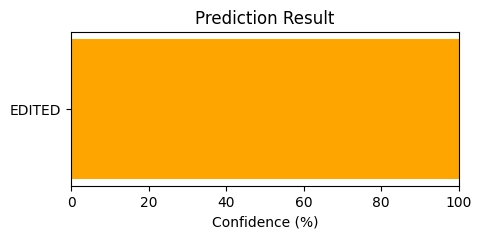

File: enhanced_G020-119.png
Predicted: EDITED
Confidence: 100.0 %


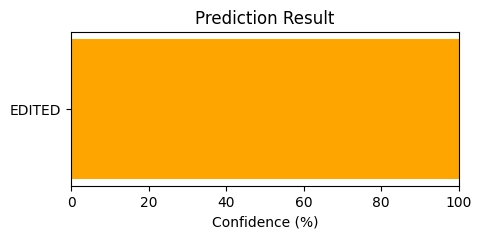

File: enhanced_C051-022.png
Predicted: EDITED
Confidence: 99.98 %


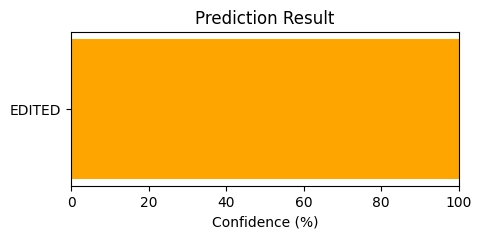

File: enhanced_G052-133.png
Predicted: EDITED
Confidence: 100.0 %


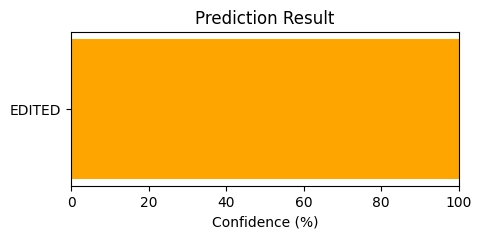

File: enhanced_H031-028.png
Predicted: EDITED
Confidence: 100.0 %


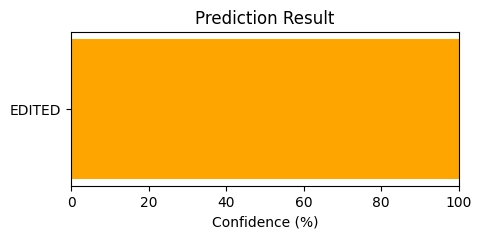

File: enhanced_D016-121.png
Predicted: EDITED
Confidence: 100.0 %


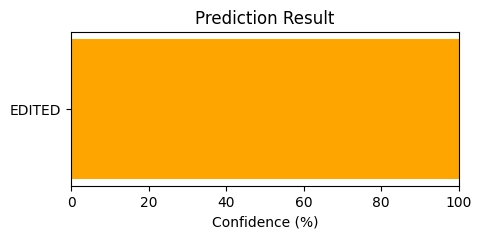

File: enhanced_D009-033.png
Predicted: EDITED
Confidence: 100.0 %


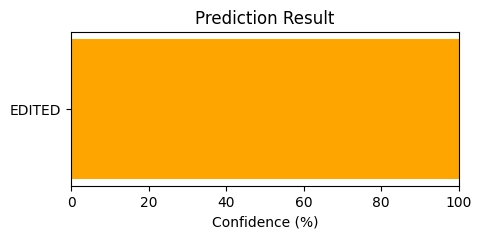

File: enhanced_H010-113.png
Predicted: EDITED
Confidence: 100.0 %


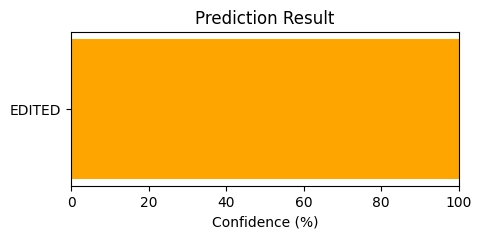

File: enhanced_H033-019.png
Predicted: EDITED
Confidence: 99.94 %


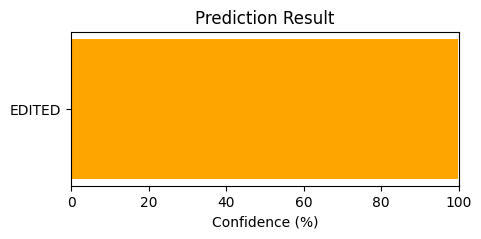

File: enhanced_G010-028.png
Predicted: EDITED
Confidence: 99.93 %


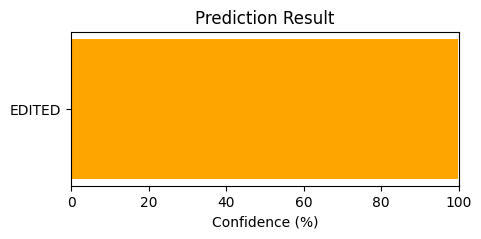

File: enhanced_H049-208.png
Predicted: EDITED
Confidence: 99.98 %


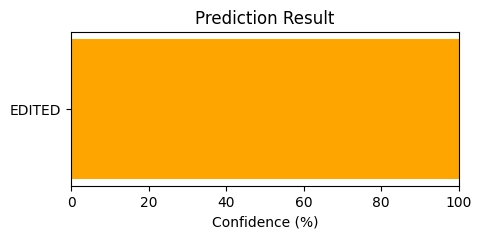

File: enhanced_D006-331.png
Predicted: EDITED
Confidence: 100.0 %


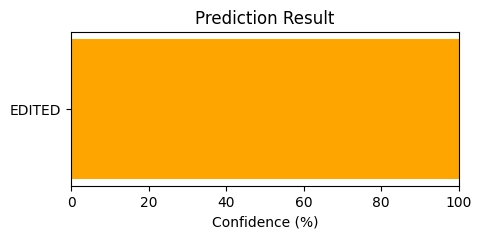

File: enhanced_C032-006.png
Predicted: EDITED
Confidence: 99.49 %


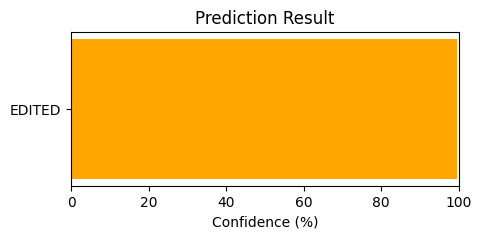

File: enhanced_G031-007.png
Predicted: EDITED
Confidence: 100.0 %


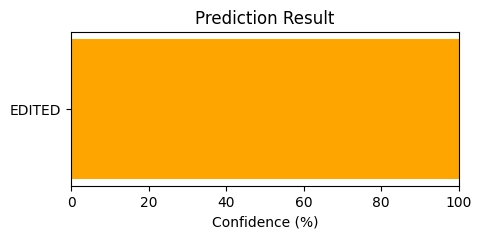

File: enhanced_G005-028.png
Predicted: EDITED
Confidence: 99.98 %


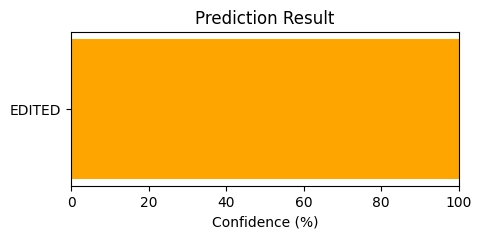

File: enhanced_H011-037.png
Predicted: EDITED
Confidence: 99.42 %


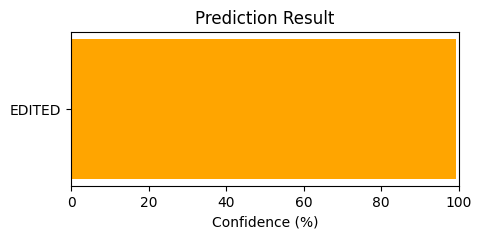

File: enhanced_G029-038.png
Predicted: EDITED
Confidence: 100.0 %


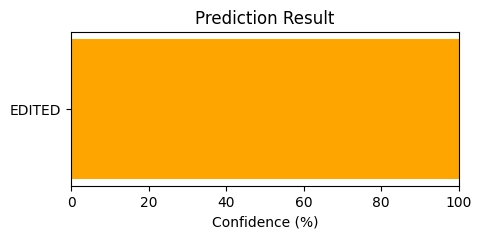

File: enhanced_H042-138.png
Predicted: EDITED
Confidence: 99.46 %


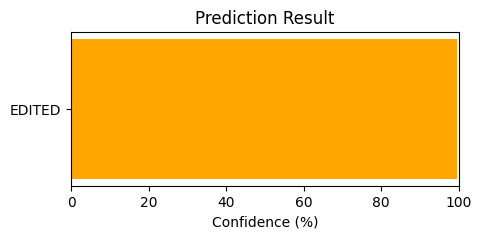

File: enhanced_H001-042.png
Predicted: EDITED
Confidence: 97.79 %


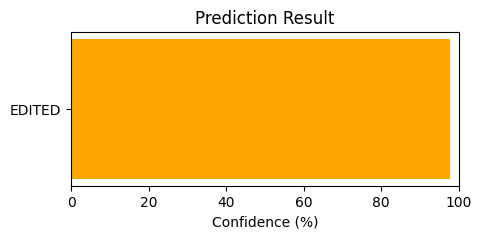

File: enhanced_G040-445.png
Predicted: EDITED
Confidence: 100.0 %


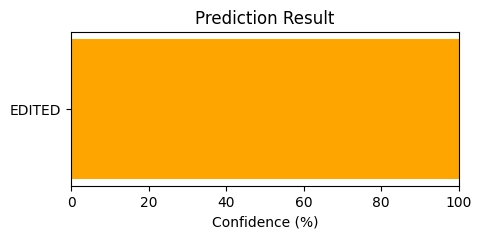

File: enhanced_C030-033.png
Predicted: EDITED
Confidence: 100.0 %


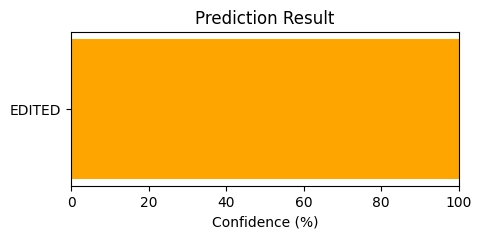

File: enhanced_F048-048.png
Predicted: EDITED
Confidence: 99.92 %


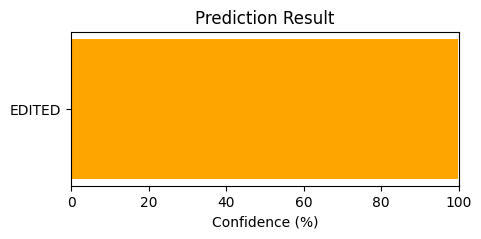

File: enhanced_H012-020.png
Predicted: EDITED
Confidence: 100.0 %


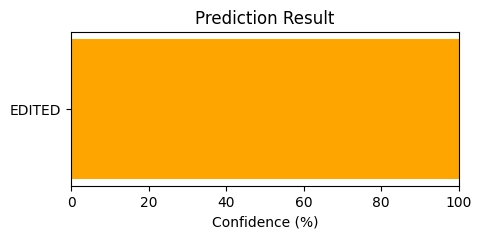

File: enhanced_C031-041.png
Predicted: EDITED
Confidence: 99.86 %


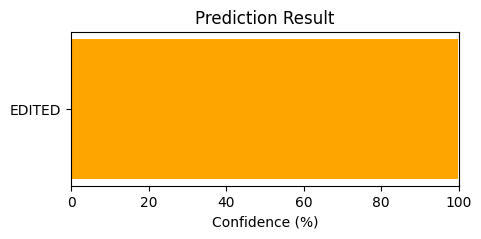

File: enhanced_G021-111.png
Predicted: EDITED
Confidence: 99.99 %


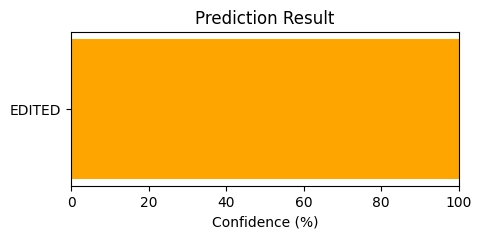

File: enhanced_G017-013.png
Predicted: EDITED
Confidence: 100.0 %


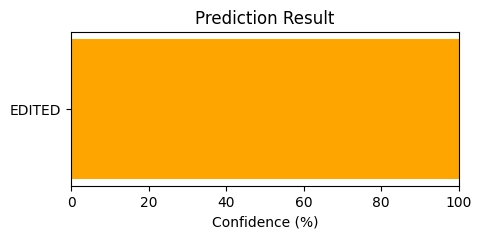

File: enhanced_H026-018 (1).png
Predicted: EDITED
Confidence: 82.62 %


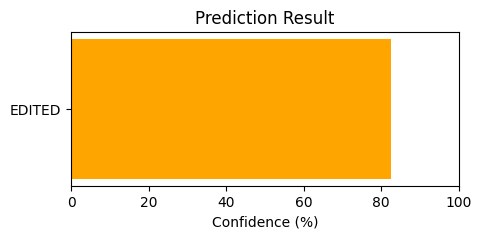

File: enhanced_C038-004.png
Predicted: EDITED
Confidence: 94.42 %


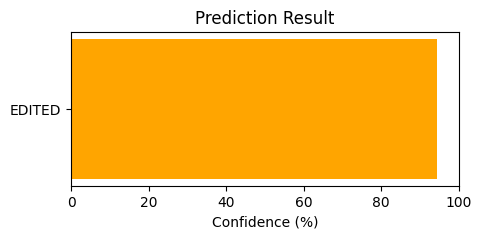

File: enhanced_F054-005.png
Predicted: EDITED
Confidence: 99.97 %


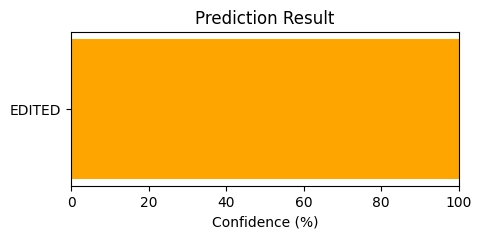

File: enhanced_H035-013.png
Predicted: EDITED
Confidence: 99.9 %


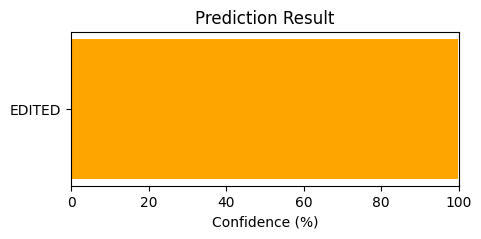

File: enhanced_H043-140.png
Predicted: EDITED
Confidence: 99.84 %


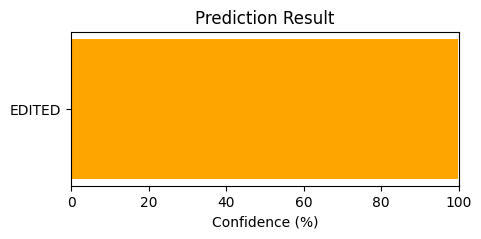

File: enhanced_G008-253.png
Predicted: EDITED
Confidence: 99.99 %


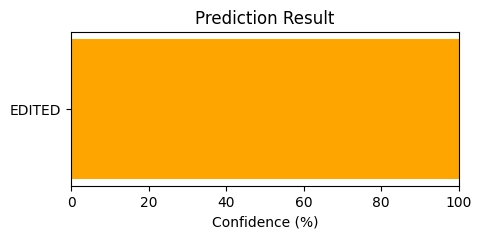

File: enhanced_F039-023.png
Predicted: EDITED
Confidence: 100.0 %


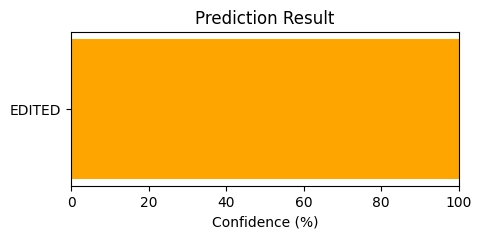

File: enhanced_F031-045.png
Predicted: EDITED
Confidence: 100.0 %


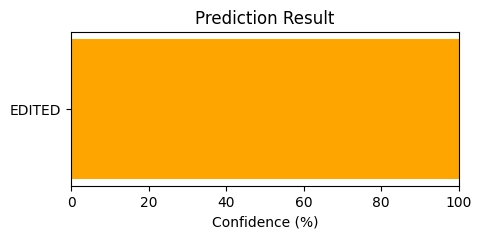

File: enhanced_G015-110.png
Predicted: EDITED
Confidence: 100.0 %


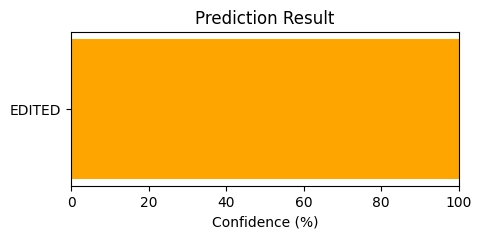

File: enhanced_H048-206.png
Predicted: EDITED
Confidence: 100.0 %


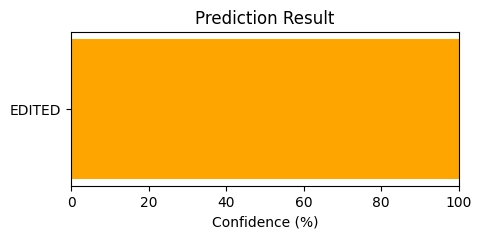

File: enhanced_F050-056.png
Predicted: EDITED
Confidence: 99.75 %


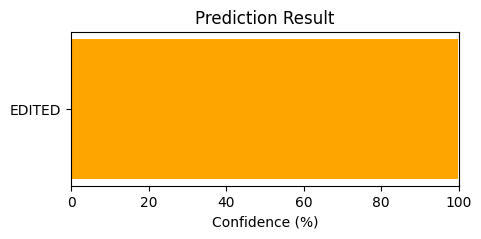

File: enhanced_G009-227.png
Predicted: EDITED
Confidence: 100.0 %


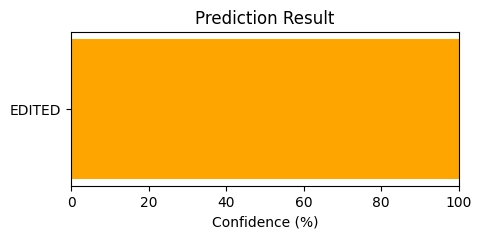

File: enhanced_F020-208.png
Predicted: EDITED
Confidence: 99.99 %


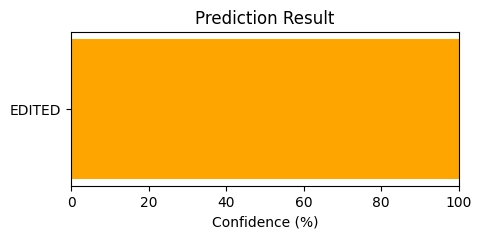

File: enhanced_H040-008.png
Predicted: EDITED
Confidence: 100.0 %


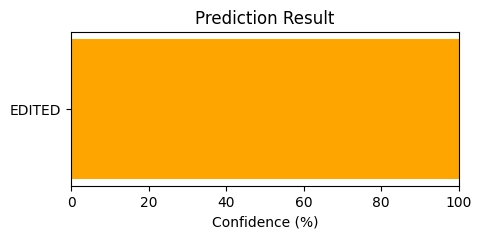

File: enhanced_G001-101.png
Predicted: EDITED
Confidence: 100.0 %


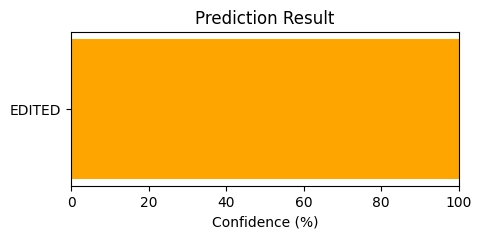

File: enhanced_H022-144.png
Predicted: EDITED
Confidence: 100.0 %


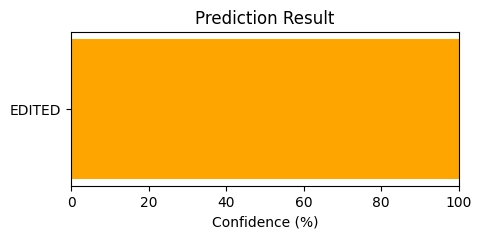

File: enhanced_F025-045.png
Predicted: EDITED
Confidence: 99.96 %


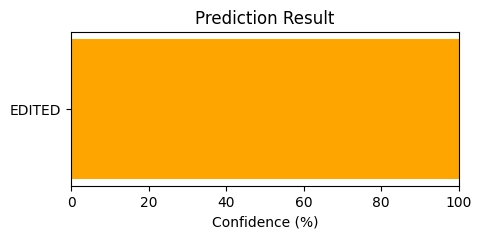

File: enhanced_F028-009.png
Predicted: EDITED
Confidence: 100.0 %


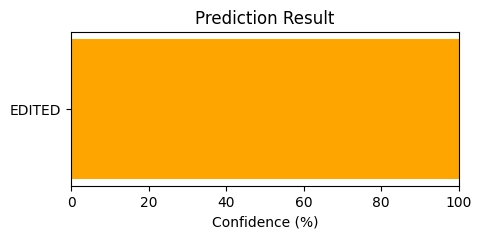

File: enhanced_F023-012.png
Predicted: EDITED
Confidence: 99.35 %


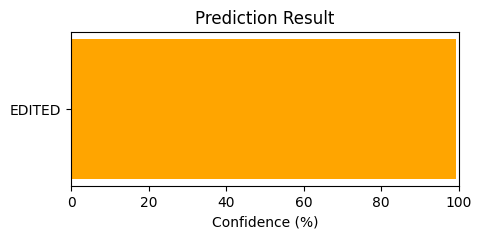

File: enhanced_F036-121.png
Predicted: EDITED
Confidence: 99.85 %


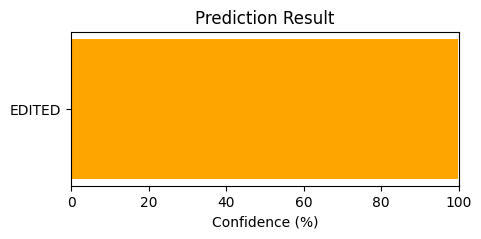

File: enhanced_F026-002.png
Predicted: EDITED
Confidence: 97.48 %


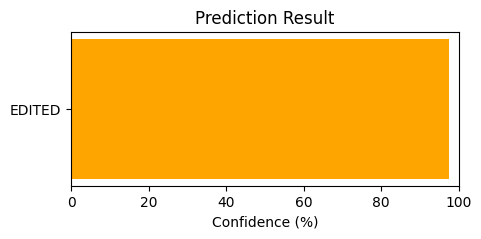

File: enhanced_H024-023.png
Predicted: EDITED
Confidence: 99.97 %


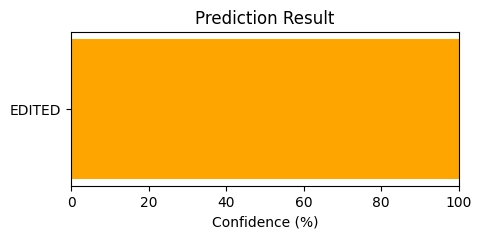

File: enhanced_H027-015.png
Predicted: EDITED
Confidence: 99.91 %


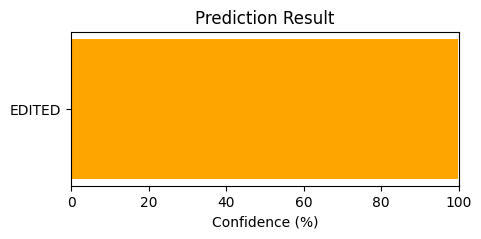

File: enhanced_C023-016.png
Predicted: EDITED
Confidence: 98.89 %


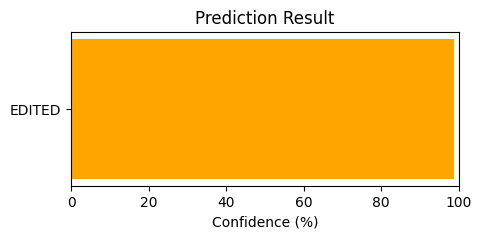

File: enhanced_F041-019.png
Predicted: EDITED
Confidence: 99.97 %


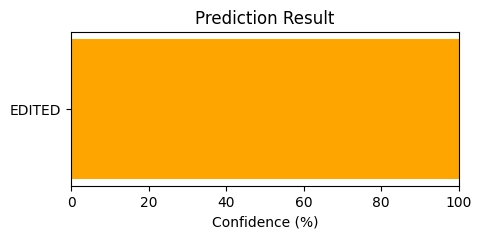

File: enhanced_F022-137 (1).png
Predicted: EDITED
Confidence: 100.0 %


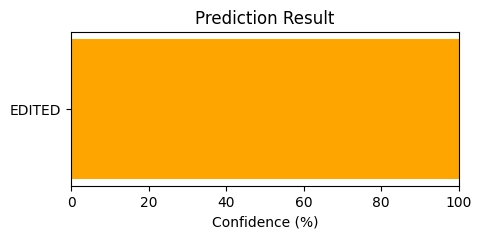

File: enhanced_H036-022.png
Predicted: EDITED
Confidence: 100.0 %


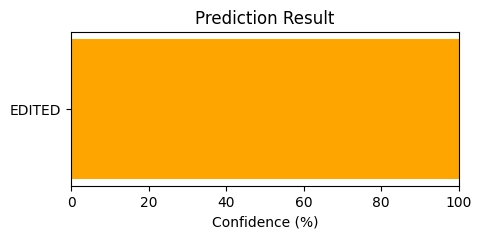

File: enhanced_C025-040.png
Predicted: EDITED
Confidence: 100.0 %


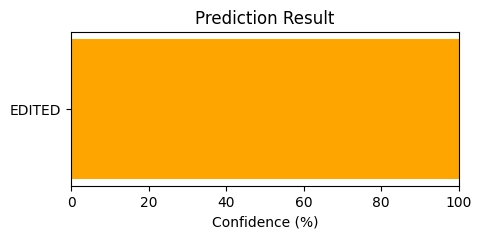

File: enhanced_F019-037 (1).png
Predicted: EDITED
Confidence: 100.0 %


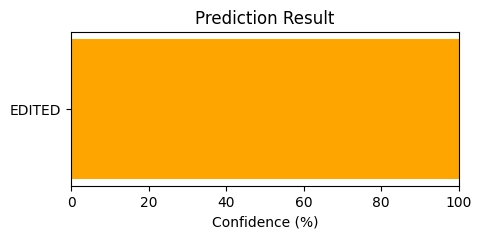

File: enhanced_H023-301.png
Predicted: EDITED
Confidence: 100.0 %


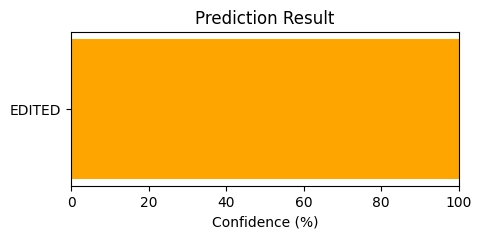

File: enhanced_C027-105.png
Predicted: EDITED
Confidence: 99.98 %


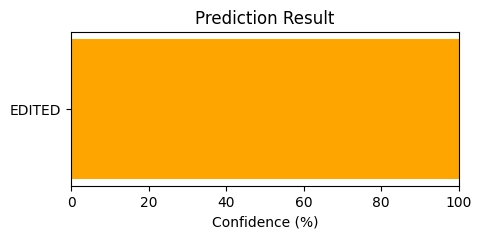

File: enhanced_F030-024.png
Predicted: EDITED
Confidence: 99.94 %


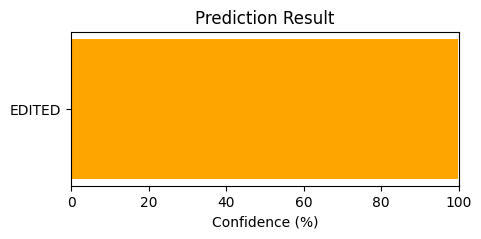

File: enhanced_H028-123.png
Predicted: EDITED
Confidence: 98.4 %


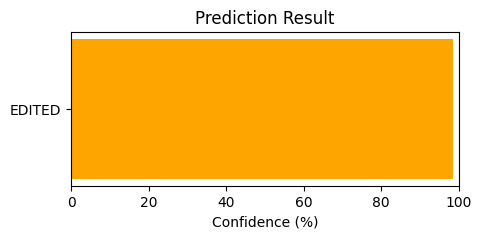

File: enhanced_H034-044.png
Predicted: EDITED
Confidence: 99.28 %


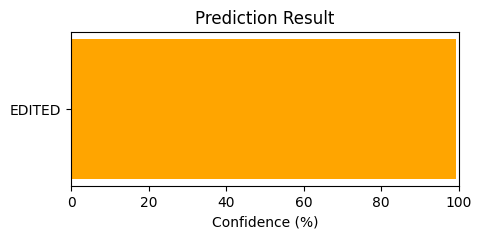

File: enhanced_C022-159.png
Predicted: EDITED
Confidence: 99.99 %


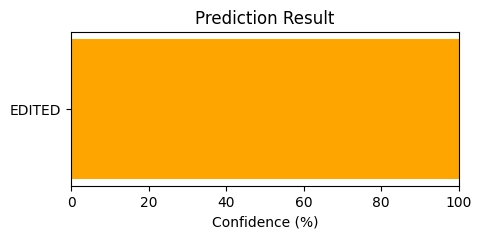

File: enhanced_F033-430.png
Predicted: EDITED
Confidence: 99.96 %


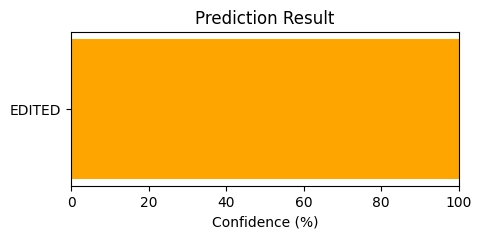

File: enhanced_D012-025.png
Predicted: EDITED
Confidence: 100.0 %


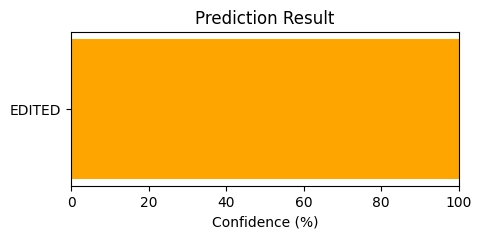

File: enhanced_F018-029 (3).png
Predicted: EDITED
Confidence: 99.96 %


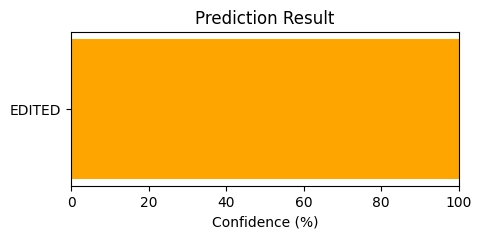

File: enhanced_C028-106.png
Predicted: EDITED
Confidence: 98.84 %


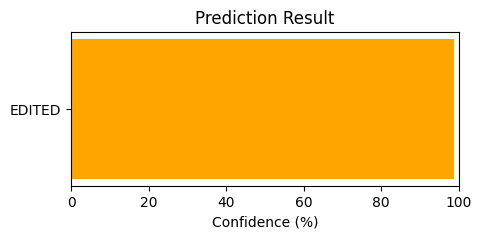

File: enhanced_C029-029.png
Predicted: EDITED
Confidence: 100.0 %


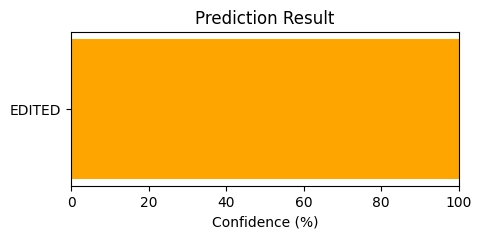


CATEGORY: AI GENERATED

File: AI_A024-034.png
Predicted: AI GENERATED
Confidence: 51.48 %


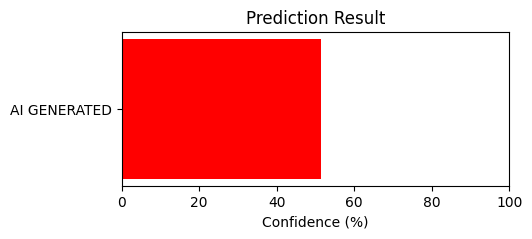

File: AI_A025-051.png
Predicted: AI GENERATED
Confidence: 80.0 %


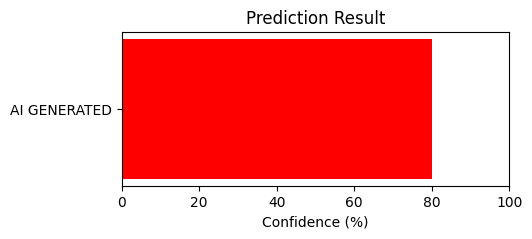

File: AI_A003-032.png
Predicted: REAL
Confidence: 46.96 %


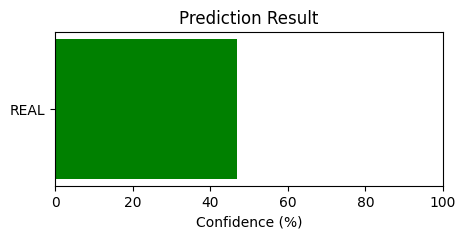

File: AI_A037-005.png
Predicted: REAL
Confidence: 50.46 %


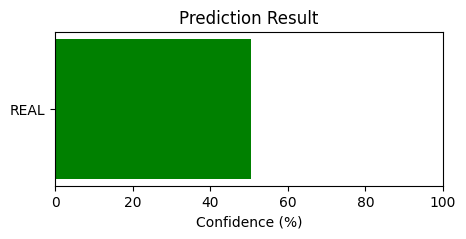

File: AI_A040-126.png
Predicted: REAL
Confidence: 46.72 %


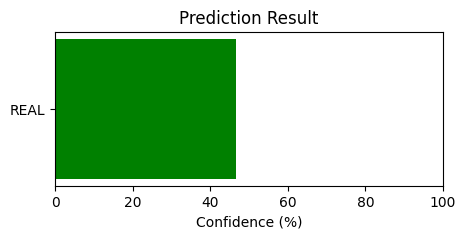

File: AI_A001-010.png
Predicted: AI GENERATED
Confidence: 57.77 %


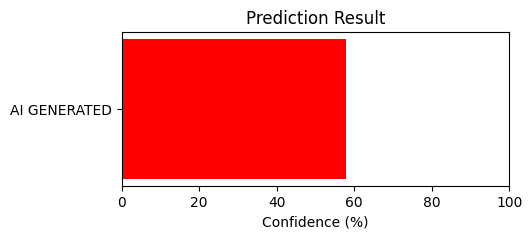

File: AI_A023-033.png
Predicted: REAL
Confidence: 54.39 %


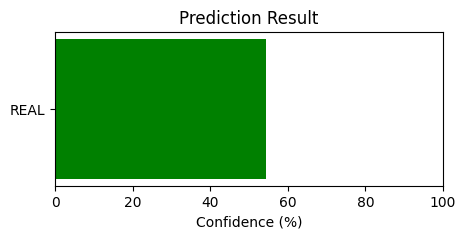

File: AI_A026-008.png
Predicted: REAL
Confidence: 61.23 %


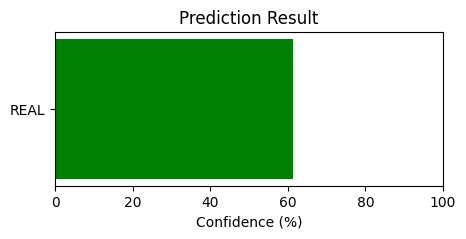

File: AI_A048-135.png
Predicted: REAL
Confidence: 62.15 %


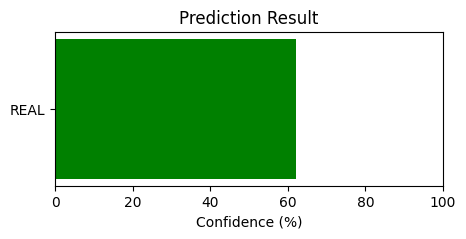

File: AI_B011-102.png
Predicted: REAL
Confidence: 57.31 %


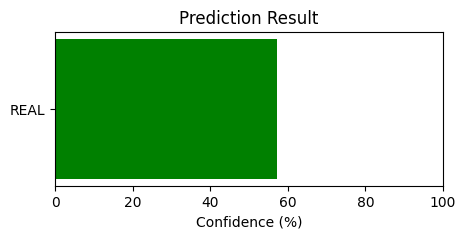

File: AI_A049-021.png
Predicted: REAL
Confidence: 46.83 %


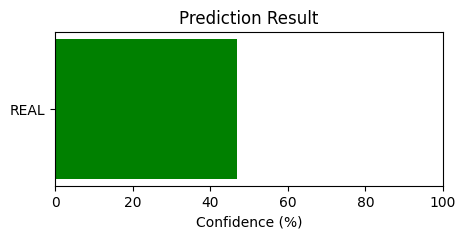

File: AI_A050-200.png
Predicted: AI GENERATED
Confidence: 97.79 %


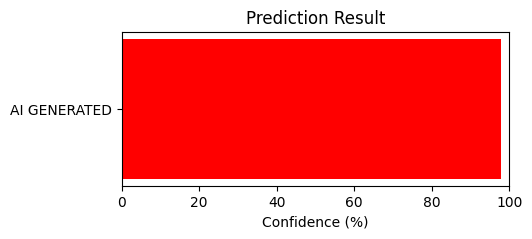

File: AI_A027-106.png
Predicted: REAL
Confidence: 59.5 %


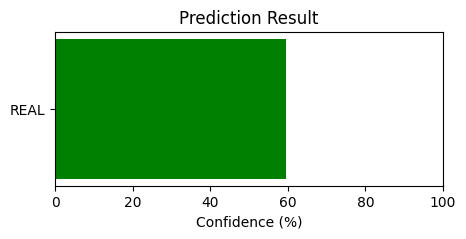

File: AI_B001-047.png
Predicted: REAL
Confidence: 57.85 %


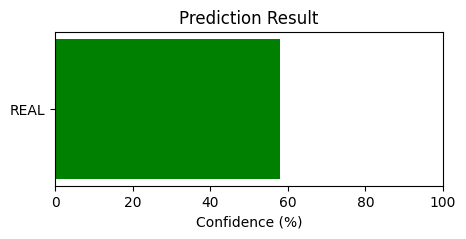

File: AI_A018-056.png
Predicted: REAL
Confidence: 49.54 %


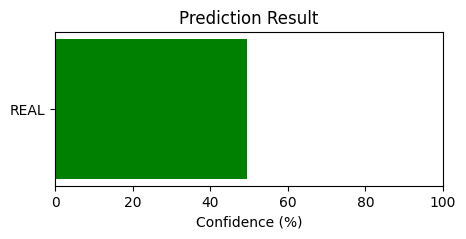

File: AI_A045-215.png
Predicted: REAL
Confidence: 55.91 %


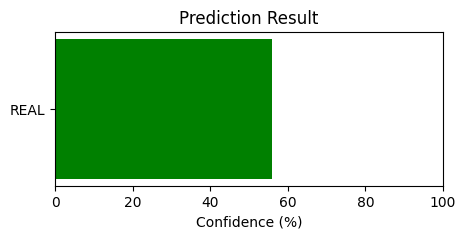

File: AI_A008-229.png
Predicted: AI GENERATED
Confidence: 50.28 %


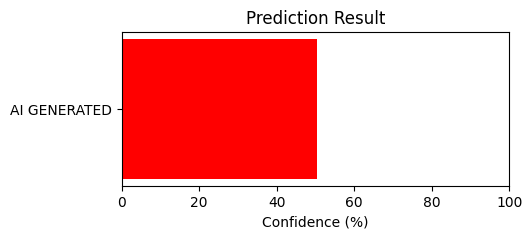

File: AI_B004-045.png
Predicted: AI GENERATED
Confidence: 60.87 %


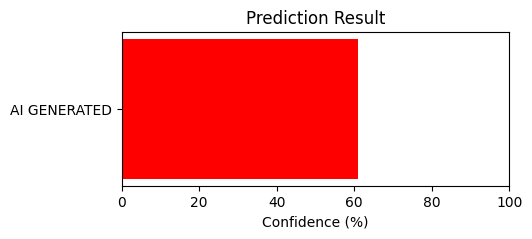

File: AI_B017-110.png
Predicted: REAL
Confidence: 52.8 %


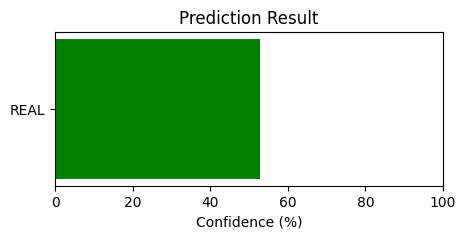

File: AI_A033-052.png
Predicted: AI GENERATED
Confidence: 57.27 %


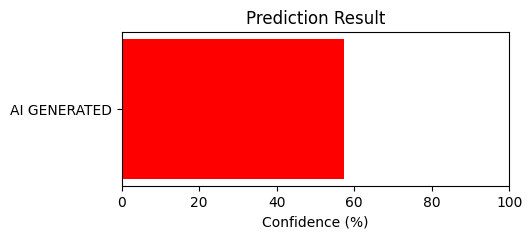

File: AI_A013-004.png
Predicted: AI GENERATED
Confidence: 51.26 %


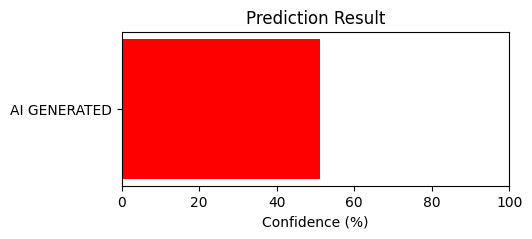

File: AI_A005-023.png
Predicted: REAL
Confidence: 58.47 %


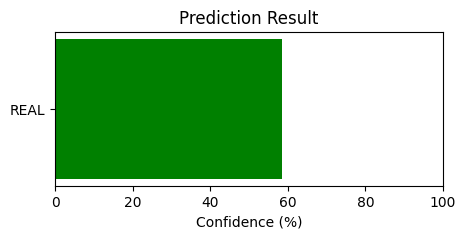

File: AI_B021-354.png
Predicted: REAL
Confidence: 57.95 %


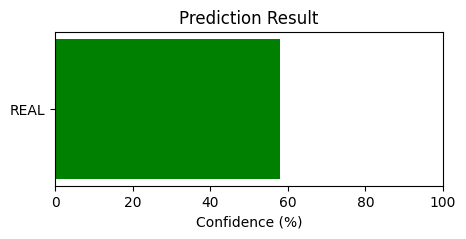

File: AI_A042-459.png
Predicted: AI GENERATED
Confidence: 72.39 %


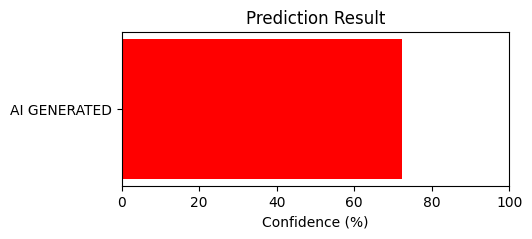

File: AI_A017-047.png
Predicted: AI GENERATED
Confidence: 41.7 %


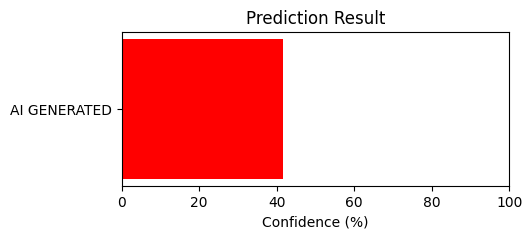

File: AI_B022-045.png
Predicted: AI GENERATED
Confidence: 49.89 %


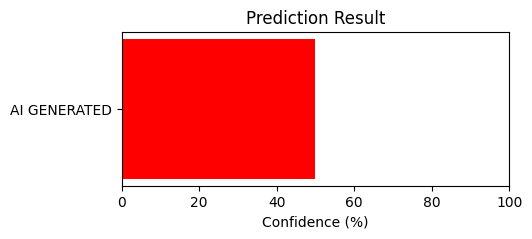

File: AI_B015-017.png
Predicted: REAL
Confidence: 55.38 %


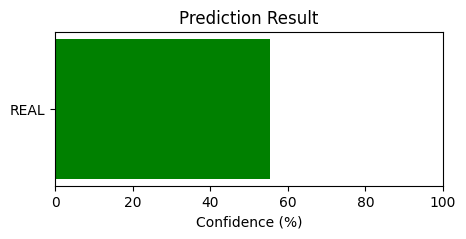

File: AI_B005-051.png
Predicted: REAL
Confidence: 55.73 %


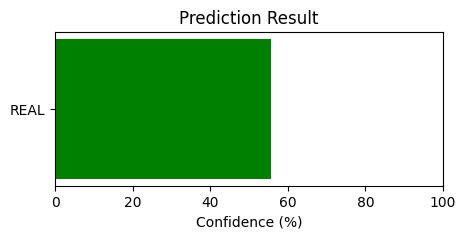

File: AI_A031-024.png
Predicted: REAL
Confidence: 66.04 %


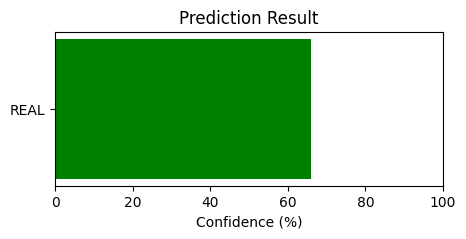

File: AI_B007-056.png
Predicted: REAL
Confidence: 39.44 %


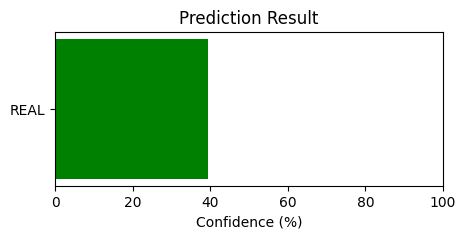

File: AI_C038-004.png
Predicted: AI GENERATED
Confidence: 77.98 %


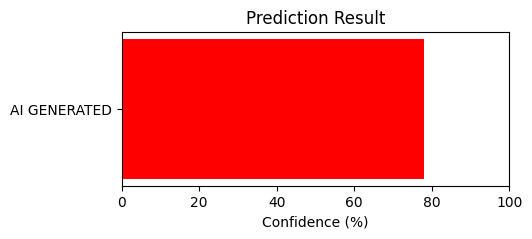

File: AI_A035-116.png
Predicted: AI GENERATED
Confidence: 67.76 %


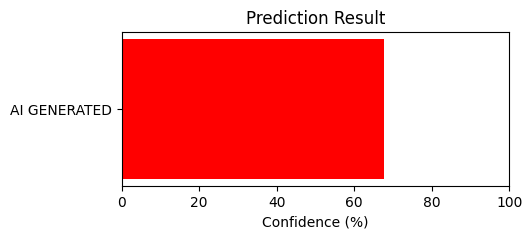

File: AI_B023-048.png
Predicted: REAL
Confidence: 55.4 %


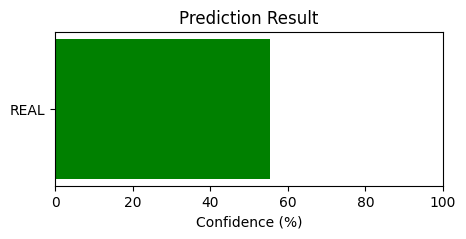

File: AI_B031-053.png
Predicted: REAL
Confidence: 93.46 %


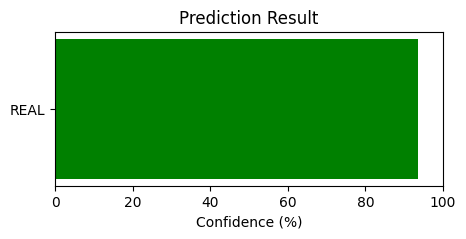

File: AI_B043-118.png
Predicted: EDITED
Confidence: 55.75 %


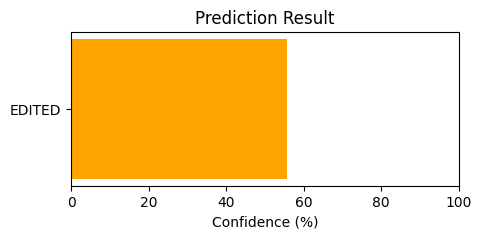

File: AI_C008-011.png
Predicted: REAL
Confidence: 53.54 %


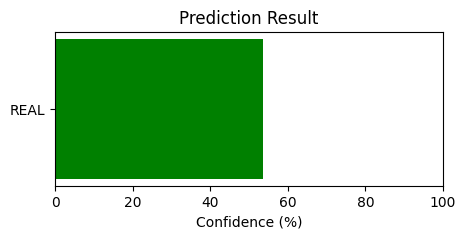

File: AI_C013-302.png
Predicted: REAL
Confidence: 57.6 %


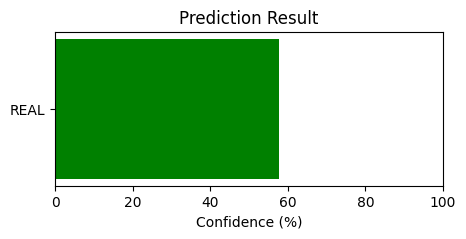

File: AI_C051-022.png
Predicted: REAL
Confidence: 57.9 %


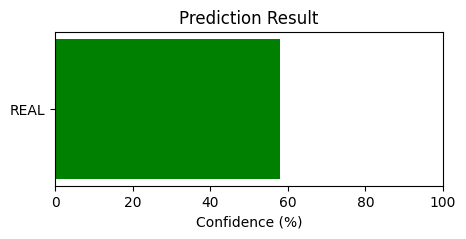

File: AI_C016-039.png
Predicted: AI GENERATED
Confidence: 61.28 %


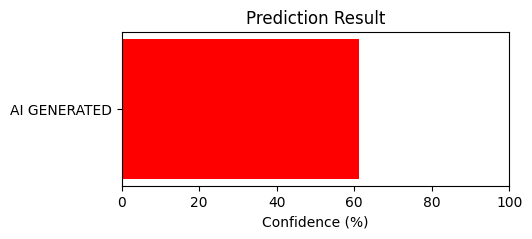

File: AI_C007-209.png
Predicted: AI GENERATED
Confidence: 70.36 %


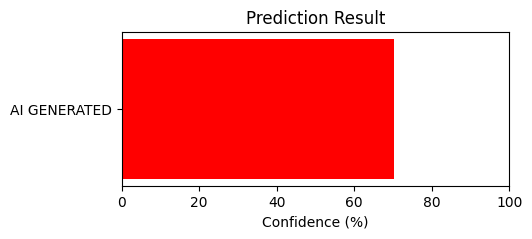

File: AI_C023-016.png
Predicted: REAL
Confidence: 57.57 %


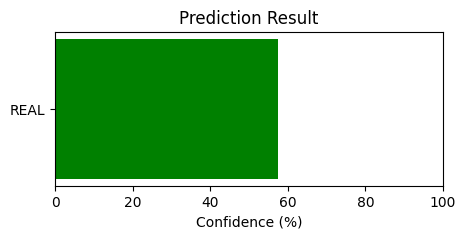

File: AI_C031-041.png
Predicted: AI GENERATED
Confidence: 62.0 %


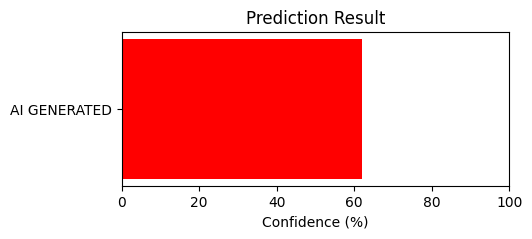

File: AI_C003-005.png
Predicted: REAL
Confidence: 67.31 %


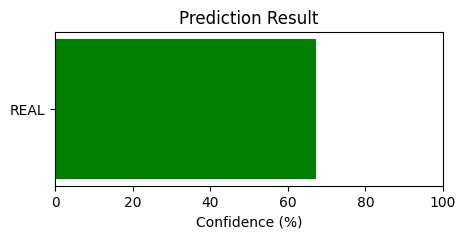

File: AI_C030-033.png
Predicted: AI GENERATED
Confidence: 85.46 %


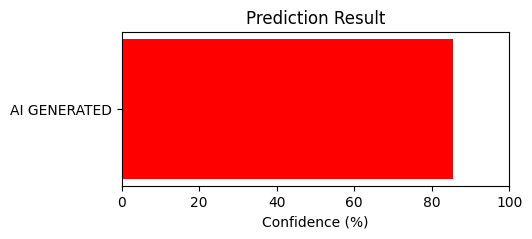

File: AI_C014-038.png
Predicted: REAL
Confidence: 42.39 %


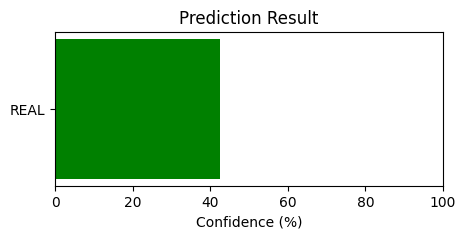

File: AI_B029-357.png
Predicted: AI GENERATED
Confidence: 75.06 %


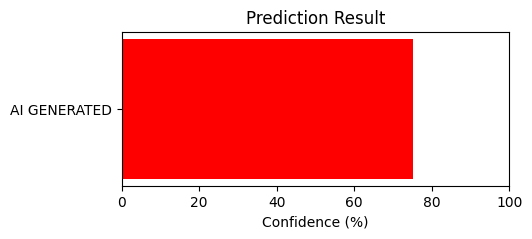

File: AI_C001-103.png
Predicted: AI GENERATED
Confidence: 89.66 %


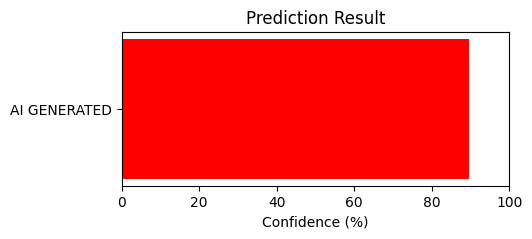

File: AI_C042-301.png
Predicted: REAL
Confidence: 60.15 %


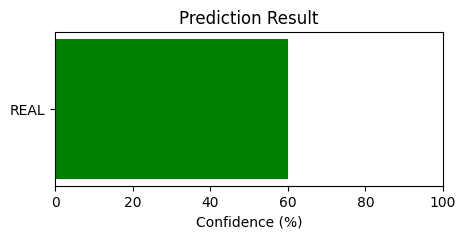

File: AI_C005-005.png
Predicted: REAL
Confidence: 57.46 %


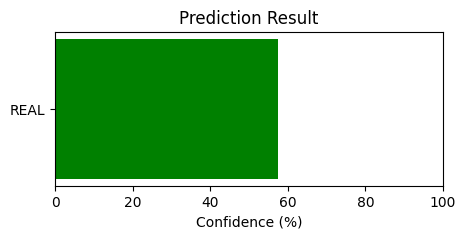

File: AI_B035-247.png
Predicted: REAL
Confidence: 57.43 %


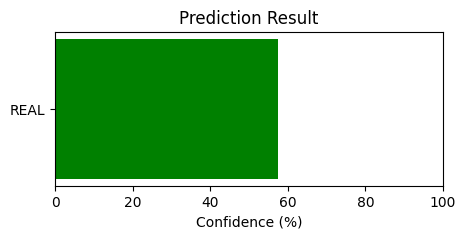

File: AI_B039-500.png
Predicted: REAL
Confidence: 50.03 %


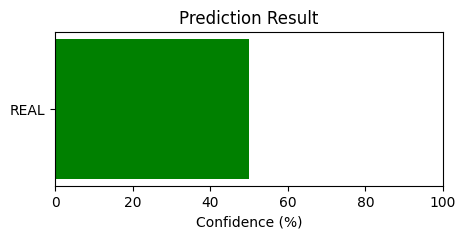

File: AI_C049-005.png
Predicted: REAL
Confidence: 59.57 %


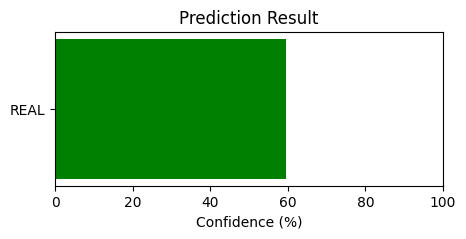

File: AI_C020-055.png
Predicted: REAL
Confidence: 58.39 %


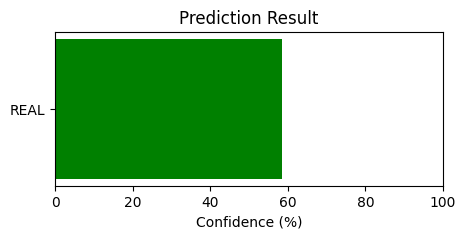

File: AI_C006-121.png
Predicted: REAL
Confidence: 52.06 %


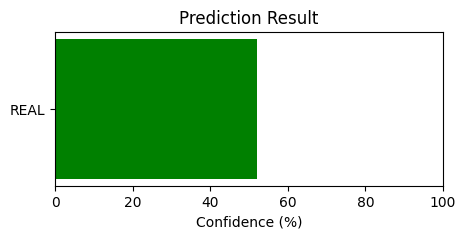

File: AI_B046-304.png
Predicted: REAL
Confidence: 53.63 %


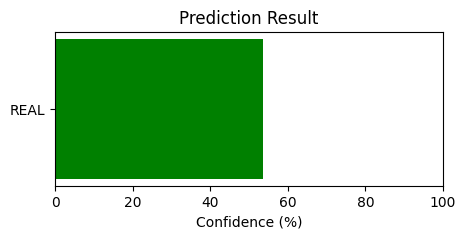

File: AI_C029-029.png
Predicted: REAL
Confidence: 48.25 %


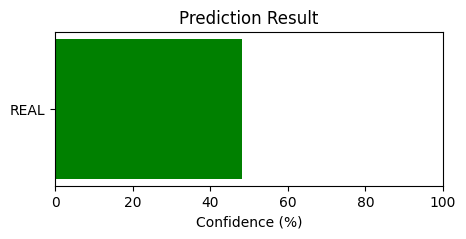

File: AI_C022-159.png
Predicted: AI GENERATED
Confidence: 51.82 %


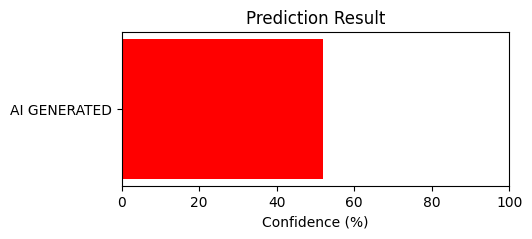

File: AI_C052-041.png
Predicted: REAL
Confidence: 59.38 %


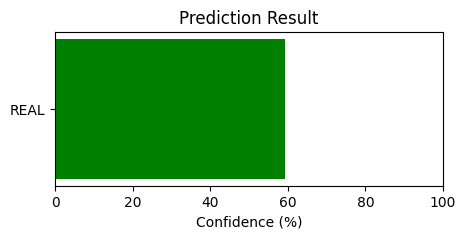

File: AI_B032-047.png
Predicted: AI GENERATED
Confidence: 46.89 %


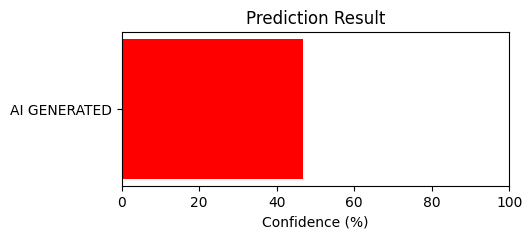

File: AI_C021-038.png
Predicted: AI GENERATED
Confidence: 52.97 %


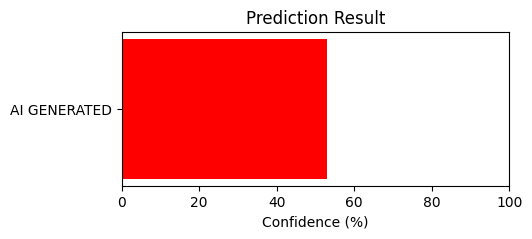

File: AI_B048-131.png
Predicted: REAL
Confidence: 43.71 %


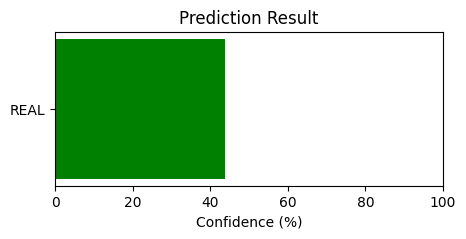

File: AI_C010-120.png
Predicted: REAL
Confidence: 58.79 %


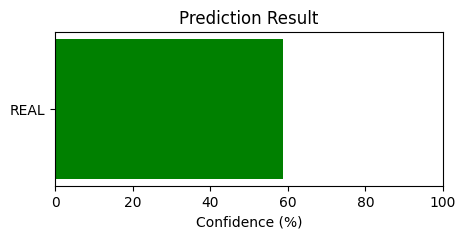

File: AI_B049-327.png
Predicted: REAL
Confidence: 53.97 %


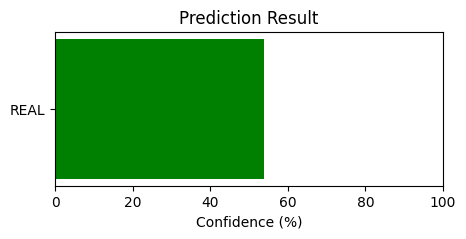

File: AI_C009-009.png
Predicted: REAL
Confidence: 66.48 %


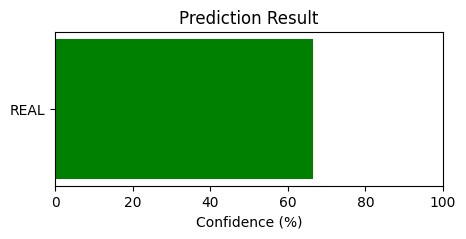

File: AI_C044-034.png
Predicted: REAL
Confidence: 57.73 %


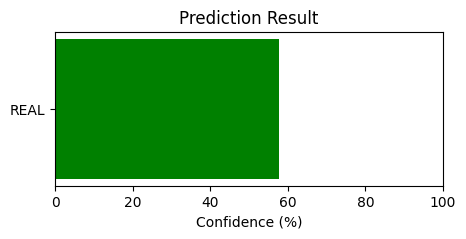

File: AI_C018-017.png
Predicted: REAL
Confidence: 47.38 %


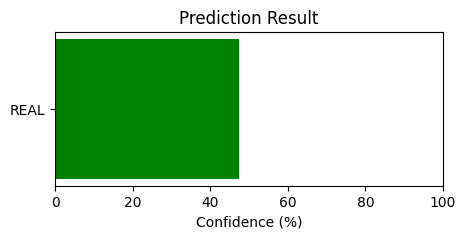

File: AI_B025-024.png
Predicted: REAL
Confidence: 66.85 %


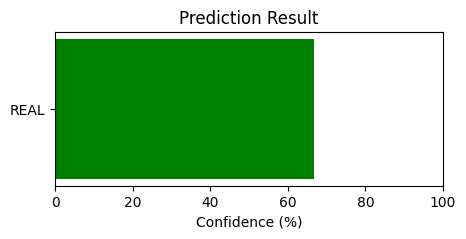

File: AI_C015-355.png
Predicted: REAL
Confidence: 58.66 %


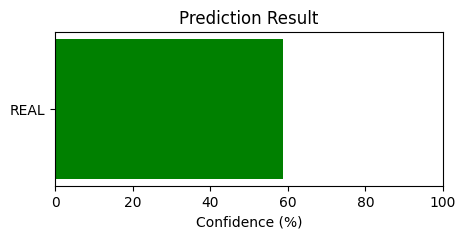

File: AI_B037-012.png
Predicted: AI GENERATED
Confidence: 47.9 %


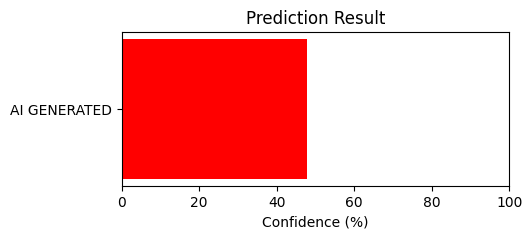

File: AI_B040-037.png
Predicted: AI GENERATED
Confidence: 35.25 %


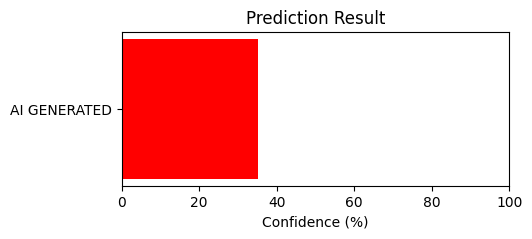

File: AI_B028-034.png
Predicted: REAL
Confidence: 54.55 %


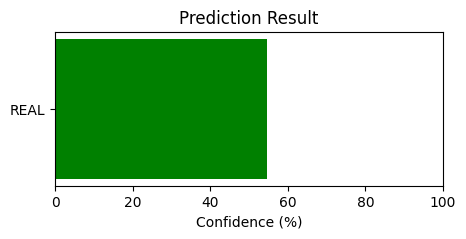

File: AI_C025-040.png
Predicted: REAL
Confidence: 56.64 %


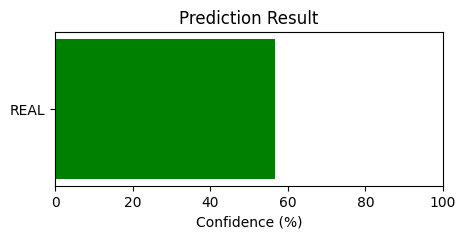

File: AI_B026-215.png
Predicted: AI GENERATED
Confidence: 44.18 %


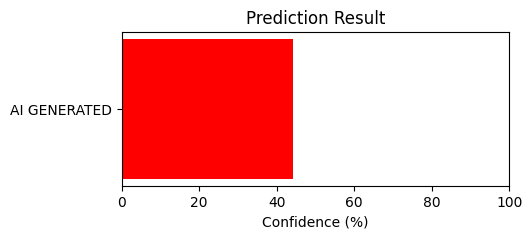

File: AI_C027-105.png
Predicted: REAL
Confidence: 48.03 %


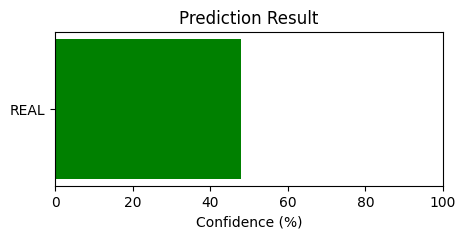

File: AI_C032-006.png
Predicted: AI GENERATED
Confidence: 56.84 %


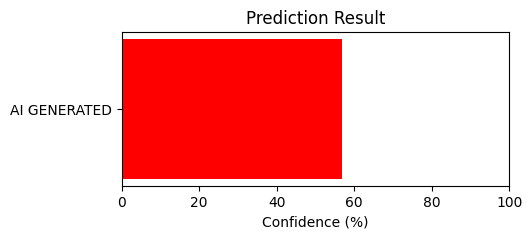

File: AI_C002-134.png
Predicted: REAL
Confidence: 73.2 %


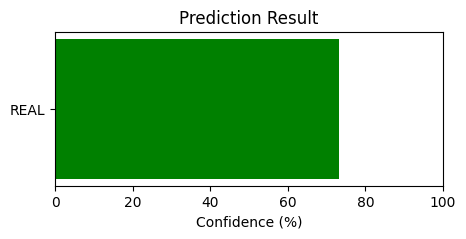

File: AI_C028-106.png
Predicted: REAL
Confidence: 70.65 %


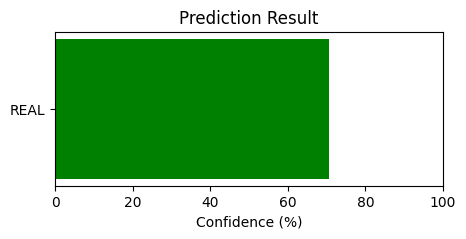

File: AI_B044-136.png
Predicted: AI GENERATED
Confidence: 97.79 %


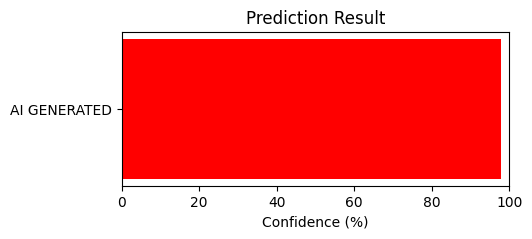

File: AI_D019-008.png
Predicted: REAL
Confidence: 76.18 %


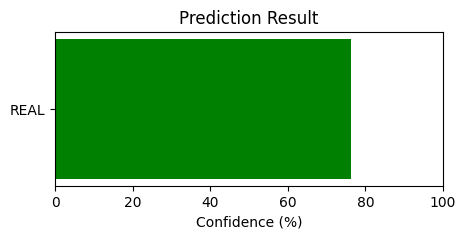

File: AI_D046-053.png
Predicted: REAL
Confidence: 83.82 %


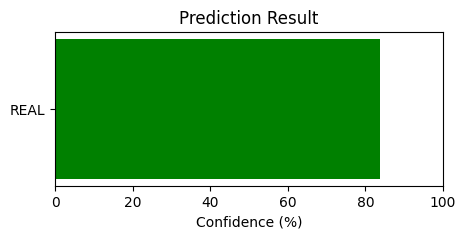

File: AI_E013-015.png
Predicted: REAL
Confidence: 82.78 %


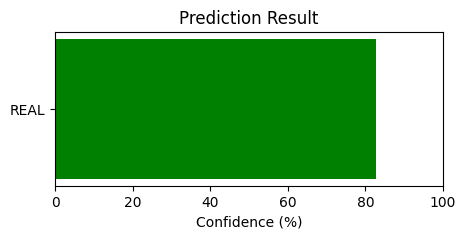

File: AI_E030-036.png
Predicted: REAL
Confidence: 63.73 %


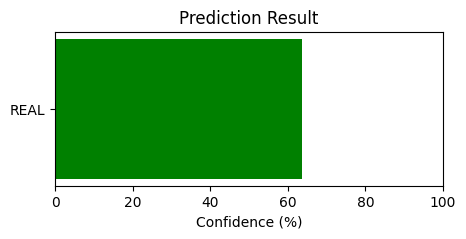

File: AI_D022-114.png
Predicted: REAL
Confidence: 71.29 %


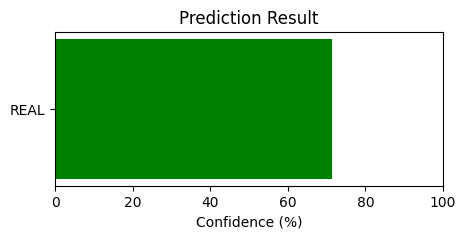

File: AI_E019-027.png
Predicted: REAL
Confidence: 71.82 %


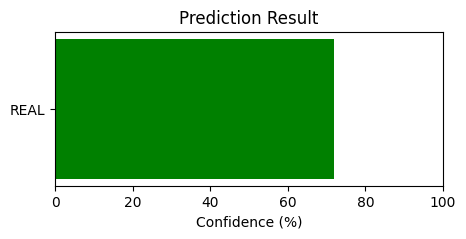

File: AI_D001-049.png
Predicted: REAL
Confidence: 43.92 %


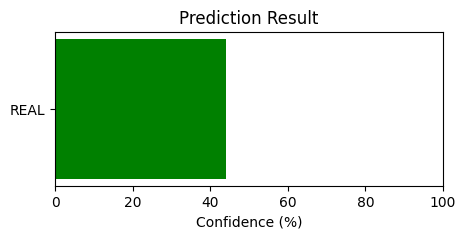

File: AI_D006-331.png
Predicted: REAL
Confidence: 61.97 %


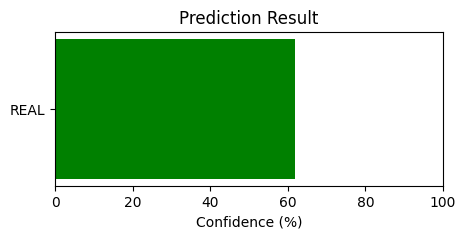

File: AI_D010-142.png
Predicted: REAL
Confidence: 71.44 %


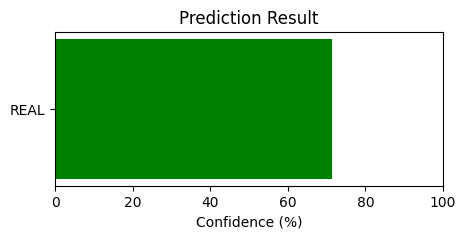

File: AI_E031-002.png
Predicted: REAL
Confidence: 66.1 %


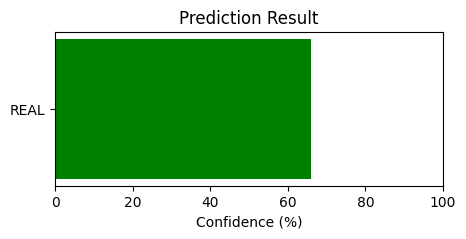

File: AI_D007-030.png
Predicted: REAL
Confidence: 79.08 %


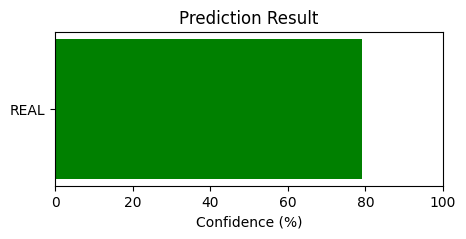

File: AI_D027-036.png
Predicted: REAL
Confidence: 81.73 %


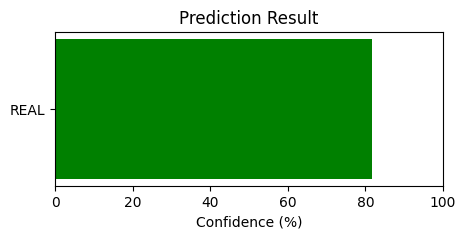

File: AI_D013-029.png
Predicted: REAL
Confidence: 74.34 %


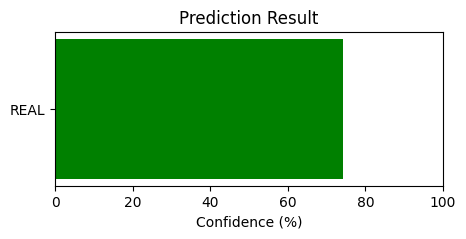

File: AI_D002-128.png
Predicted: REAL
Confidence: 96.27 %


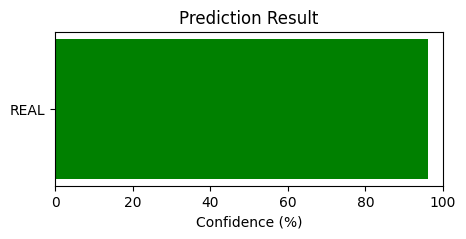

File: AI_D031-112.png
Predicted: EDITED
Confidence: 55.8 %


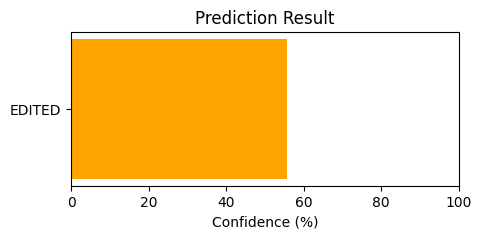

File: AI_D026-037.png
Predicted: REAL
Confidence: 76.94 %


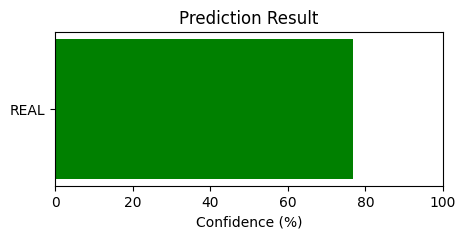

File: AI_D045-215.png
Predicted: EDITED
Confidence: 85.2 %


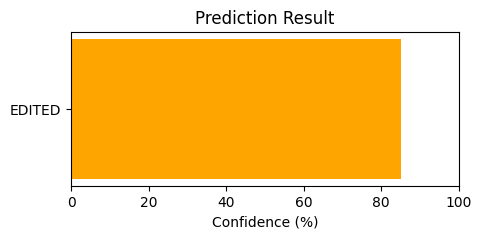

File: AI_D017-047.png
Predicted: AI GENERATED
Confidence: 97.79 %


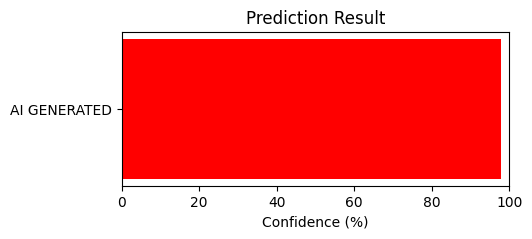

File: AI_E021-002.png
Predicted: REAL
Confidence: 76.55 %


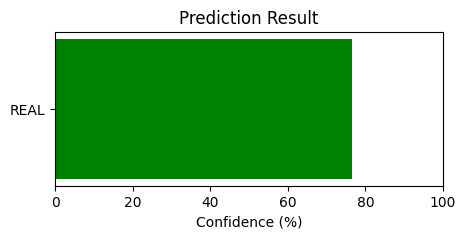

File: AI_E002-010.png
Predicted: EDITED
Confidence: 52.72 %


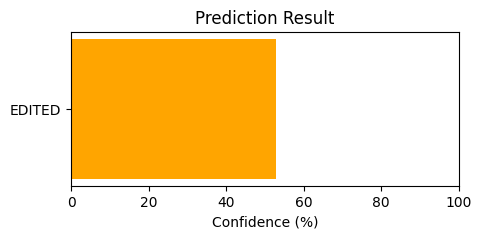

File: AI_D004-015.png
Predicted: REAL
Confidence: 89.58 %


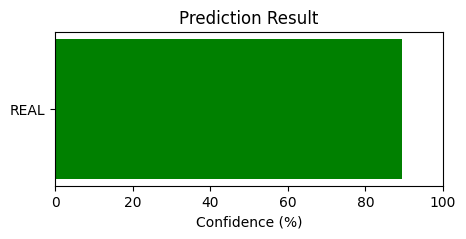

File: AI_D016-121.png
Predicted: EDITED
Confidence: 49.09 %


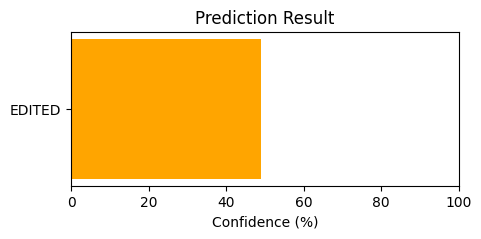

File: AI_D021-040.png
Predicted: REAL
Confidence: 50.47 %


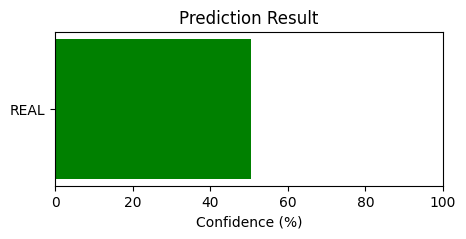

File: AI_D012-025.png
Predicted: REAL
Confidence: 95.28 %


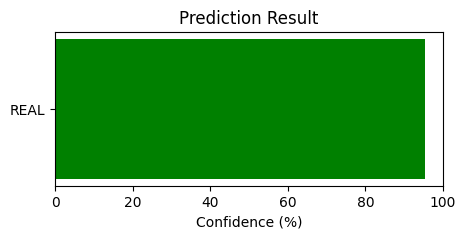

File: AI_E032-020.png
Predicted: REAL
Confidence: 64.71 %


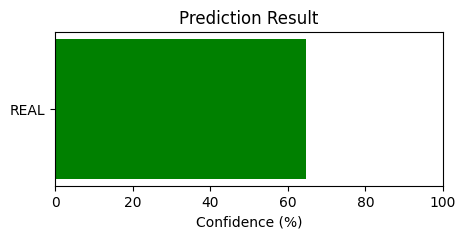

File: AI_D048-025.png
Predicted: REAL
Confidence: 61.27 %


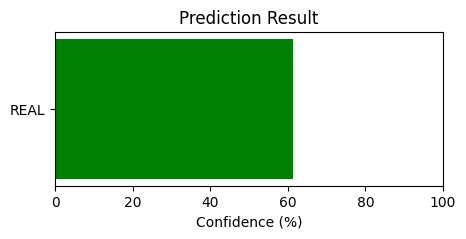

File: AI_E029-004.png
Predicted: REAL
Confidence: 66.43 %


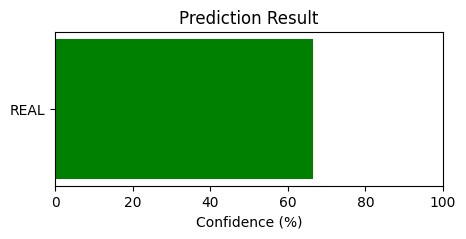

File: AI_D020-114.png
Predicted: REAL
Confidence: 79.55 %


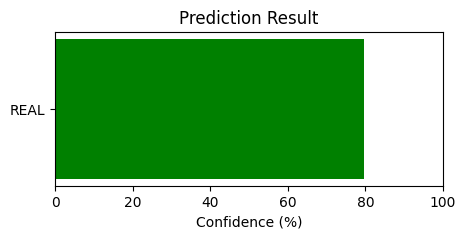

File: AI_E027-003.png
Predicted: REAL
Confidence: 60.89 %


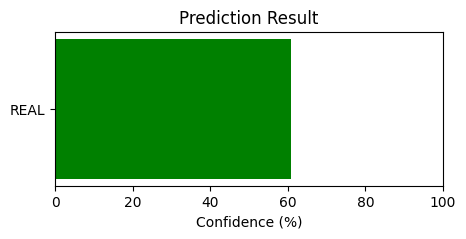

File: AI_E004-005.png
Predicted: REAL
Confidence: 60.5 %


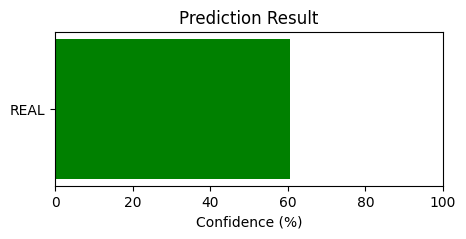

File: AI_E028-016.png
Predicted: REAL
Confidence: 79.51 %


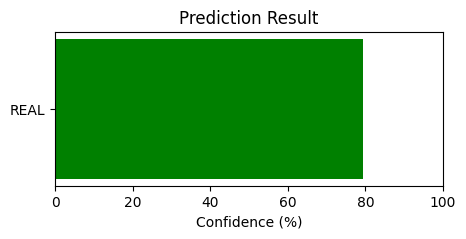

File: AI_E020-022.png
Predicted: REAL
Confidence: 60.46 %


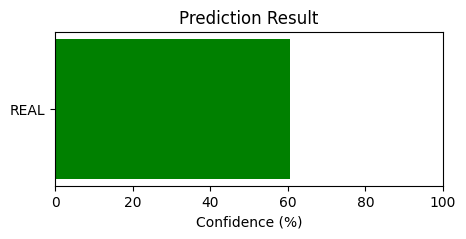

File: AI_D009-033.png
Predicted: EDITED
Confidence: 97.42 %


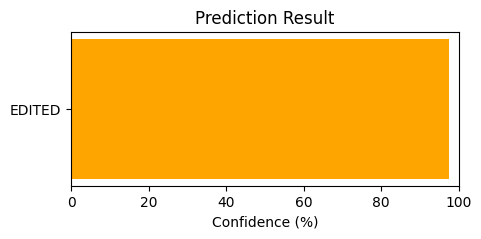

File: AI_E012-009.png
Predicted: REAL
Confidence: 62.72 %


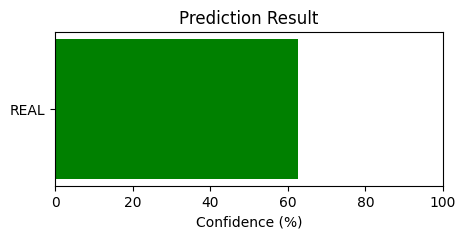

File: AI_E010-008.png
Predicted: REAL
Confidence: 60.72 %


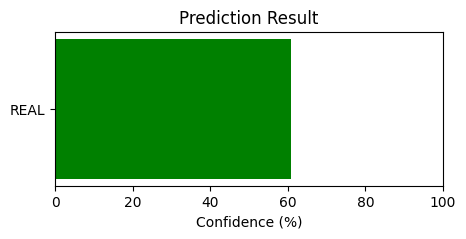

File: AI_E011-009.png
Predicted: REAL
Confidence: 53.65 %


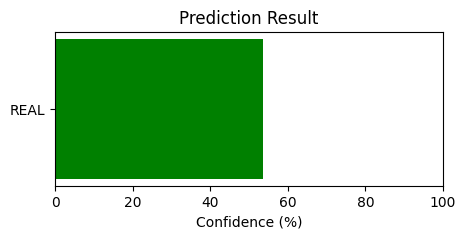

File: AI_F026-002.png
Predicted: REAL
Confidence: 69.34 %


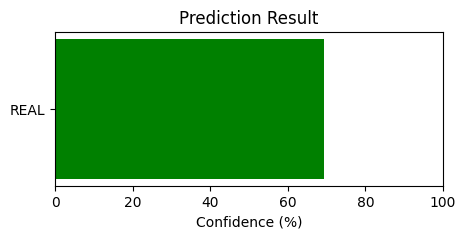

File: AI_E146-014.png
Predicted: REAL
Confidence: 63.74 %


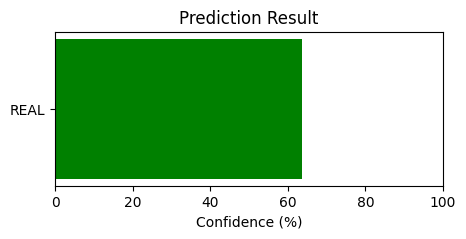

File: AI_G008-253.png
Predicted: REAL
Confidence: 86.91 %


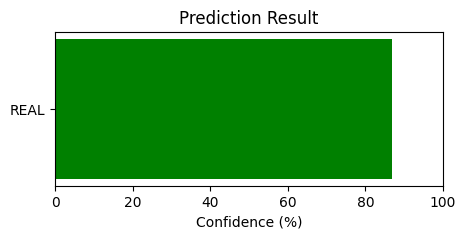

File: AI_E145-014.png
Predicted: REAL
Confidence: 61.38 %


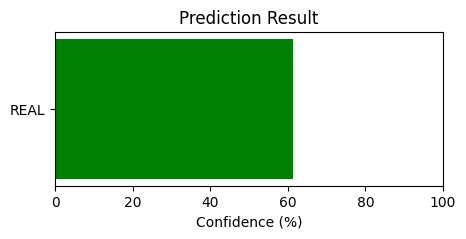

File: AI_E035-002.png
Predicted: REAL
Confidence: 66.52 %


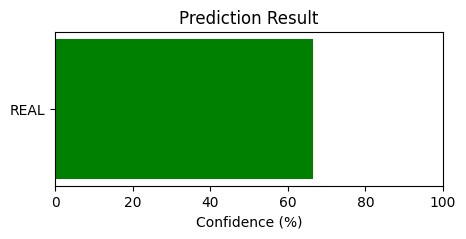

File: AI_E039-002.png
Predicted: EDITED
Confidence: 78.55 %


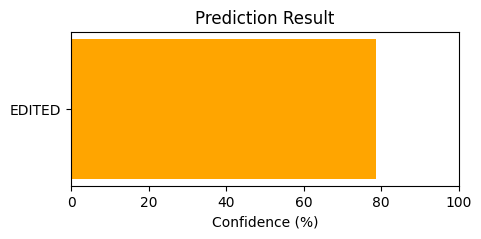

File: AI_E075-004.png
Predicted: REAL
Confidence: 73.55 %


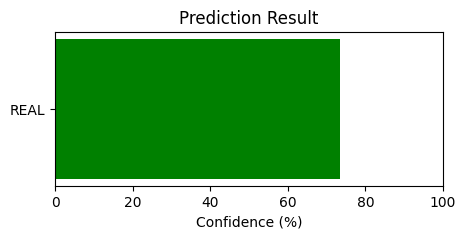

File: AI_F014-310.png
Predicted: EDITED
Confidence: 83.85 %


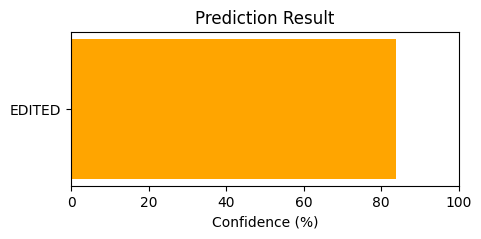

File: AI_F048-048.png
Predicted: REAL
Confidence: 83.75 %


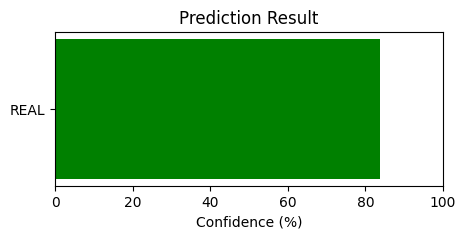

File: AI_G020-119.png
Predicted: REAL
Confidence: 80.45 %


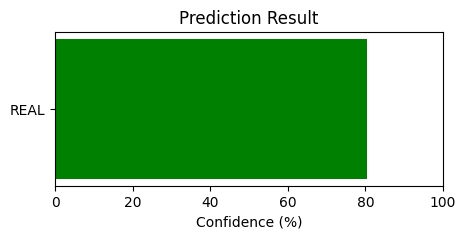

File: AI_F030-024.png
Predicted: REAL
Confidence: 77.29 %


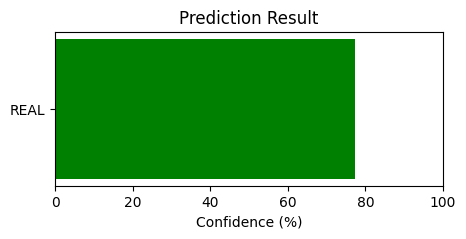

File: AI_G010-028.png
Predicted: REAL
Confidence: 92.63 %


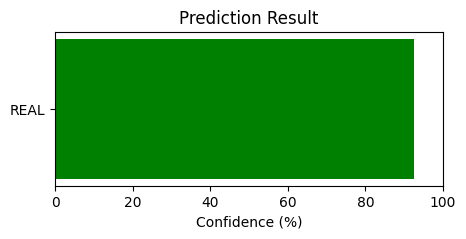

File: AI_G005-028.png
Predicted: REAL
Confidence: 84.29 %


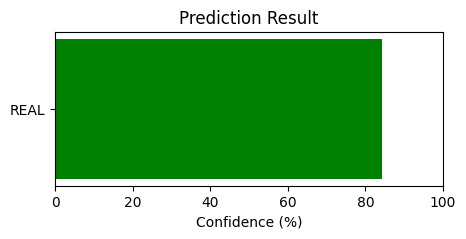

File: AI_F019-037.png
Predicted: REAL
Confidence: 53.09 %


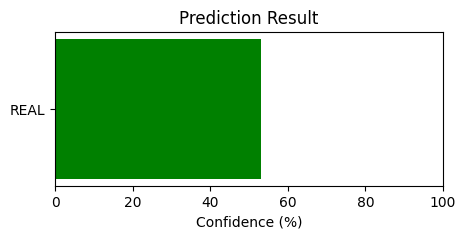

File: AI_F022-137.png
Predicted: REAL
Confidence: 85.92 %


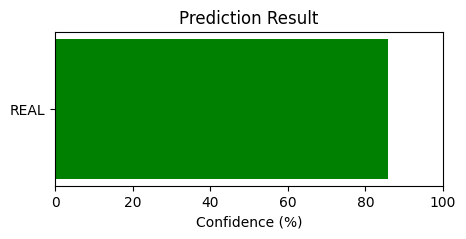

File: AI_F054-005.png
Predicted: EDITED
Confidence: 72.68 %


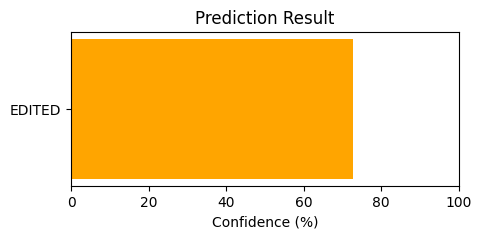

File: AI_F033-430.png
Predicted: REAL
Confidence: 72.17 %


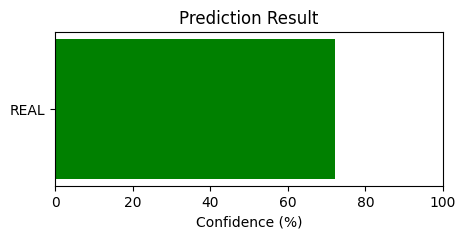

File: AI_G019-009.png
Predicted: EDITED
Confidence: 86.6 %


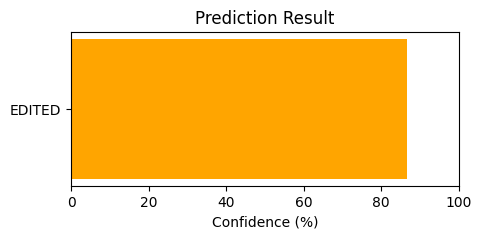

File: AI_G017-013.png
Predicted: REAL
Confidence: 77.38 %


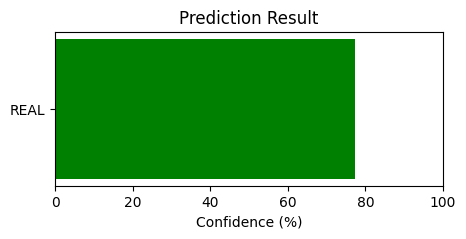

File: AI_F004-022.png
Predicted: REAL
Confidence: 61.03 %


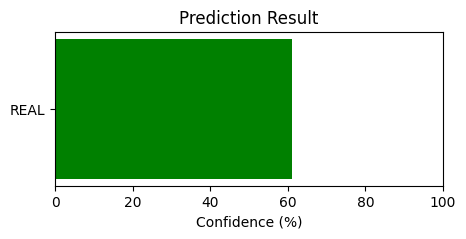

File: AI_F028-009.png
Predicted: REAL
Confidence: 80.31 %


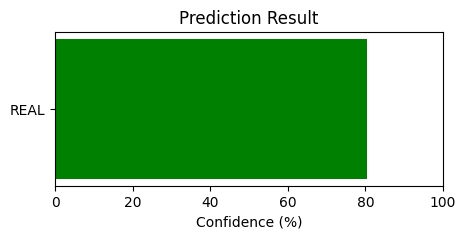

File: AI_E034-008.png
Predicted: EDITED
Confidence: 52.15 %


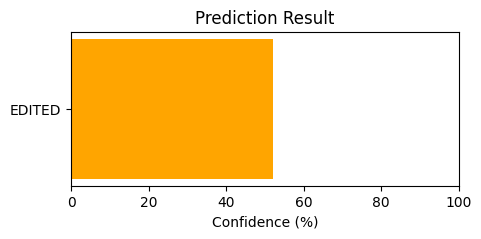

File: AI_F017-021.png
Predicted: REAL
Confidence: 65.15 %


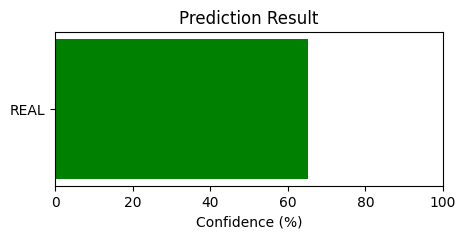

File: AI_F050-056.png
Predicted: REAL
Confidence: 73.43 %


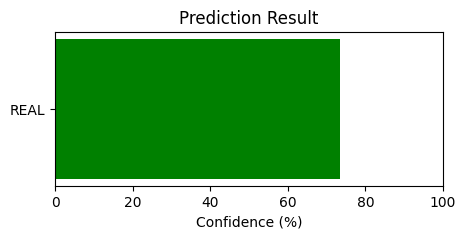

File: AI_F018-029.png
Predicted: REAL
Confidence: 96.5 %


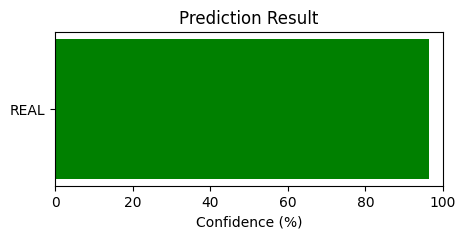

File: AI_F025-045.png
Predicted: REAL
Confidence: 92.14 %


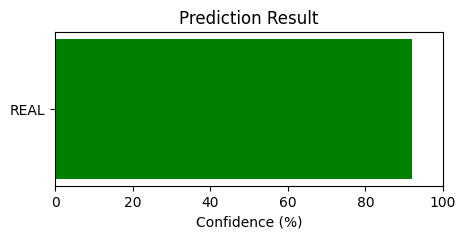

File: AI_G016-023.png
Predicted: REAL
Confidence: 59.54 %


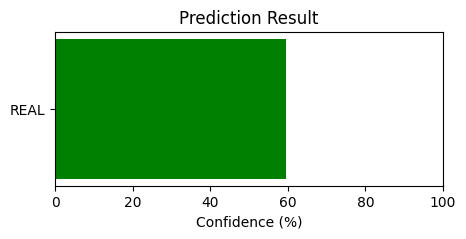

File: AI_F013-030.png
Predicted: REAL
Confidence: 69.4 %


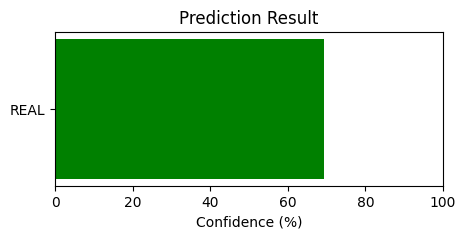

File: AI_G001-101.png
Predicted: EDITED
Confidence: 48.44 %


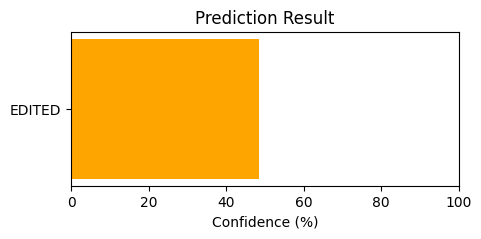

File: AI_F031-045.png
Predicted: EDITED
Confidence: 89.26 %


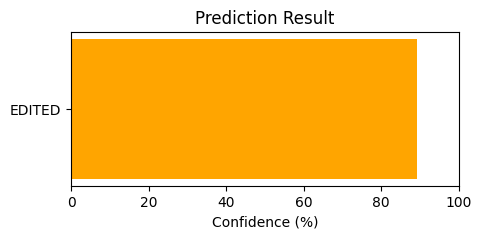

File: AI_G009-227.png
Predicted: REAL
Confidence: 90.68 %


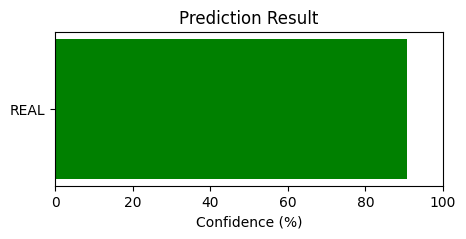

File: AI_F039-023.png
Predicted: REAL
Confidence: 65.35 %


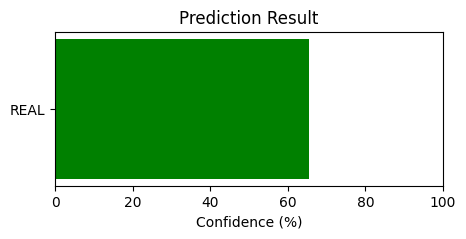

File: AI_F036-121.png
Predicted: REAL
Confidence: 68.96 %


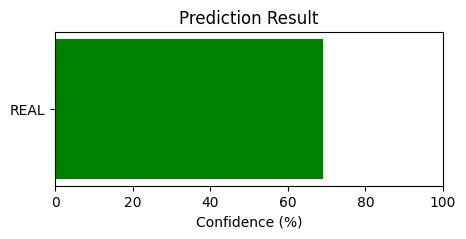

File: AI_G015-110.png
Predicted: REAL
Confidence: 79.05 %


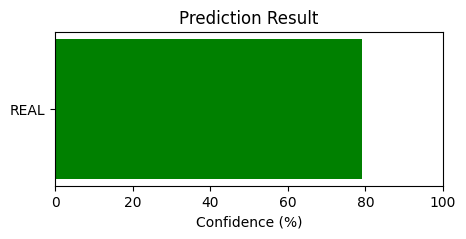

File: AI_E127-113.png
Predicted: REAL
Confidence: 71.99 %


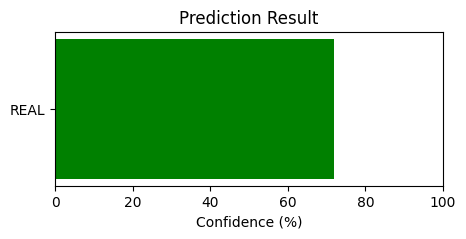

File: AI_F023-012.png
Predicted: REAL
Confidence: 64.94 %


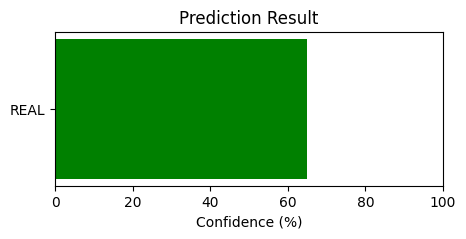

File: AI_F011-109.png
Predicted: REAL
Confidence: 92.83 %


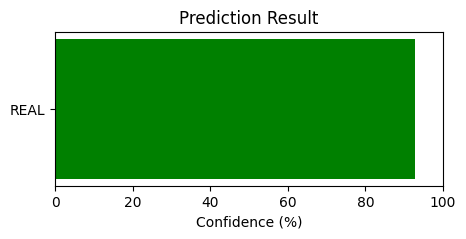

File: AI_F041-019.png
Predicted: REAL
Confidence: 83.57 %


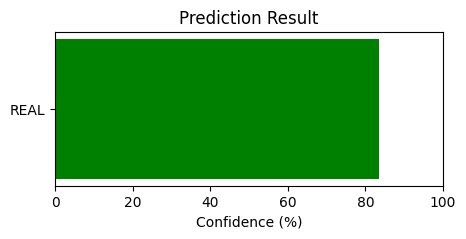

File: AI_F020-208.png
Predicted: EDITED
Confidence: 66.28 %


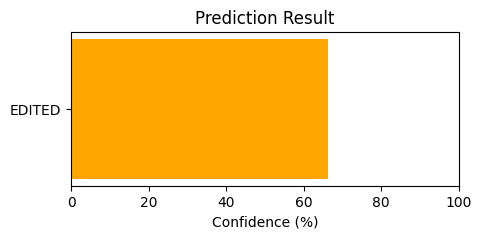

File: AI_H018-037.png
Predicted: REAL
Confidence: 63.99 %


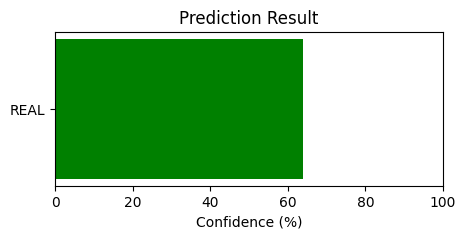

File: AI_H001-042.png
Predicted: EDITED
Confidence: 55.27 %


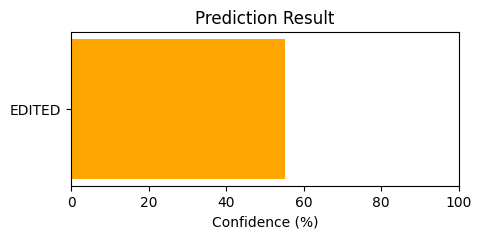

File: AI_H017-011.png
Predicted: REAL
Confidence: 67.86 %


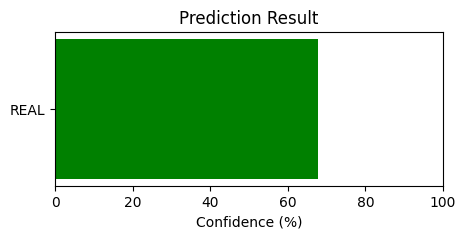

File: AI_H034-044.png
Predicted: REAL
Confidence: 64.63 %


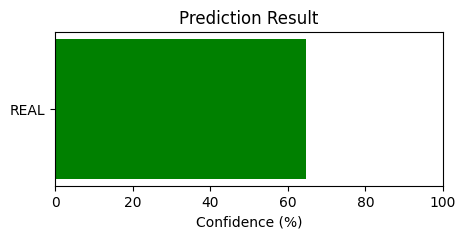

File: AI_H014-005.png
Predicted: REAL
Confidence: 67.31 %


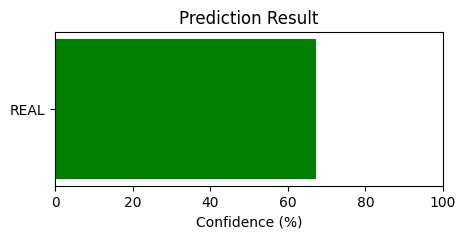

File: AI_H040-008.png
Predicted: REAL
Confidence: 96.6 %


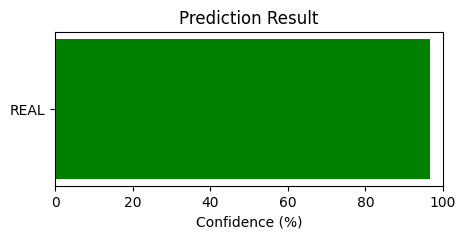

File: AI_H024-023.png
Predicted: REAL
Confidence: 76.3 %


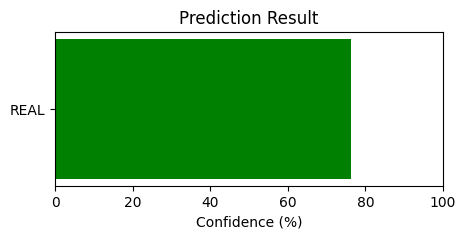

File: AI_H043-140.png
Predicted: REAL
Confidence: 74.23 %


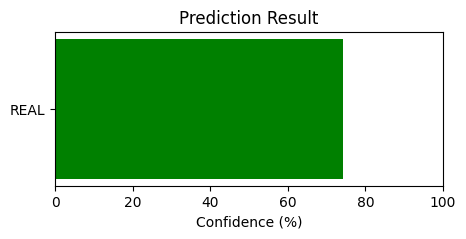

File: AI_H010-113.png
Predicted: EDITED
Confidence: 72.76 %


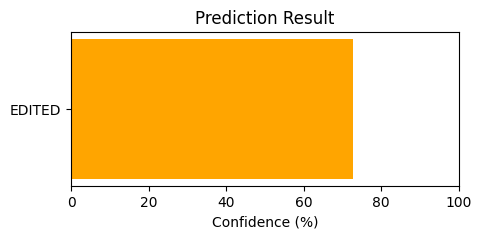

File: AI_H012-020.png
Predicted: REAL
Confidence: 64.05 %


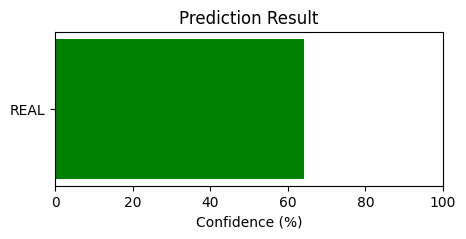

File: AI_H008-146.png
Predicted: REAL
Confidence: 65.42 %


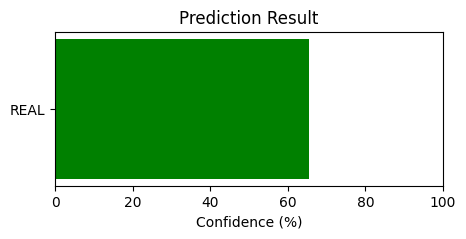

File: AI_H011-037.png
Predicted: REAL
Confidence: 67.93 %


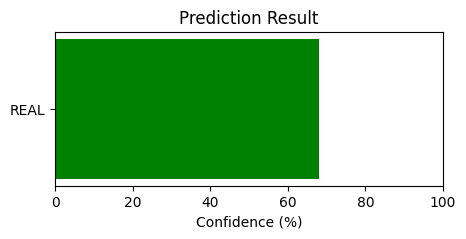

File: AI_H015-113.png
Predicted: REAL
Confidence: 56.24 %


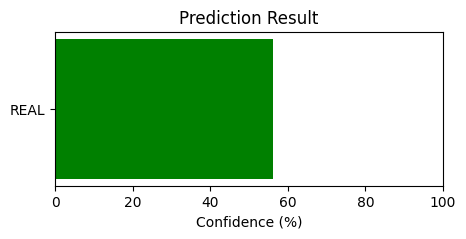

File: AI_H026-018.png
Predicted: REAL
Confidence: 58.53 %


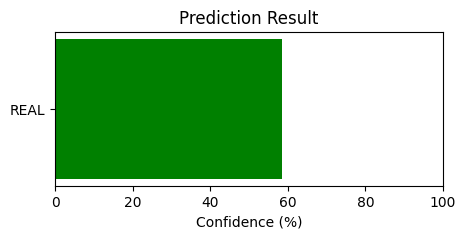

File: AI_G049-036.png
Predicted: REAL
Confidence: 69.52 %


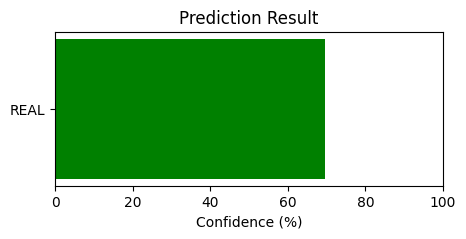

File: AI_H042-138.png
Predicted: AI GENERATED
Confidence: 97.79 %


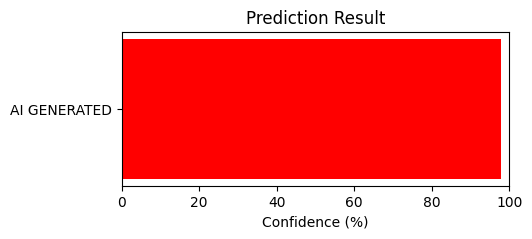

File: AI_H048-206.png
Predicted: REAL
Confidence: 92.92 %


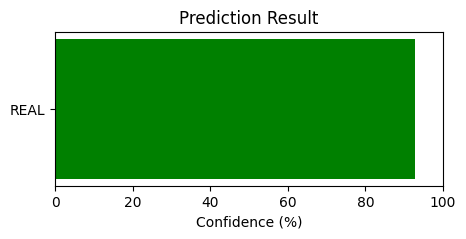

File: AI_H022-144.png
Predicted: EDITED
Confidence: 55.89 %


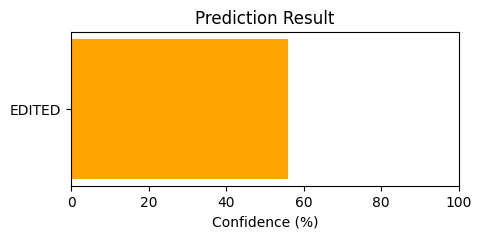

File: AI_H033-019.png
Predicted: REAL
Confidence: 80.69 %


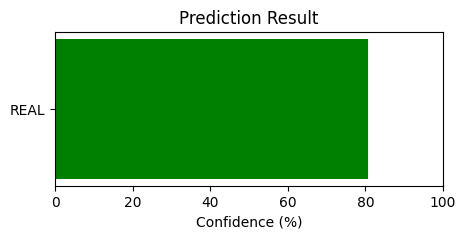

File: AI_G042-129.png
Predicted: REAL
Confidence: 72.08 %


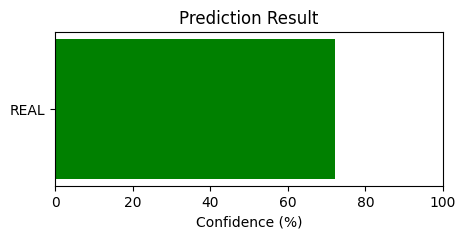

File: AI_G021-111.png
Predicted: REAL
Confidence: 72.87 %


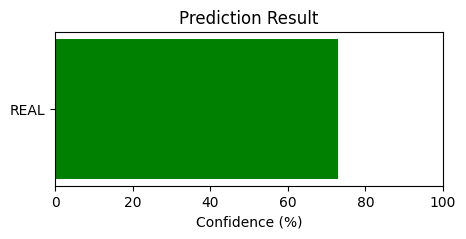

File: AI_G048-008.png
Predicted: EDITED
Confidence: 51.68 %


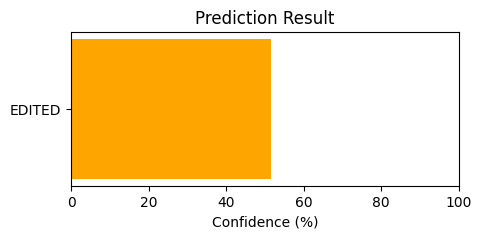

File: AI_H027-015.png
Predicted: REAL
Confidence: 81.42 %


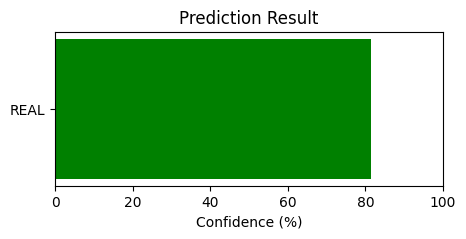

File: AI_H028-123.png
Predicted: REAL
Confidence: 75.26 %


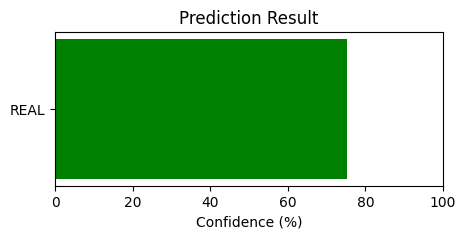

File: AI_H031-028.png
Predicted: EDITED
Confidence: 54.28 %


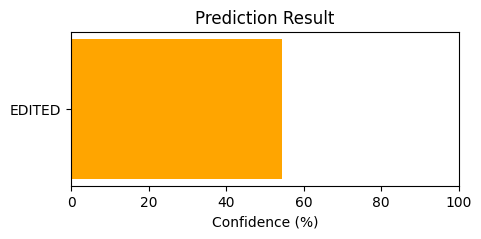

File: AI_H035-013.png
Predicted: REAL
Confidence: 67.64 %


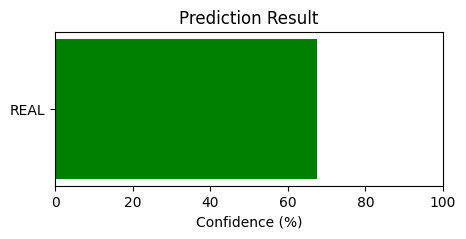

File: AI_G044-612.png
Predicted: REAL
Confidence: 81.82 %


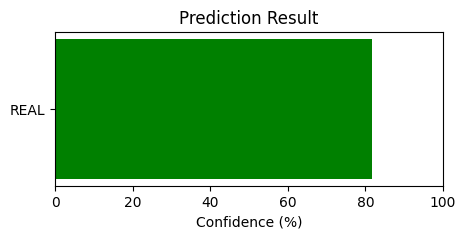

File: AI_G040-445.png
Predicted: REAL
Confidence: 55.71 %


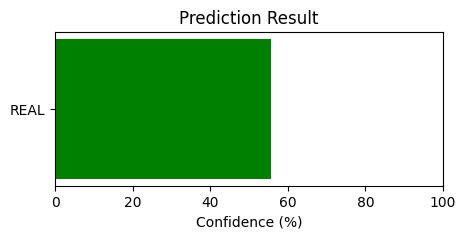

File: AI_G031-007.png
Predicted: EDITED
Confidence: 81.87 %


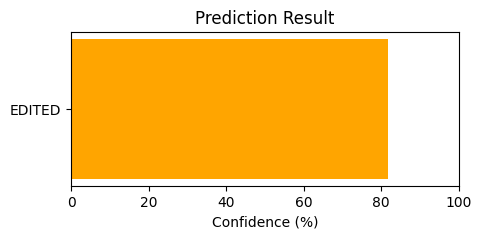

File: AI_G029-038.png
Predicted: EDITED
Confidence: 53.69 %


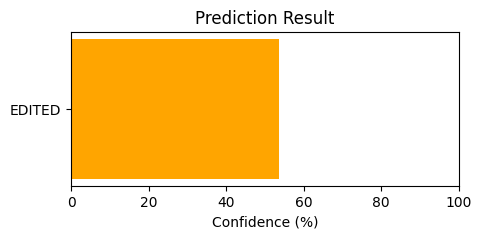

File: AI_G052-133.png
Predicted: REAL
Confidence: 68.44 %


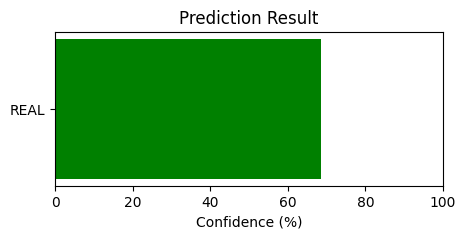

File: AI_H036-022.png
Predicted: REAL
Confidence: 91.51 %


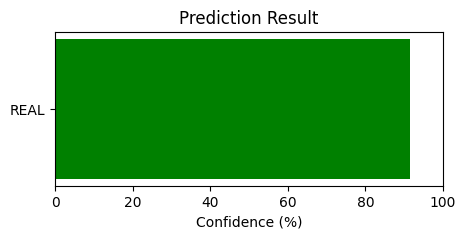

File: AI_H023-301.png
Predicted: REAL
Confidence: 93.77 %


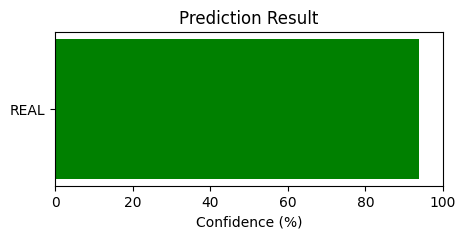

File: AI_H049-208.png
Predicted: REAL
Confidence: 80.08 %


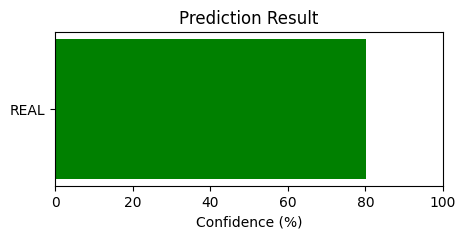

File: AI_H020-018.png
Predicted: REAL
Confidence: 63.59 %


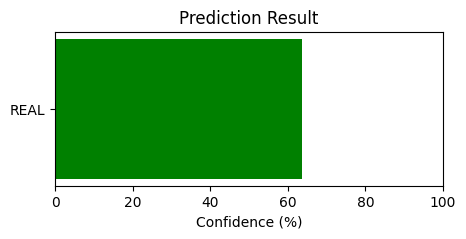

File: AI_H013-115.png
Predicted: REAL
Confidence: 73.62 %


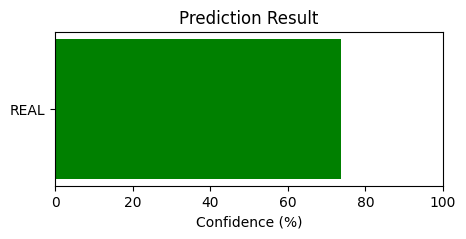

In [ ]:
for true_class, folder in folders.items():

    print("\n==============================")
    print("CATEGORY:", true_class)
    print("==============================\n")

    images = os.listdir(folder)

    for img_name in images:

        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        label, confidence = predict_image(img)

        print("File:", img_name)
        print("Predicted:", label)
        print("Confidence:", round(confidence, 2), "%")

        show_bar(label, confidence)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

In [ ]:
test_path = "/content/drive/MyDrive/image-authentication-project/data"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(
    rescale=1./255
)


test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 567 images belonging to 3 classes.


In [ ]:
print(test_generator.class_indices)

{'actual': 0, 'ai_generated': 1, 'edited': 2}


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(
    rescale=1./255
)


test_generator = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/image-authentication-project/data",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 567 images belonging to 3 classes.


In [ ]:
print(test_generator.class_indices)

{'actual': 0, 'ai_generated': 1, 'edited': 2}


In [ ]:
predictions = model.predict(test_generator)

18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step


In [ ]:
import numpy as np

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

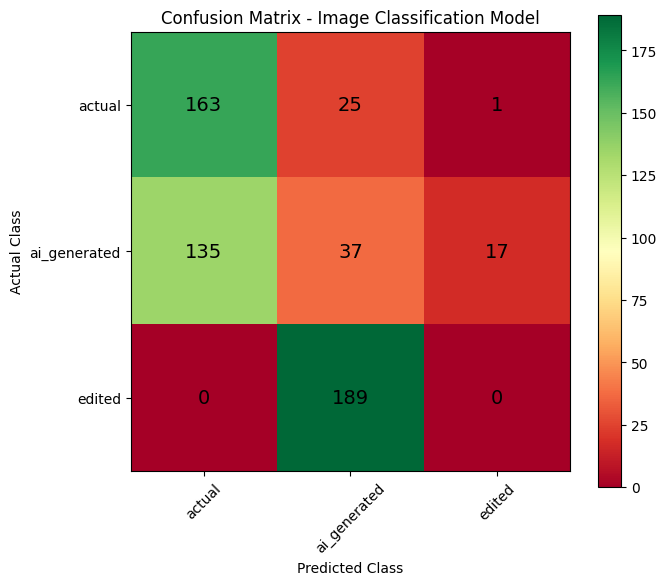

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix


class_names = list(test_generator.class_indices.keys())


cm = confusion_matrix(
    y_true,
    y_pred
)


fig, ax = plt.subplots(figsize=(7,6))


# Display confusion matrix
im = ax.imshow(
    cm,
    cmap="RdYlGn"
)


# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=14
        )


# Labels
ax.set_xticks(
    np.arange(len(class_names))
)

ax.set_yticks(
    np.arange(len(class_names))
)


ax.set_xticklabels(
    class_names,
    rotation=45
)

ax.set_yticklabels(
    class_names
)


ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "Actual Class"
)


ax.set_title(
    "Confusion Matrix - Image Classification Model"
)


plt.colorbar(im)

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score


accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy*100,"%")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Accuracy: 35.273368606701936 %
              precision    recall  f1-score   support

      actual       0.55      0.86      0.67       189
ai_generated       0.15      0.20      0.17       189
      edited       0.00      0.00      0.00       189

    accuracy                           0.35       567
   macro avg       0.23      0.35      0.28       567
weighted avg       0.23      0.35      0.28       567



In [ ]:
import pandas as pd


confidence = np.max(predictions, axis=1)


results = pd.DataFrame({

    "Image": test_generator.filenames,

    "Actual": [
        class_names[i]
        for i in y_true
    ],

    "Predicted": [
        class_names[i]
        for i in y_pred
    ],

    "Confidence": confidence

})


results.head(20)

,Image,Actual,Predicted,Confidence
0,actual/A001-010.png,actual,actual,0.590751
1,actual/A003-032.png,actual,actual,0.420104
2,actual/A005-023.png,actual,actual,0.477091
3,actual/A008-229.png,actual,actual,0.502584
4,actual/A013-004.png,actual,actual,0.600278
5,actual/A017-047.png,actual,actual,0.630100
6,actual/A018-056.png,actual,actual,0.570554
7,actual/A023-033.png,actual,actual,0.610333
8,actual/A024-034.png,actual,ai_generated,0.476416
9,actual/A025-051.png,actual,ai_generated,0.863536


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

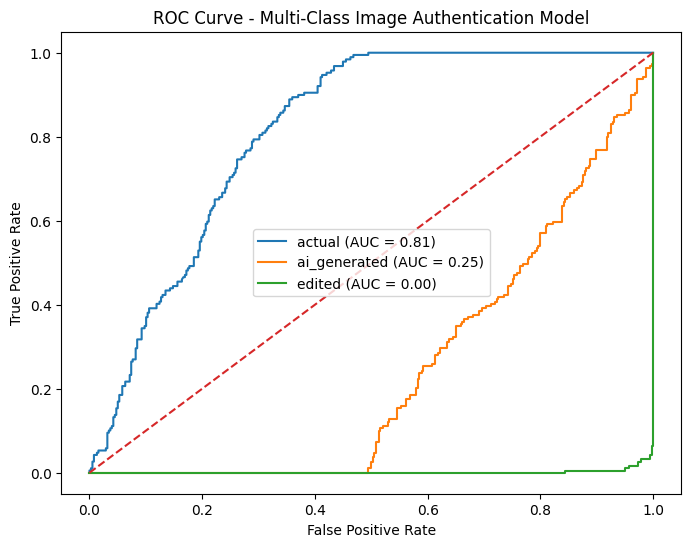

In [ ]:
# Convert true labels into binary format
y_true_binary = label_binarize(
    y_true,
    classes=[0,1,2]
)


plt.figure(figsize=(8,6))


for i in range(3):

    fpr, tpr, _ = roc_curve(
        y_true_binary[:, i],
        predictions[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
    )


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Multi-Class Image Authentication Model"
)

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

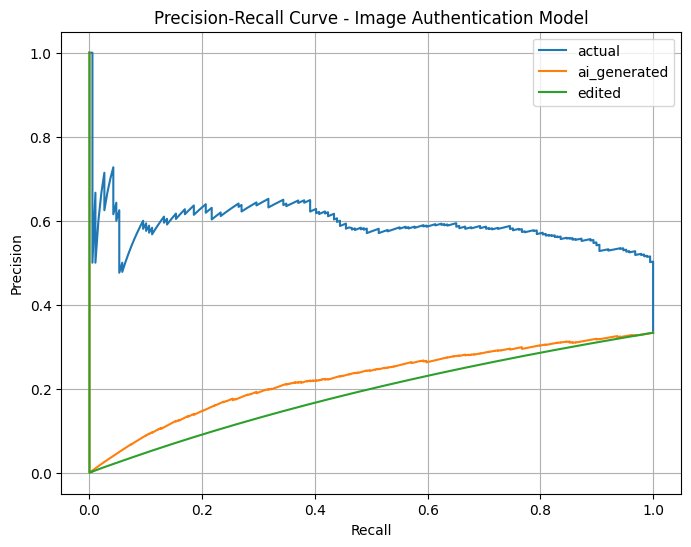

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))


for i in range(3):

    precision, recall, _ = precision_recall_curve(
        y_true_binary[:, i],
        predictions[:, i]
    )


    plt.plot(
        recall,
        precision,
        label=class_names[i]
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)


plt.title(
    "Precision-Recall Curve - Image Authentication Model"
)


plt.legend()

plt.grid()

plt.show()

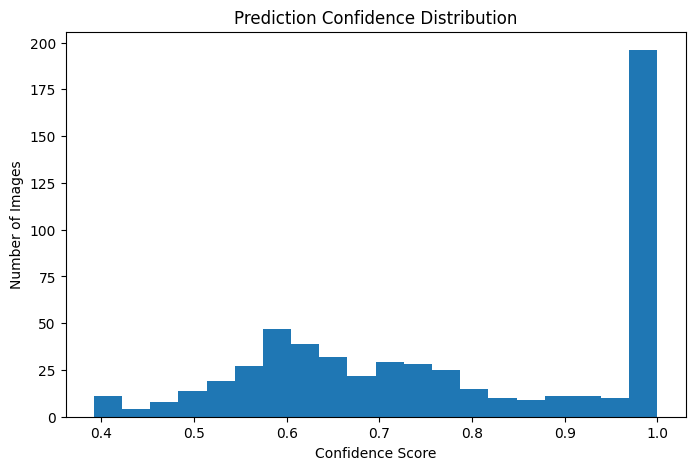

In [ ]:
confidence = np.max(
    predictions,
    axis=1
)


plt.figure(figsize=(8,5))


plt.hist(
    confidence,
    bins=20
)


plt.xlabel(
    "Confidence Score"
)


plt.ylabel(
    "Number of Images"
)


plt.title(
    "Prediction Confidence Distribution"
)


plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


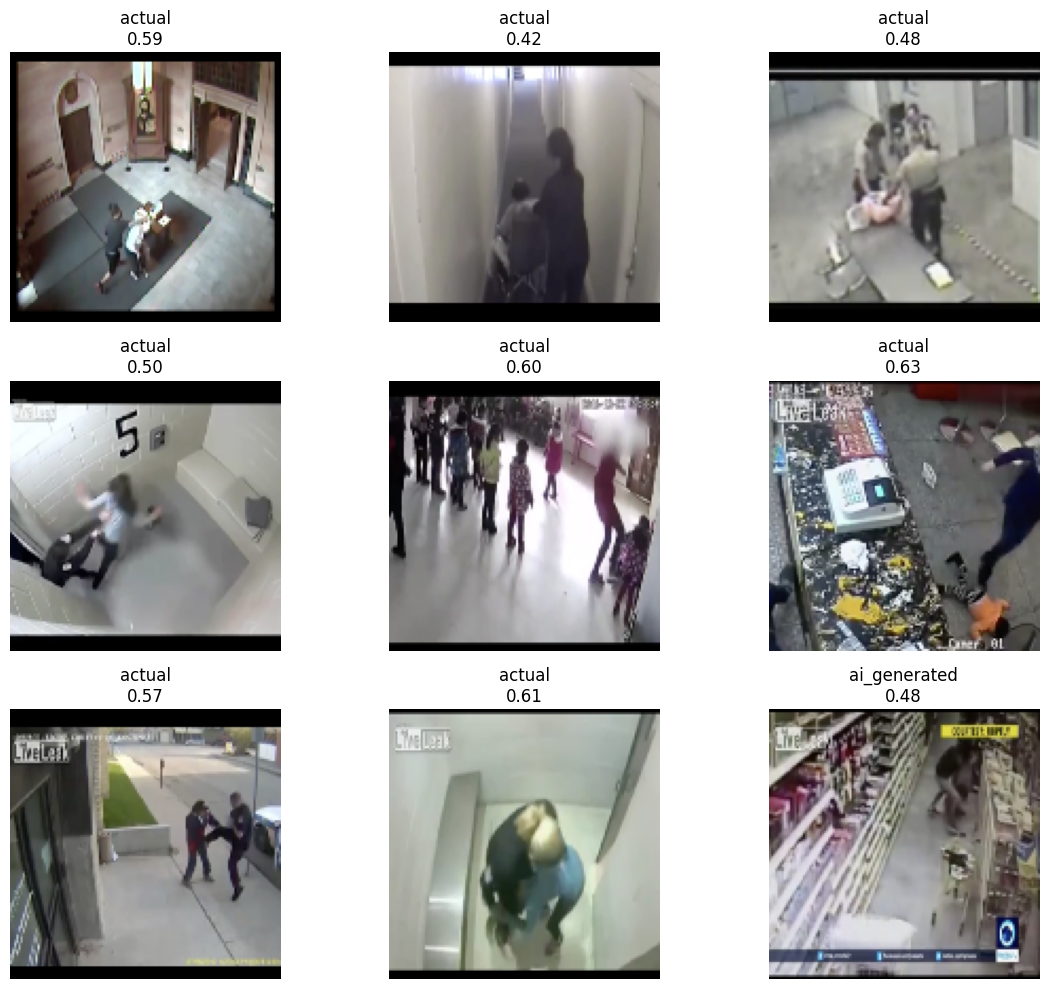

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


images, labels = next(test_generator)


plt.figure(figsize=(12,10))


for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    predicted_class = class_names[
        np.argmax(
            model.predict(
                np.expand_dims(images[i],axis=0)
            )
        )
    ]


    conf = np.max(
        model.predict(
            np.expand_dims(images[i],axis=0)
        )
    )


    plt.title(
        f"{predicted_class}\n{conf:.2f}"
    )


    plt.axis("off")


plt.tight_layout()

plt.show()

In [ ]:
misclassified = np.where(
    y_true != y_pred
)[0]


print(
    "Number of misclassified images:",
    len(misclassified)
)

Number of misclassified images: 367


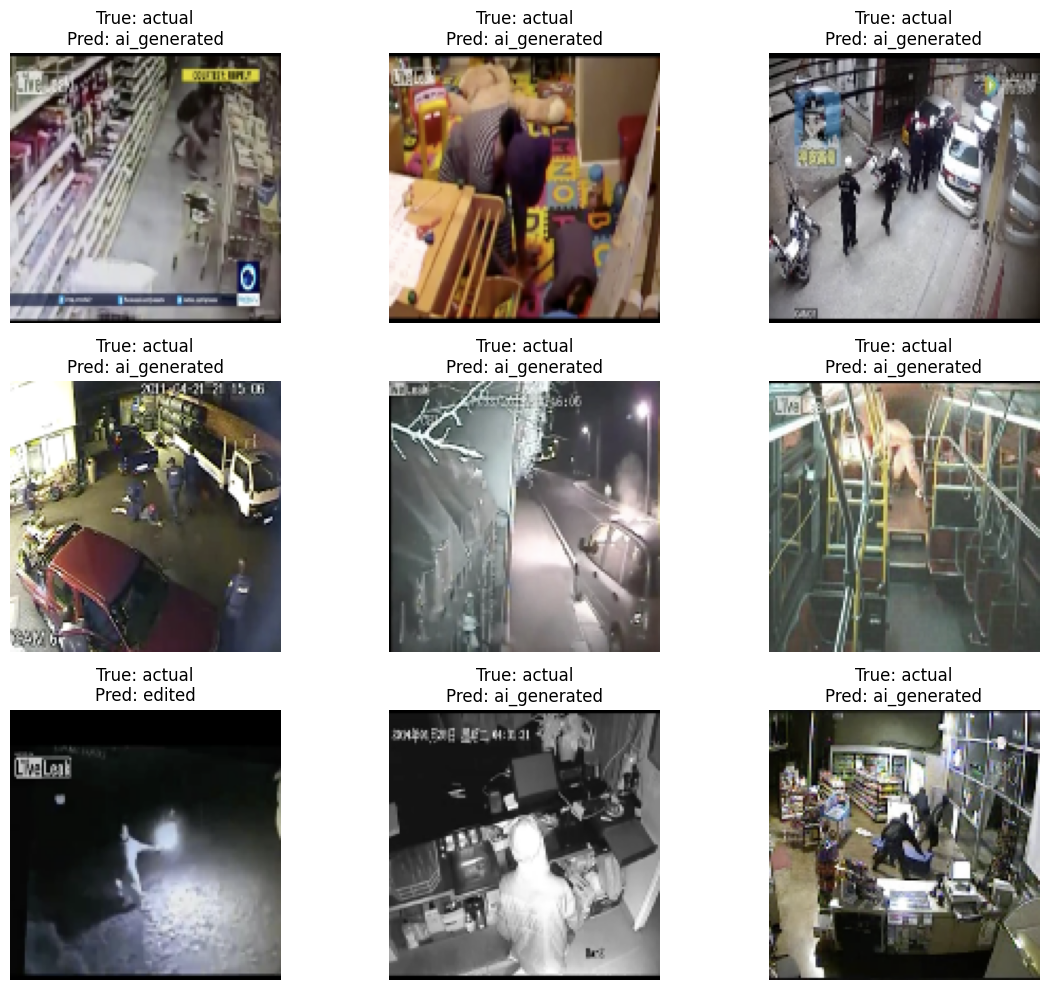

In [ ]:
plt.figure(figsize=(12,10))


for i,index in enumerate(misclassified[:9]):

    img_path = test_generator.filepaths[index]


    img = tf.keras.utils.load_img(
        img_path,
        target_size=(128,128)
    )


    plt.subplot(3,3,i+1)

    plt.imshow(img)


    plt.title(
        "True: "
        + class_names[y_true[index]]
        +
        "\nPred: "
        +
        class_names[y_pred[index]]
    )


    plt.axis("off")


plt.tight_layout()

plt.show()